# Dense → Mixture-of-Experts: train a linear model, convert it, keep training

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/rahulni/Indic_LLM/blob/main/14_MOE/14_dense_to_moe.ipynb)
[![nbviewer](https://img.shields.io/badge/render-nbviewer-orange)](https://nbviewer.org/github/rahulni/Indic_LLM/blob/main/14_MOE/14_dense_to_moe.ipynb)

> **Goal.** Train a dense ("linear") model, convert it into a mixture-of-experts, and show that the
> converted model keeps training and its loss keeps falling, at a size that fits one laptop or Colab
> GPU.

This notebook does that with a ~19M-parameter transformer trained on TinyStories. It converts the
model into a mixture-of-experts **twice**, dense → 8 experts → 32 experts, the way Lightning LM grew.
A dense control trains on the same batches with the same schedule for comparison.

It is also written to be **reopened later as a refresher**:
- Every published number it relies on is recomputed and asserted in code.
- Every mechanism (routing, balancing, dropping, growing, placement) is implemented in plain
  PyTorch, checked by an exact gate, and then measured in a short lab.
- Every idea comes with a plain-language intuition and a collapsible derivation.
- Set `MODE = "learn"` and it replays the saved results on a CPU in about a minute.

## Results at a glance

![The MoE path vs the dense control](https://raw.githubusercontent.com/rahulni/Indic_LLM/main/14_MOE/assets/result_timeline.png)

| | dense (Stage 1) | MoE-8 (Stage 2) | MoE-32 (Stage 3) | dense control |
|---|---|---|---|---|
| total / active params | 18.9M / 18.9M | 26.0M / 18.9M | 68.5M / 19.0M | 18.9M / 18.9M |
| val loss at start of stage | - | 1.8250 (T1, 0 steps) | 1.8919 (T2, 0 steps) | 1.7737 (T1) |
| val loss at end of stage | 1.7737 (T1) | 1.7219 (T2) | **1.5693** (T3) | 1.5491 (T3) |

**MoE-32 minus the dense control at T3** (same batches, same compute per token): +0.0201 nats, 95% CI [+0.0191, +0.0212] over 64 paired validation batches, single seed (negative = MoE better). The MoE path kept training and kept improving after both conversions, as required, but it did **not** beat a dense model given the same tokens; Part K explains where the gap comes from.

**Post-hoc (Part K.2), from the same T2 checkpoint to T3:**

| T3 model | val loss | minus dense control | minus registered MoE-32 |
|---|---|---|---|
| MoE-32, plain-copy growth | 1.5579 | +0.0148 [+0.0135, +0.0160] | -0.0053 [-0.0065, -0.0042] |
| MoE-8, no growth | 1.5463 | +0.0031 [+0.0020, +0.0042] | -0.0170 [-0.0182, -0.0158] |

**Predictions registered before the run:** 8 of 12 held; post-hoc predictions: 3 of 3 held (scored in Part N).

- ✅ Trained a dense ('linear') model: val 4.71 -> 1.774 over 25M tokens
- ✅ Converted it into an MoE (and grew that MoE): 18.9M -> 26.0M -> 68.5M total
- ✅ It continued to train after conversion: MoE-8 1.825 -> 1.722; MoE-32 1.892 -> 1.569
- ✅ The loss dropped below where the dense model was: 1.774 at T1 -> 1.569 at T3
- ✅ Bigger model at the same compute per token: 3.6x the parameters, 1.005x the active parameters
- ✅ Fits a laptop / Colab GPU: peak 5.14 GiB allocated on NVIDIA GeForce RTX 3070 Laptop GPU

_Full run on NVIDIA GeForce RTX 3070 Laptop GPU (bf16, torch 2.11.0+cu128), finished 2026-10-05 17:49._

## Contents

| part | what |
|---|---|
| **1 · Setup** | modes, precision, budgets |
| **A · Refresher** | the core ideas with intuition and math, and published numbers as asserted code: total vs active, router by hand, combinations, capacity, aux loss, traffic |
| **B · Toy** | the whole experiment in 2-D: a linear model → a mixture of linear experts |
| **C · Building blocks** | dense GPT, the MoE layer (router, dropless dispatch, bias), shape trace, gates |
| **D · Data** | TinyStories, BPE-4096, paired batch order |
| **E · Stage 1** | train the dense model |
| **F · Surgery** | copy / partition / drop, Adam-state slicing, what each preserves |
| **G · Conversion lab** | six starting points, raced |
| **H · Router lab** | no balancing vs aux loss vs loss-free bias; softmax vs sigmoid vs √softplus |
| **I · Stage 2** | dense → MoE-8, plus the dense control |
| **J · Growth** | 8 → 32 experts; the clone-family trap and two ways out |
| **K · Result** | the main curve, paired test, samples, checklist |
| **K.2 · Post-hoc** | was it the growth recipe, or growing at all? |
| **L · Experts** | what they learned, how fast routing settles, what pruning costs |
| **M · Systems** | token dropping, EP placement, memory and time |
| **N · Wrap-up** | predictions scored, open design questions, cheat sheet, quiz |

**How the experiment is built**

```
tokens:   0 ─────────── T1 = 25M ─────── T2 = 33M ─────────────── T3 = 45M
MoE path: DENSE 18.9M   │ MoE-8 (26M)     │ MoE-32 (68M total, 18.9M active)
                        │ partition        │ clone x4 + redraw half + Gumbel top-k
control:                └─ DENSE continues on the same batches, same LR curve ──► T3
```

---
## 1 · Setup

Pick a **mode** in the next cell, then *Run all*.

| `MODE` | Needs | Time | What happens |
|---|---|---|---|
| `"learn"` | CPU is fine | ~1 min | Runs the refresher, the toy, and every gate. Training cells **replay** the saved results (`assets/results.json`, fetched from GitHub if it is not next to the notebook) and only draw. |
| `"quick"` | GPU | ~5 min | Every code path at 1/20 scale. Writes to `assets-quick/` and `ckpt-quick/`, never to `assets/`. |
| `"full"` | GPU | ~30 min on an RTX 3070 Laptop (measured), ~1 h on a Colab T4 (estimate) | The real experiment. Writes `assets/`. |

On Colab: *Runtime → Change runtime type → T4 GPU* before `quick`/`full`. Each finished stage is
checkpointed, so if Colab disconnects, re-run all and finished stages are loaded instead of retrained
(set `USE_DRIVE = True` to keep checkpoints on Google Drive across Colab restarts).

In [1]:
import os, sys, math, json, time, random, platform, subprocess, urllib.request, copy, re
from dataclasses import dataclass, asdict, field
from pathlib import Path

MODE = os.environ.get("MOE_MODE", "learn").lower()   # <- "learn" | "quick" | "full"
USE_DRIVE = False                                    # Colab only: keep data/checkpoints on Google Drive
RESUME = os.environ.get("MOE_RESUME", "1") == "1"    # reuse finished stages instead of retraining
assert MODE in ("learn", "quick", "full"), MODE
IN_COLAB = "google.colab" in sys.modules
COMPUTE = MODE != "learn"                            # learn mode never trains, it replays

if COMPUTE:
    try:
        import tokenizers  # noqa: F401
    except ImportError:
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "tokenizers"])

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from IPython.display import display, Markdown

HERE = Path.cwd()
WORK = HERE
if IN_COLAB and USE_DRIVE:
    from google.colab import drive
    drive.mount("/content/drive")
    WORK = Path("/content/drive/MyDrive/moe14")
SUFFIX = "-quick" if MODE == "quick" else ""
DATA = WORK / "data"
CKPT = WORK / f"ckpt{SUFFIX}"
ASSETS = HERE / f"assets{SUFFIX}"
for p in (DATA, CKPT, ASSETS):
    if COMPUTE:
        p.mkdir(parents=True, exist_ok=True)

DEVICE = "cuda" if torch.cuda.is_available() and torch.cuda.device_count() > 0 else "cpu"
if COMPUTE and DEVICE != "cuda":
    raise RuntimeError("MODE='quick'/'full' needs a GPU. On CPU use MODE='learn'.")
if DEVICE == "cuda":
    cap = torch.cuda.get_device_capability()
    PREC = "bf16" if cap[0] >= 8 else "fp16"         # T4 is sm75: no native bf16
else:
    PREC = "fp32"
PREC = os.environ.get("MOE_PRECISION", PREC)          # e.g. force "fp16" to test the T4 path
AMP_DTYPE = {"bf16": torch.bfloat16, "fp16": torch.float16, "fp32": torch.float32}[PREC]

if DEVICE == "cuda" and platform.system() == "Windows":
    # WDDM pages VRAM to host RAM instead of raising OOM, which makes "it fits" a fiction.
    # Capping the allocator turns paging back into a real OutOfMemoryError.
    free, total = torch.cuda.mem_get_info()
    torch.cuda.set_per_process_memory_fraction(free / total * 0.97)

def seed_all(s):
    random.seed(s); np.random.seed(s); torch.manual_seed(s)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(s)

seed_all(1337)
torch.backends.cuda.matmul.allow_tf32 = True
torch.backends.cudnn.allow_tf32 = True

GPU = torch.cuda.get_device_name(0) if DEVICE == "cuda" else "cpu"
print(f"MODE={MODE}  device={GPU}  precision={PREC}  torch={torch.__version__}  colab={IN_COLAB}")

MODE=full  device=NVIDIA GeForce RTX 3070 Laptop GPU  precision=bf16  torch=2.11.0+cu128  colab=False


**Plot style.** Every chart uses one dark surface, hairline grids, 2px lines and a fixed categorical
order (validated for colour-vision deficiency against this surface). Colour always follows the
entity: *dense* is blue and *MoE* is orange everywhere in the notebook.

In [2]:
SURFACE, INK, INK2, MUTED, GRID, AXIS = "#0d1117", "#e6edf3", "#c3c2b7", "#898781", "#21262d", "#30363d"
SERIES = ["#3987e5", "#d95926", "#199e70", "#c98500", "#d55181", "#008300", "#9085e9", "#e66767"]
DENSE_C, MOE_C = SERIES[0], SERIES[1]
CRITICAL = "#d03b3b"
SEQ = LinearSegmentedColormap.from_list("seq_blue", ["#0d1117", "#104281", "#256abf", "#5598e7", "#9ec5f4", "#cde2fb"])
DIV = LinearSegmentedColormap.from_list("div", ["#3987e5", "#383835", "#e66767"])
DIV.set_bad(SURFACE)

plt.rcParams.update({
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE, "savefig.facecolor": SURFACE,
    "axes.edgecolor": AXIS, "axes.labelcolor": INK2, "text.color": INK,
    "xtick.color": MUTED, "ytick.color": MUTED, "grid.color": GRID, "grid.linewidth": 0.8,
    "axes.grid": True, "axes.axisbelow": True, "axes.spines.top": False, "axes.spines.right": False,
    "lines.linewidth": 2.0, "lines.solid_capstyle": "round", "legend.frameon": False,
    "legend.labelcolor": INK2, "axes.titlecolor": INK, "axes.titlesize": 11, "axes.titleweight": "bold",
    "font.size": 9.5, "figure.dpi": 110, "savefig.dpi": 130, "savefig.bbox": "tight",
    "axes.prop_cycle": matplotlib.cycler(color=SERIES),
})

def savefig(fig, name):
    if COMPUTE:
        fig.savefig(ASSETS / f"{name}.png")
    plt.show()

**Results store.** Every compute cell writes into one dict, `R`, and every plot cell reads only from
`R`. That is what lets `learn` mode replay the whole notebook without a GPU: it loads `R` from
`assets/results.json` and skips the compute.

In [3]:
RAW_URL = "https://raw.githubusercontent.com/rahulni/Indic_LLM/main/14_MOE/assets/results.json"

def load_results():
    f = ASSETS / "results.json"
    if f.exists():
        return json.loads(f.read_text())
    if MODE == "learn":
        try:
            with urllib.request.urlopen(RAW_URL, timeout=30) as r:
                return json.loads(r.read().decode())
        except Exception as e:
            print(f"(no saved results found locally or at GitHub: {e}) - plots will be skipped")
    return {}

R = load_results() if (RESUME or MODE == "learn") else {}
if MODE != "learn" and R.get("meta", {}).get("mode") not in (None, MODE):
    R = {}                                    # never mix quick and full numbers
R.setdefault("meta", {})
R.setdefault("runs", {})
if COMPUTE:
    R["meta"].update(mode=MODE, gpu=GPU, precision=PREC, torch=torch.__version__,
                     python=platform.python_version(), complete=False)

def save_results():
    if COMPUTE:
        tmp = ASSETS / "results.json.tmp"
        tmp.write_text(json.dumps(R, separators=(",", ":")))
        tmp.replace(ASSETS / "results.json")

def have(*keys):
    """True when a result already exists, so a finished stage is not recomputed."""
    d = R
    for k in keys:
        if not isinstance(d, dict) or k not in d:
            return False
        d = d[k]
    return True

GATES = {}
def gate(name, ok, detail=""):
    """An exact check that must hold before anything trains. A failure stops the notebook."""
    GATES[name] = bool(ok)
    print(f"[{'PASS' if ok else 'FAIL'}] {name}" + (f"  ({detail})" if detail else ""))
    assert ok, name

HOTPLUG = WORK / "hotplug.json"
def read_hotplug():
    """Live knobs, re-read every 50 steps: {"gamma": .., "seq_alpha": .., "lr_mult": .., "freeze_router": bool}."""
    try:
        return json.loads(HOTPLUG.read_text())
    except Exception:
        return {}

print("results loaded:", sorted(k for k in R if k != "meta" and R[k]) or "none yet")

results loaded: ['bench', 'capacity', 'checklist', 'conversion', 'data', 'ep', 'experts', 'final_pair', 'growth', 'paired', 'params', 'points', 'posthoc', 'predictions', 'router_lab', 'runs', 'samples', 'val_T1']


### Configuration: every size and budget lives here

The token budgets are set so a free Colab T4 finishes `full` in about an hour. The model is
deliberately the same shape in every stage; only the feed-forward block changes.

In [4]:
@dataclass
class GPTConfig:
    vocab: int = 4096
    d: int = 384          # hidden size
    n_layer: int = 8
    n_head: int = 6       # query heads
    n_kv: int = 2         # key/value heads (GQA: 3 query heads share one K/V head)
    ctx: int = 256
    ffn: int = 1536       # dense SwiGLU inner width F (4 x d)

@dataclass
class MoEConfig:
    n_exp: int            # routed experts per layer, E
    width: int            # inner width of one expert, w
    top_k: int            # experts chosen per token, k
    shared: int = 0       # inner width of the always-on shared expert (0 = none)
    score: str = "sigmoid"        # "sigmoid" | "softmax" | "sqrt_softplus"
    route_scale: float = None     # multiplies the renormalised top-k weights; None -> k
    balance: str = "bias"         # "bias" (loss-free) | "none"
    gamma: float = 1e-3           # bias update speed
    seq_alpha: float = 1e-4       # sequence-level auxiliary loss weight
    switch_alpha: float = 0.0     # Switch-style batch auxiliary loss weight
    family: int = 1               # clones per family after growth (for diagnostics only)

GCFG = GPTConfig()
SCALE = {"full": 1.0, "quick": 0.05, "learn": 1.0}[MODE]
BUDGET = dict(
    batch=64, lab_batch=16, micro_batch=32,    # sequences per step (x 256 tokens); 64 = 2 micro-batches
    T1=25e6, T2=8e6, T3=12e6,                  # dense stage, MoE-8 stage, MoE-32 stage (tokens)
    lab=1.2e6,                                 # tokens per lab run
    peak_lr=1.2e-3, warmup=200, rewarm=50,     # WSD schedule
    eval_every=50, lab_eval_every=25,
    val_batches=16, final_val_batches=64,      # x 32 sequences
    train_mb=240, bpe_mb=30,                   # MB of TinyStories text to stream / to train BPE on
)
if MODE == "quick":
    BUDGET.update(T1=1.3e6, T2=0.45e6, T3=0.6e6, lab=0.12e6, warmup=20, rewarm=10, eval_every=10,
                  lab_eval_every=5, val_batches=4, final_val_batches=8, train_mb=12, bpe_mb=6)
TOK_STEP, LAB_TOK_STEP = BUDGET["batch"] * GCFG.ctx, BUDGET["lab_batch"] * GCFG.ctx
S1 = int(BUDGET["T1"] // TOK_STEP)
S2 = int(BUDGET["T2"] // TOK_STEP)
S3 = int(BUDGET["T3"] // TOK_STEP)
SLAB = int(BUDGET["lab"] // LAB_TOK_STEP)
print(f"steps: dense {S1} | MoE-8 {S2} | MoE-32 {S3} | dense control {S2 + S3} | each lab run {SLAB}")
print(f"tokens: T1 {S1 * TOK_STEP / 1e6:.1f}M -> T2 {(S1 + S2) * TOK_STEP / 1e6:.1f}M -> T3 {(S1 + S2 + S3) * TOK_STEP / 1e6:.1f}M")

steps: dense 1525 | MoE-8 488 | MoE-32 732 | dense control 1220 | each lab run 292
tokens: T1 25.0M -> T2 33.0M -> T3 45.0M


---
## A · Refresher: the core ideas, with intuition, math, and checked numbers

> Each idea gets three things: a plain-language **🧠 intuition**, the **📐 math** (click to open),
> and a code cell that recomputes published numbers, where an `assert` fails if the arithmetic does
> not match. If you have five minutes, read this part.

### A.0 Notation used everywhere below

| symbol | meaning | in this notebook |
|---|---|---|
| $B,\ T,\ N=BT$ | sequences per batch, tokens per sequence, tokens per batch | 64 (2 micro-batches of 32), 256, 16,384 |
| $L,\ d$ | layers, hidden size | 8, 384 |
| $F$ | width (number of neurons) of the dense feed-forward block | 1,536 |
| $E,\ k$ | routed experts per layer, experts chosen per token | 8 → 32, 4 |
| $w,\ w_s$ | width of one routed expert, of the shared expert | 192, 768 |
| $c$ | how many experts contain a copy of each dense neuron | 2 (partition), $E$ (copy) |
| $s$ | route scale: multiplies the renormalised weights | 4 (partition), 1 (copy) |
| $x \in \mathbb{R}^{d}$ | one token's vector entering the feed-forward block | |
| $z = W_r x \in \mathbb{R}^{E}$ | router logits; $W_r$ is $E \times d$ | |
| $\sigma_i$ | score of expert $i$ (softmax, sigmoid or √softplus of $z$) | sigmoid |
| $\mathcal{T}(x)$ | the $k$ chosen experts | |
| $g_i$ | weight of chosen expert $i$ | |
| $b_i$ | balancing bias of expert $i$, used **only** to choose | |
| $\gamma,\ \alpha$ | bias update speed, auxiliary-loss weight | 0.001; 0.01 (Switch), 0.0001 (sequence) |
| $n_i,\ f_i,\ P_i$ | tokens sent to $i$, its share of all (token, expert) picks, its mean router probability | |
| $\eta,\ \ell$ | learning rate, cross-entropy loss in nats | 1.2e-3 peak |

### A.1 Why mixture-of-experts exists

```
STANDARD LAYER                              MIXTURE-OF-EXPERTS LAYER
token                                        token
  │                                            │
  ▼                                            ▼
┌──────────────────────────┐                 router ── scores 128 small networks
│ one feed-forward block   │                   │
│ 6,144 wide               │                   ▼
│ every weight is used     │                 picks 8 of them, each 768 wide
└──────────────────────────┘                   │
                                               ▼
                                             8 × 768 = 6,144 of width is used,
                                             120 small networks sit idle for this token
```

The feed-forward block holds most of a transformer's parameters, and every token uses all of
them. An MoE layer **stores** many small feed-forward networks (*experts*) and **runs** only the few
the router picks for each token. Parameters grow; work per token does not.

🧠 **Intuition.** Think of a hospital. A triage nurse (the router) sends each patient (token) to a
couple of the hospital's specialists (experts). The hospital pays every doctor's salary (memory
grows with *all* parameters), but each patient only takes the time of the few doctors they see
(compute grows with the *active* parameters). Another version: you do not use your whole
brain for every thought. The knowledge stays stored, and only the part you need switches on.

<details><summary>📐 <b>The math:</b> compute follows the active parameters, memory follows the total</summary>

For training, the work per token and the memory are, to a good approximation:

$$\text{FLOPs per token} \;\approx\; 6\,N_{\text{active}}, \qquad \text{training memory} \;\approx\; 16\,N_{\text{total}}\ \text{bytes}.$$

* **6** = 2 (one multiply + one add per weight) × 3 (forward pass, backward pass for the
  activations, backward pass for the weights). This ignores the attention-score term, which grows
  with the sequence length.
* **16 bytes** = 4 (fp32 weight) + 4 (fp32 gradient) + 4 + 4 (Adam's two moments $m$, $v$).
  Activations come on top and scale with the batch.

**Worked example.**

| model | FLOPs per token | training state |
|---|---|---|
| reference MoE | $6 \times 3.35\text{B} = 20.1$ GFLOP | $16 \times 30.53\text{B} = 455$ GiB |
| a 30.2B dense model | 181 GFLOP | 450 GiB |
| our MoE-32 | $6 \times 18.98\text{M} = 114$ MFLOP | $16 \times 68.5\text{M} = 1.02$ GiB |
| our dense model | $6 \times 18.88\text{M} = 113$ MFLOP | 0.28 GiB |

The reference model buys the memory of a 30B model at one ninth of its compute. Our MoE-32 has the
same compute per token as our dense model and 3.6× its memory.

</details>

It creates three problems, and each later part of this notebook touches one of them:

| problem | what goes wrong | where in this notebook |
|---|---|---|
| **choosing** | a router must pick k of E experts per token | C (router), H (score functions) |
| **balancing** | the router falls in love with a few experts; the rest never learn | H (balancing lab), J (growth lab) |
| **placing** | experts live on different GPUs; tokens travel there and back | M (systems view) |
| **growing** | build the MoE from a dense model instead of from scratch | F (surgery), G, J |

### A.2 Terminology

| term | meaning | reference model (Qwen3-30B-A3B shape) | our final model |
|---|---|---|---|
| expert | one small SwiGLU feed-forward network | 128 per layer, width 768 | 32 per layer, width 192 |
| router (gate) | one matrix `d × E` scoring every expert for every token | 2048 × 128 | 384 × 32 |
| top-k | keep the k highest scores | k = 8 | k = 4 |
| shared expert | always on, never routed | none | one, width 768 |
| total params | every stored weight | 30.53B | ~68M |
| active params | weights one token touches | 3.35B | ~19M |
| load | share of tokens an expert receives; even = k / E | 6.25% | 12.5% |
| capacity | max tokens an expert may take per batch (old style) | — | dropless |

### A.3 Total vs active parameters: the calculator

One function counts any MoE transformer. It reproduces the published figures for the reference model
(Qwen3-30B-A3B: 48 layers, hidden 2,048, 32 query / 4 KV heads of 128, 128 experts of width 768,
top-8, vocabulary 151,936, untied embeddings) and the Mixtral 8x7B figures.

🧠 **Intuition.** An MoE layer is a dense layer whose feed-forward block has been cut into
pieces. Count the attention once, the router once, the shared expert once, and the experts *E*
times for storage but only *k* times for a token.

<details><summary>📐 <b>The math:</b> the parameter count, per layer and per model</summary>

With $n_q$ query heads, $n_{kv}$ key/value heads of size $h$, and SwiGLU experts (three matrices
each: gate and up are $w \times d$, down is $d \times w$):

$$N^{\text{attn}} = d\,n_q h + 2\,d\,n_{kv} h + n_q h\,d, \qquad N^{\text{expert}} = 3\,d\,w, \qquad N^{\text{router}} = d\,E, \qquad N^{\text{shared}} = 3\,d\,w_s$$

$$N_{\text{total}} = L\big(N^{\text{attn}} + E\,N^{\text{expert}} + N^{\text{router}} + N^{\text{shared}}\big) + N^{\text{emb}}$$

$$N_{\text{active}} = L\big(N^{\text{attn}} + k\,N^{\text{expert}} + N^{\text{router}} + N^{\text{shared}}\big) + N^{\text{emb}}$$

The only difference between the two is $E$ versus $k$ in front of the expert term.

**Worked example (our MoE-32).**

| term | count |
|---|---|
| $N^{\text{attn}}$ | $384 \cdot 384 + 2 \cdot 384 \cdot 128 + 384 \cdot 384 = 393{,}216$ |
| $N^{\text{expert}}$ | $3 \cdot 384 \cdot 192 = 221{,}184$ |
| $N^{\text{shared}}$ | $3 \cdot 384 \cdot 768 = 884{,}736$ |
| $N^{\text{router}}$ | $384 \cdot 32 = 12{,}288$ |
| $N^{\text{emb}}$ (tied, counted once) | $4096 \cdot 384 = 1{,}572{,}864$ |

$$N_{\text{total}} = 8\,(393{,}216 + 32 \cdot 221{,}184 + 12{,}288 + 884{,}736) + 1{,}572{,}864 + \underbrace{6{,}528}_{\text{norms}} = 68{,}524{,}416$$

$$N_{\text{active}} = 8\,(393{,}216 + 4 \cdot 221{,}184 + 12{,}288 + 884{,}736) + 1{,}572{,}864 + 6{,}528 = 18{,}979{,}200$$

Both match `n_params(model)` exactly; a gate in Part M checks it.

</details>

In [5]:
def count_moe(L, d, vocab, n_q, n_kv, hd, E, k, w, shared=0, tied=False, dense_ffn=None):
    """Return (total, active) parameter counts, ignoring norms. dense_ffn: count a dense model instead."""
    attn = d * n_q * hd + 2 * d * n_kv * hd + n_q * hd * d
    emb = vocab * d * (1 if tied else 2)
    if dense_ffn:
        per = attn + 3 * d * dense_ffn
        return L * per + emb, L * per + emb
    expert, router, sh = 3 * d * w, d * E, 3 * d * shared
    total = L * (attn + E * expert + router + sh) + emb
    active = L * (attn + k * expert + router + sh) + emb
    return total, active

QWEN = dict(L=48, d=2048, vocab=151_936, n_q=32, n_kv=4, hd=128, E=128, k=8, w=768)
q_tot, q_act = count_moe(**QWEN)
attn_layer = 2048 * 32 * 128 * 2 + 2 * 2048 * 4 * 128
print(f"Qwen3-30B-A3B shape: total {q_tot / 1e9:.2f}B, active {q_act / 1e9:.2f}B, "
      f"attention {attn_layer / 1e6:.2f}M/layer, one expert {3 * 2048 * 768 / 1e6:.2f}M")
assert round(q_tot / 1e9, 2) == 30.53 and round(q_act / 1e9, 2) == 3.35
assert round(attn_layer / 1e6, 2) == 18.87

GiB = 2**30
print(f"training state at 16 bytes/param: MoE {q_tot * 16 / GiB:.0f} GiB vs a 30.2B dense model {30.2e9 * 16 / GiB:.0f} GiB")
print(f"work per token, 6 x active: MoE {6 * q_act / 1e9:.1f} GFLOP vs dense {6 * 30.2e9 / 1e9:.0f} GFLOP")
assert round(q_tot * 16 / GiB) == 455 and round(30.2e9 * 16 / GiB) == 450
assert round(6 * q_act / 1e9, 1) == 20.1 and round(6 * 30.2e9 / 1e9) == 181

kv = 2 * 4 * 128 * 2 * 48                       # K and V, 4 heads, 128 dims, 2 bytes, 48 layers
print(f"KV cache: {kv / 1024:.0f} KiB/token with GQA (4 KV heads), {kv * 8 / 1024:.0f} KiB with 32 heads; "
      f"{kv * 32768 / GiB:.0f} GiB vs {kv * 8 * 32768 / GiB:.0f} GiB for a 32K sequence")
assert kv / 1024 == 96 and kv * 32768 / GiB == 3

m_tot, m_act = count_moe(L=32, d=4096, vocab=32_000, n_q=32, n_kv=8, hd=128, E=8, k=2, w=14_336)
m_exp = 32 * 8 * 3 * 4096 * 14_336
print(f"Mixtral 8x7B: total {m_tot / 1e9:.1f}B (not 8 x 7 = 56B), active {m_act / 1e9:.1f}B, experts hold {m_exp / m_tot:.1%}")
assert round(m_tot / 1e9) == 47 and round(m_act / 1e9) == 13 and round(m_exp / m_tot, 2) == 0.97

Qwen3-30B-A3B shape: total 30.53B, active 3.35B, attention 18.87M/layer, one expert 4.72M
training state at 16 bytes/param: MoE 455 GiB vs a 30.2B dense model 450 GiB
work per token, 6 x active: MoE 20.1 GFLOP vs dense 181 GFLOP
KV cache: 96 KiB/token with GQA (4 KV heads), 768 KiB with 32 heads; 3 GiB vs 24 GiB for a 32K sequence
Mixtral 8x7B: total 46.7B (not 8 x 7 = 56B), active 12.9B, experts hold 96.6%


**The E × k sweep.** Same layer, change how many experts it stores and how many each
token uses. The active size changes only with *k* (down a column it is constant), and the total
grows with *E* (across a row it is constant).

In [6]:
rows = ["| experts E \\ chosen k | " + " | ".join(f"k={k}" for k in (2, 4, 8, 16)) + " |", "|---|---|---|---|---|"]
for E in (32, 64, 128, 256):
    cells = []
    for k in (2, 4, 8, 16):
        t, a = count_moe(**{**QWEN, "E": E, "k": k})
        cells.append(f"{t / 1e9:.1f}B total · {a / 1e9:.2f}B active")
    rows.append(f"| **{E}** | " + " | ".join(cells) + " |")
display(Markdown("\n".join(rows)))
assert round(count_moe(**{**QWEN, "E": 256})[0] / 1e9) == 60          # "256 per layer, ~60B"

| experts E \ chosen k | k=2 | k=4 | k=8 | k=16 |
|---|---|---|---|---|
| **32** | 8.8B total · 1.98B active | 8.8B total · 2.44B active | 8.8B total · 3.34B active | 8.8B total · 5.16B active |
| **64** | 16.0B total · 1.99B active | 16.0B total · 2.44B active | 16.0B total · 3.35B active | 16.0B total · 5.16B active |
| **128** | 30.5B total · 1.99B active | 30.5B total · 2.45B active | 30.5B total · 3.35B active | 30.5B total · 5.16B active |
| **256** | 59.5B total · 2.01B active | 59.5B total · 2.46B active | 59.5B total · 3.37B active | 59.5B total · 5.18B active |

### A.4 The router, worked by hand

Eight experts, k = 2, one token whose router logits are `[2.0, 0.5, 1.2, −0.3, 0.9, 1.8, −1.0, 0.1]`.
Softmax makes the experts compete; sigmoid scores each one on its own. **Both pick the same two
experts** (0 and 5). They differ in how strongly the router's preference survives into the weights:
softmax keeps a 0.55/0.45 split, sigmoid flattens it to 0.507/0.493.

🧠 **Intuition.** The router is a panel of judges scoring every expert for this token. The
*choice* is decided by rank alone: who is in the top *k*. The *weights* decide how loudly each
chosen expert is heard.

* **Softmax is a ranked election.** The scores share a fixed budget of 1, so one point of logit gap
  always means the same ratio (×2.7), however large the logits are.
* **Sigmoid gives each expert an independent pass mark** between 0 and 1. Two confident passes, 0.88
  and 0.86, look almost the same, so after renormalising the router's preference is flattened:
  sigmoid all but erases the router's ranking among confident experts.
* **The balancing bias** is a thumb on the scale *for the choice only*. It can move an expert
  in or out of the top *k*, but the weights still come from the honest scores.

<details><summary>📐 <b>The math:</b> scores, the choice, the weights, and why top-k has no gradient</summary>

**Scores.** With logits $z = W_r x$:

$$\text{softmax: } \sigma_i = \frac{e^{z_i}}{\sum_{j=1}^{E} e^{z_j}}, \qquad \text{sigmoid: } \sigma_i = \frac{1}{1 + e^{-z_i}}, \qquad \text{DeepSeek-V4: } \sigma_i = \sqrt{\operatorname{softplus}(z_i)}$$

**The choice and the weights.** The bias $b_i$ enters only the choice:

$$\mathcal{T}(x) = \operatorname{top}_k\big(\sigma_i + b_i\big), \qquad g_i = s\,\frac{\sigma_i}{\sum_{j \in \mathcal{T}} \sigma_j} \quad (i \in \mathcal{T}), \qquad y = \sum_{i \in \mathcal{T}} g_i\,E_i(x)$$

**Renormalised softmax keeps the gaps.** The softmax denominator over all $E$ experts cancels:

$$\frac{\sigma_i}{\sum_{j \in \mathcal{T}} \sigma_j} = \frac{e^{z_i}}{\sum_{j \in \mathcal{T}} e^{z_j}} \quad\Longrightarrow\quad \frac{g_a}{g_b} = e^{\,z_a - z_b}.$$

So the renormalised weights are just a softmax over the chosen logits, and only the logit *gap*
matters.

**Sigmoid flattens them.** For sigmoid, $g_a / g_b = \sigma(z_a)/\sigma(z_b)$. Since $\sigma \to 1$ for large
logits, this ratio goes to 1 as both logits grow, even when the gap stays fixed.

In the worked example the gap is $z_0 - z_5 = 0.2$:

| | ratio $g_0/g_5$ | weights |
|---|---|---|
| softmax | $e^{0.2} = 1.22$ | 0.55 / 0.45 |
| sigmoid | $0.881 / 0.858 = 1.027$ | 0.507 / 0.493 |

**Why top-k has no gradient.** $\mathcal{T}$ is piecewise constant in $z$: nudging a logit does not
change the chosen set, except exactly at a tie. So $\partial\mathcal{T}/\partial z = 0$ almost
everywhere, and the router learns only through the weights:

$$\frac{\partial \ell}{\partial z_j} = \sum_{i \in \mathcal{T}} \frac{\partial \ell}{\partial g_i}\,\frac{\partial g_i}{\partial z_j}, \qquad \frac{\partial \ell}{\partial g_i} = \Big\langle \frac{\partial \ell}{\partial y},\; E_i(x) \Big\rangle.$$

An expert whose output points downhill on the loss gets its weight, and with it its logit, pushed
up.

With $k = 1$ and renormalisation, $g \equiv s$ is a constant, so $\partial g / \partial z = 0$ and the router
never learns. That is why Switch Transformer used the *unnormalised* probability as its single
weight.

</details>

In [7]:
z = torch.tensor([2.0, 0.5, 1.2, -0.3, 0.9, 1.8, -1.0, 0.1])
for name, fn in (("softmax", lambda v: torch.softmax(v, 0)), ("sigmoid", torch.sigmoid)):
    s = fn(z)
    top = s.topk(2).indices
    w = s[top] / s[top].sum()
    print(f"{name:<8} scores {[round(v, 3) for v in s.tolist()]}  ->  experts {top.tolist()}  weights {[round(v, 3) for v in w.tolist()]}")
sm, sg = torch.softmax(z, 0), torch.sigmoid(z)
assert torch.equal(sm.topk(2).indices, sg.topk(2).indices)
assert [round(v, 2) for v in (sm[[0, 5]] / sm[[0, 5]].sum()).tolist()] == [0.55, 0.45]
assert [round(v, 3) for v in (sg[[0, 5]] / sg[[0, 5]].sum()).tolist()] == [0.507, 0.493]
assert torch.allclose(sm[[0, 5]] / sm[[0, 5]].sum(), torch.softmax(z[[0, 5]], 0))      # the identity above

# Loss-free balancing: a bias of -0.5 on expert 5 changes the CHOICE, not the weights.
bias = torch.zeros(8); bias[5] = -0.5
top_b = (sg + bias).topk(2).indices
w_b = sg[top_b] / sg[top_b].sum()
print(f"with bias -0.5 on expert 5: selection score {sg[5] + bias[5]:.3f} -> experts {top_b.tolist()}, "
      f"weights from the ORIGINAL scores {[round(v, 3) for v in w_b.tolist()]}")
assert sorted(top_b.tolist()) == [0, 2] and round((sg[5] + bias[5]).item(), 3) == 0.358

# Probabilistic top-k (the Lightning LM growth fix): sample k without replacement.
g = torch.Generator().manual_seed(0)
draws = torch.stack([(sg + -torch.log(-torch.log(torch.rand(8, generator=g)))).topk(2).indices for _ in range(2000)])
freq = torch.bincount(draws.flatten(), minlength=8) / 2000
print("Gumbel top-2, how often each expert is picked:", [f"{v:.0%}" for v in freq.tolist()])

softmax  scores [0.32, 0.071, 0.144, 0.032, 0.107, 0.262, 0.016, 0.048]  ->  experts [0, 5]  weights [0.55, 0.45]
sigmoid  scores [0.881, 0.622, 0.769, 0.426, 0.711, 0.858, 0.269, 0.525]  ->  experts [0, 5]  weights [0.507, 0.493]
with bias -0.5 on expert 5: selection score 0.358 -> experts [0, 2], weights from the ORIGINAL scores [0.534, 0.466]
Gumbel top-2, how often each expert is picked: ['29%', '25%', '29%', '20%', '26%', '31%', '18%', '22%']


**See the math: how much of the router's preference survives.** Two chosen experts *a* and *b*
with a logit gap of Δ. The plot shows the weight the leader gets. Softmax gives it
$1/(1+e^{-\Delta})$ wherever the logits sit. Sigmoid's split depends on *where* the logits are: the
higher they sit, the closer to 50/50, whatever the gap.

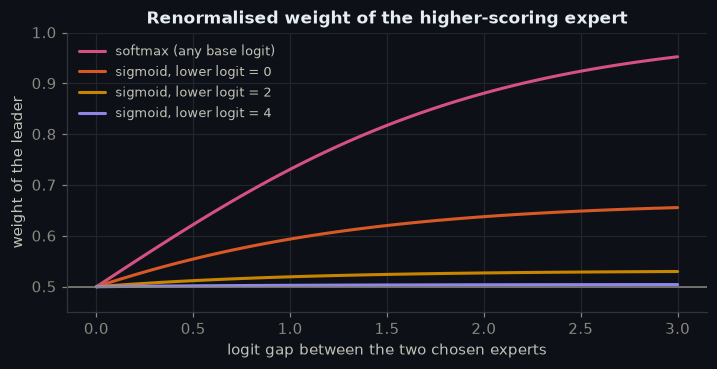

In [8]:
gap = torch.linspace(0, 3, 121)
fig, ax = plt.subplots(figsize=(7.5, 3.3))
ax.plot(gap, torch.sigmoid(gap), color=SERIES[4], label="softmax (any base logit)")
for base, color in ((0.0, SERIES[1]), (2.0, SERIES[3]), (4.0, SERIES[6])):
    sa, sb = torch.sigmoid(base + gap), torch.sigmoid(torch.tensor(base))
    ax.plot(gap, sa / (sa + sb), color=color, label=f"sigmoid, lower logit = {base:g}")
ax.axhline(0.5, color=MUTED, lw=1)
ax.set(xlabel="logit gap between the two chosen experts", ylabel="weight of the leader", ylim=(0.45, 1.0),
       title="Renormalised weight of the higher-scoring expert")
ax.legend(fontsize=8.5)
savefig(fig, "demo_softmax_vs_sigmoid")
# checks: softmax depends only on the gap; sigmoid at base 4 and gap 1 is nearly even
assert torch.allclose(torch.softmax(torch.tensor([5.0, 4.0]), 0)[0], torch.sigmoid(torch.tensor(1.0)))
assert abs(float(torch.sigmoid(torch.tensor(5.0)) / (torch.sigmoid(torch.tensor(5.0)) + torch.sigmoid(torch.tensor(4.0)))) - 0.5) < 0.005

### A.5 Why many small experts: the combinations

Fine-grained experts (DeepSeekMoE, 2024): split each expert into *m* smaller ones and choose *m*
times as many. Compute stays the same; the number of ways to assemble a token's network explodes.

🧠 **Intuition.** It is the same amount of LEGO cut into smaller bricks: the same plastic, far more
shapes. A few big experts must each hold very different knowledge; many small ones can be combined
per token.

<details><summary>📐 <b>The math:</b> compute is unchanged, combinations explode</summary>

A token can use $\binom{E}{k}$ distinct sets of experts. Split every expert into $m$ pieces of width
$w/m$, and choose $mk$ of the $mE$ pieces:

$$\underbrace{mk \cdot 3d\frac{w}{m}}_{\text{active FFN params}} = k \cdot 3dw \quad\text{(unchanged)}, \qquad \binom{mE}{mk} \gg \binom{E}{k}.$$

**Worked example.** $\binom{16}{2} = 120$. Split by 4: $\binom{64}{8} = 4{,}426{,}165{,}368$.

Ours: Stage 2 has $\binom{8}{4} = 70$ sets, Stage 3 has $\binom{32}{4} = 35{,}960$.

Part F runs the exact version of this identity in reverse, as the "fine-grained split" gate:
cutting each expert into 4 and raising $k$ and $s$ by 4 gives identical logits.

</details>

In [9]:
for E, k, label in ((8, 2, "Mixtral, 8 choose 2"), (16, 2, "16 choose 2"), (64, 8, "split x4: 64 choose 8"),
                    (128, 8, "reference model, 128 choose 8"), (8, 4, "our Stage 2, 8 choose 4"), (32, 4, "our Stage 3, 32 choose 4")):
    print(f"{label:<32} {math.comb(E, k):>22,}")
assert math.comb(8, 2) == 28 and math.comb(16, 2) == 120
assert math.comb(128, 8) == 1_429_702_652_400 and math.comb(64, 8) == 4_426_165_368

Mixtral, 8 choose 2                                  28
16 choose 2                                         120
split x4: 64 choose 8                     4,426,165,368
reference model, 128 choose 8         1,429,702,652,400
our Stage 2, 8 choose 4                              70
our Stage 3, 32 choose 4                         35,960


### A.6 Capacity, auxiliary loss, MaxVio, and the cost of moving tokens

🧠 **Intuition.**

* **Capacity** is a restaurant where every waiter (expert) has a fixed number of tables. Guests who
  arrive after their waiter's tables are full are turned away: the token skips that expert and only
  the residual carries it forward.
* **The auxiliary loss** is a fine on the router: the busier an expert already is, the more it costs
  to send it more probability. It acts through the router's own gradient, so it competes with the
  language loss for the same weights, like a manager who must also keep an auditor happy.
* **MaxVio** is one number for "how overloaded is the busiest expert": 0 means perfectly even, and 1
  means the busiest has twice the average.

<details><summary>📐 <b>The math:</b> capacity, the auxiliary loss and its minimum, MaxVio, and expert-parallel traffic</summary>

**Capacity and dropping.** With $N$ tokens, $k$ choices and $E$ experts, the average load is $Nk/E$.
The capacity and the fraction dropped are:

$$C = \Big\lceil \frac{Nk}{E}\cdot \mathrm{CF} \Big\rceil, \qquad \text{dropped} = \frac{1}{Nk}\sum_{i=1}^{E} \max(0,\; n_i - C).$$

Reference example: $8192 \cdot 8 / 128 = 512$, and $\times 1.25 = 640$ slots.

**The Switch auxiliary loss.** With $f_i$ the fraction of (token, expert) picks that go to expert $i$ and $P_i$
the mean router probability of $i$:

$$\mathcal{L}_{\text{aux}} = \alpha\,E \sum_{i=1}^{E} f_i P_i, \qquad f_i = \frac{1}{Nk}\sum_{t} \mathbb{1}[i \in \mathcal{T}_t], \qquad P_i = \frac{1}{N}\sum_t \tilde\sigma_{t,i}$$

Here $\tilde\sigma$ is the score normalised over all $E$ experts.

* $f$ is a count, so it has no gradient.
* $\partial \mathcal{L}_{\text{aux}} / \partial P_i = \alpha E f_i$: the busier expert $i$ is, the harder
  its probability is pushed down.

**Why balance is the minimum.** When $f$ tracks $P$, Cauchy–Schwarz gives

$$\sum_i P_i^2 \;\ge\; \frac{(\sum_i P_i)^2}{E} = \frac{1}{E} \quad\Longrightarrow\quad \mathcal{L}_{\text{aux}} \ge \alpha,$$

with equality only at uniform load. Fully collapsed ($f = P = $ one expert) gives $\alpha E$. With
$\alpha = 0.01$ and $E = 128$, that is 0.01 against 1.28.

**MaxVio**, with $n_i$ the tokens sent to expert $i$ and $\bar n$ their mean:

$$\mathrm{MaxVio} = \frac{\max_i n_i - \bar n}{\bar n}.$$

**Expert-parallel traffic** for one sequence of $T$ tokens over $L$ layers on $G$ GPUs:

$$\text{bytes} = \underbrace{2}_{\text{dispatch + combine}} \cdot \underbrace{k\,d \cdot 2}_{\text{bf16 copies}} \cdot T \cdot \underbrace{\big(1 - \tfrac{1}{G}\big)}_{\text{leave the GPU}} \cdot L \cdot \underbrace{2}_{\text{fwd + bwd}}$$

Reference model: $2 \cdot 32{,}768 \cdot 8192 \cdot \tfrac78 \cdot 48 \cdot 2 = 45.1$ GB per sequence.

</details>

In [10]:
cap = 8192 * 8 / 128
print(f"capacity: one 8,192-token sequence -> {cap:.0f} tokens per expert on average, x1.25 -> {cap * 1.25:.0f} slots")
assert cap == 512 and cap * 1.25 == 640

def switch_aux(f, P, alpha=0.01):
    return alpha * len(f) * float((f * P).sum())
even = torch.full((128,), 1 / 128)
one = torch.zeros(128); one[0] = 1.0
print(f"Switch aux loss (alpha 0.01, 128 experts): even {switch_aux(even, even):.2f}, collapsed {switch_aux(one, one):.2f}")
assert round(switch_aux(even, even), 2) == 0.01 and round(switch_aux(one, one), 2) == 1.28
rnd = torch.distributions.Dirichlet(torch.ones(128)).sample()
assert switch_aux(rnd, rnd) >= switch_aux(even, even) - 1e-9             # Cauchy-Schwarz: uniform is the minimum

def maxvio(load):
    load = torch.as_tensor(load, dtype=torch.float64)
    return float((load.max() - load.mean()) / load.mean())
print("MaxVio: even", maxvio([1, 1, 1, 1]), "| busiest has twice the average", maxvio([2, 1, 1, 0]))

bytes_tok = 8 * 2048 * 2                                    # k copies x d x 2 bytes
traffic = 2 * bytes_tok * 8192 * 7 / 8 * 48 * 2             # dispatch+combine, 7/8 leave the GPU, 48 layers, fwd+bwd
flops = 6 * 3.35e9 * 8192
print(f"expert-parallel traffic for one 8,192-token sequence: {traffic / 1e9:.1f} GB -> NVLink5 {traffic / 900e9:.3f}s, "
      f"NVLink4 {traffic / 450e9:.3f}s, network card {traffic / 50e9:.2f}s; compute {flops / 1e12:.1f} TFLOP = {flops / 2.25e15:.3f}s on a B200")
assert round(traffic / 1e9, 1) == 45.1 and round(flops / 2.25e15, 3) == 0.073
print(f"Lightning LM: chance a neuron is in none of 20 random half-experts = (1/2)^20 = {0.5 ** 20:.2e}  (one in a million)")

capacity: one 8,192-token sequence -> 512 tokens per expert on average, x1.25 -> 640 slots
Switch aux loss (alpha 0.01, 128 experts): even 0.01, collapsed 1.28
MaxVio: even 0.0 | busiest has twice the average 1.0
expert-parallel traffic for one 8,192-token sequence: 45.1 GB -> NVLink5 0.050s, NVLink4 0.100s, network card 0.90s; compute 164.7 TFLOP = 0.073s on a B200
Lightning LM: chance a neuron is in none of 20 random half-experts = (1/2)^20 = 9.54e-07  (one in a million)


**Carry this forward:** total parameters set the memory, active parameters set the compute. The
router picks with `scores + bias` and weights with `scores`. Top-k itself has no gradient, so the
router learns only through the weights. Every published number used here can be recomputed from
the shapes, and here it was.

---
## B · The whole experiment in 2-D, in ten seconds

Before the real model, here is the whole idea taken literally on a toy problem small enough to
draw. **A linear model** (logistic regression, 3 parameters) is trained, then **converted into a
mixture of 4 linear experts**, then trained further.

The data are four clusters, and each cluster's label boundary points a different way. No single
line separates them; a router that recognises *which cluster* a point is in, plus one line per
cluster, can. This is Chen et al.'s 2022 result in miniature: on clustered data, one
network of a given kind is capped, and a mixture of them trained by gradient descent is not.

The conversion is **copy upcycling**: every expert starts as an exact copy of the linear model,
top-2 routing renormalises the weights to sum to one, and so the converted model computes *exactly*
the same function. The loss curve is continuous through the conversion.

🧠 **Intuition.** One straight line cannot cut four clusters that each need a differently angled
cut. Give the model four lines and a "which cluster am I in?" chooser, and it can.

<details><summary>📐 <b>The math:</b> one line vs a mixture of lines, and why identical copies drift apart</summary>

**A linear model** predicts $\hat y(x) = w^\top x + b$. Its decision boundary is one line,
$w^\top x + b = 0$. Our clusters need boundaries at 0°, 90°, 45° and 135°, so the best single line
gets about 63%.

**A mixture of linear experts** with router weights $g_i(x)$:

$$\hat y(x) = \sum_{i \in \mathcal{T}(x)} g_i(x)\,\big(w_i^\top x + b_i\big).$$

Wherever the router makes the same choice, this is again linear, but it is a *different* line in
each region. The model is piecewise linear, and four regions can carry four orientations.

**Why the copy conversion is exact.** If $w_i = w$ and $b_i = b$ for every expert, then

$$\hat y(x) = \Big(\sum_{i \in \mathcal{T}} g_i\Big)(w^\top x + b) = w^\top x + b,$$

because the renormalised weights sum to 1.

**Why the identical copies still become different.** The gradient for expert $i$ is

$$\frac{\partial \ell}{\partial w_i} = \sum_{x \text{ routed to } i} g_i(x)\,\frac{\partial \ell}{\partial \hat y}\,x.$$

That is a sum over *different points* for different experts, so the updates differ and the copies
drift apart. Breaking the symmetry needs only one thing: that the router sends different points to
different experts. Its small random initialisation does that.

</details>

In [11]:
torch.manual_seed(0)
TOY_C = torch.tensor([[-2.5, -2.5], [2.5, -2.5], [-2.5, 2.5], [2.5, 2.5]])
toy_ang = torch.tensor([0.0, 90.0, 45.0, 135.0]) * math.pi / 180
toy_c = torch.arange(4).repeat_interleave(500)
TX = TOY_C[toy_c] + 0.9 * torch.randn(2000, 2)
TY = (((TX - TOY_C[toy_c]) * torch.stack([toy_ang.cos(), toy_ang.sin()], 1)[toy_c]).sum(1) > 0).float()

class MixtureOfLinear(nn.Module):
    """E linear experts + a router; top-k weights renormalised to 1, so copies reproduce the original."""
    def __init__(self, lin, E=4, k=2):
        super().__init__()
        self.W = nn.Parameter(lin.weight.detach().repeat(E, 1))        # [E, 2]: E copies of the linear model
        self.b = nn.Parameter(lin.bias.detach().repeat(E))             # [E]
        self.router = nn.Linear(2, E)
        nn.init.normal_(self.router.weight, 0, 0.01); nn.init.zeros_(self.router.bias)
        self.k = k
    def forward(self, x):
        s = torch.softmax(self.router(x), -1)
        top = s.topk(self.k, -1).indices
        w = s.gather(1, top); w = w / w.sum(-1, keepdim=True)
        return ((x @ self.W.t() + self.b).gather(1, top) * w).sum(1), top

lin = nn.Linear(2, 1)
opt = torch.optim.Adam(lin.parameters(), lr=0.05)
toy_hist = []
for _ in range(300):
    l = F.binary_cross_entropy_with_logits(lin(TX).squeeze(1), TY)
    opt.zero_grad(); l.backward(); opt.step(); toy_hist.append(l.item())
acc_lin = ((lin(TX).squeeze(1) > 0).float() == TY).float().mean().item()

mol = MixtureOfLinear(lin)
with torch.no_grad():
    gate("toy: copy-converted mixture == the linear model", torch.allclose(mol(TX)[0], lin(TX).squeeze(1), atol=1e-6))
opt = torch.optim.Adam(mol.parameters(), lr=0.05)
for _ in range(600):
    l = F.binary_cross_entropy_with_logits(mol(TX)[0], TY)
    opt.zero_grad(); l.backward(); opt.step(); toy_hist.append(l.item())
with torch.no_grad():
    acc_mol = ((mol(TX)[0] > 0).float() == TY).float().mean().item()
print(f"linear model: loss {toy_hist[299]:.3f}, accuracy {acc_lin:.1%}   ->   mixture of 4 linear experts: loss {toy_hist[-1]:.3f}, accuracy {acc_mol:.1%}")

[PASS] toy: copy-converted mixture == the linear model


linear model: loss 0.673, accuracy 62.6%   ->   mixture of 4 linear experts: loss 0.149, accuracy 93.8%


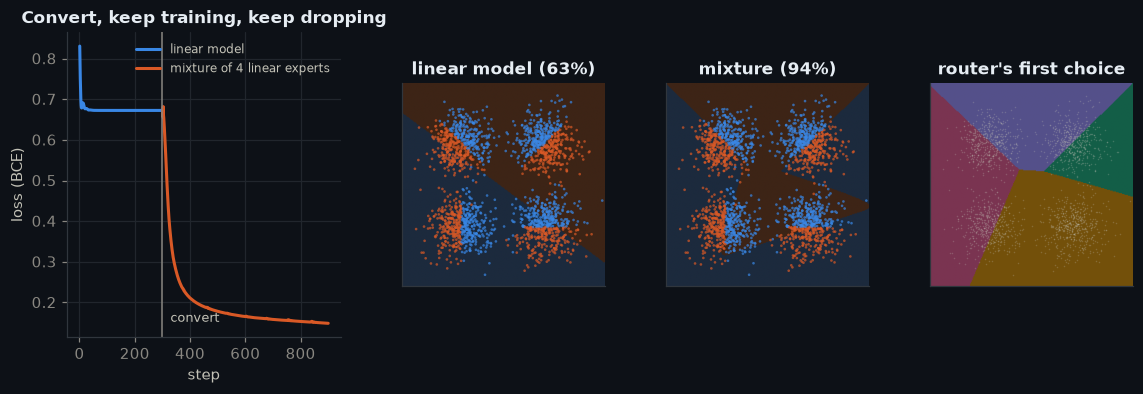

In [12]:
fig = plt.figure(figsize=(12.5, 3.6))
gs = fig.add_gridspec(1, 4, width_ratios=[1.35, 1, 1, 1], wspace=0.28)
a0 = fig.add_subplot(gs[0])
a0.plot(range(1, 301), toy_hist[:300], color=DENSE_C, label="linear model")
a0.plot(range(300, len(toy_hist) + 1), toy_hist[299:], color=MOE_C, label="mixture of 4 linear experts")
a0.axvline(300, color=MUTED, lw=1)
a0.text(300, 0.04, "  convert", transform=a0.get_xaxis_transform(), va="bottom", color=INK2, fontsize=8.5)
a0.set(xlabel="step", ylabel="loss (BCE)", title="Convert, keep training, keep dropping")
a0.legend(fontsize=8, loc="upper right")
gx, gy = torch.meshgrid(torch.linspace(-6, 6, 240), torch.linspace(-6, 6, 240), indexing="xy")
G = torch.stack([gx.flatten(), gy.flatten()], 1)
with torch.no_grad():
    z_lin = (lin(G).squeeze(1) > 0).float().view(240, 240)
    z_mol, top = mol(G)
    z_mol = (z_mol > 0).float().view(240, 240)
    regions = top[:, 0].view(240, 240)
two = LinearSegmentedColormap.from_list("two", ["#1c2a3d", "#3d2416"])
for ax, Z, title in ((fig.add_subplot(gs[1]), z_lin, f"linear model ({acc_lin:.0%})"),
                     (fig.add_subplot(gs[2]), z_mol, f"mixture ({acc_mol:.0%})")):
    ax.imshow(Z, extent=[-6, 6, -6, 6], origin="lower", cmap=two, alpha=1.0)
    ax.scatter(TX[:, 0], TX[:, 1], c=[SERIES[0] if y else SERIES[1] for y in TY.tolist()], s=3, alpha=0.7, lw=0)
    ax.set(title=title, xticks=[], yticks=[]); ax.grid(False)
ax = fig.add_subplot(gs[3])
ax.imshow(regions, extent=[-6, 6, -6, 6], origin="lower",
          cmap=LinearSegmentedColormap.from_list("e4", [SERIES[2], SERIES[3], SERIES[4], SERIES[6]], N=4), alpha=0.55)
ax.scatter(TX[:, 0], TX[:, 1], c=INK2, s=1, alpha=0.25, lw=0)
ax.set(title="router's first choice", xticks=[], yticks=[]); ax.grid(False)
savefig(fig, "toy_linear_to_moe")

The left panel is the shape the real experiment must also show: a curve that keeps falling
through the conversion. In the right panel each colour is the expert the router sends a point to
first. Nobody told it where the clusters are; it found them because that lowers the loss.

**Carry this forward:** "convert to MoE" means keep what the dense model knows, add a router,
and let the experts become different by training. Here the dense model is one line. Below it is a
20M-parameter transformer, and the same three steps apply.

---
## C · Building blocks: the dense model, the MoE layer, and the gates

> The MoE layer, the router, dropless dispatch and the balancing bias. Everything below is ordinary
> PyTorch; no MoE library.

The **dense model** is a small modern decoder: RoPE, RMSNorm, grouped-query attention, a SwiGLU
feed-forward block, tied embeddings. We call it the "linear model" because its
feed-forward block is a plain stack of linear layers that every token passes through in full.

In [13]:
class RMSNorm(nn.Module):
    def __init__(self, d, eps=1e-6):
        super().__init__()
        self.eps, self.weight = eps, nn.Parameter(torch.ones(d))

    def forward(self, x):                      # computed in fp32 whatever the autocast dtype
        xf = x.float()
        y = xf * torch.rsqrt(xf.pow(2).mean(-1, keepdim=True) + self.eps)
        return (y * self.weight).to(x.dtype)


def rope_cache(T, hd, base=10000.0):
    inv = 1.0 / base ** (torch.arange(0, hd, 2).float() / hd)
    f = torch.outer(torch.arange(T).float(), inv)            # [T, hd/2]
    return f.cos(), f.sin()


def apply_rope(x, cos, sin):                                  # x: [B, H, T, hd]
    h = x.shape[-1] // 2
    x1, x2 = x[..., :h].float(), x[..., h:].float()
    return torch.cat([x1 * cos - x2 * sin, x1 * sin + x2 * cos], -1).to(x.dtype)


class Attention(nn.Module):
    """Grouped-query attention: n_head query heads share n_kv key/value heads."""
    def __init__(self, c: GPTConfig):
        super().__init__()
        self.h, self.kv, self.hd = c.n_head, c.n_kv, c.d // c.n_head
        self.wq = nn.Linear(c.d, self.h * self.hd, bias=False)
        self.wk = nn.Linear(c.d, self.kv * self.hd, bias=False)
        self.wv = nn.Linear(c.d, self.kv * self.hd, bias=False)
        self.wo = nn.Linear(self.h * self.hd, c.d, bias=False)

    def forward(self, x, cos, sin, trace=None):
        B, T, _ = x.shape
        q = self.wq(x).view(B, T, self.h, self.hd).transpose(1, 2)
        k = self.wk(x).view(B, T, self.kv, self.hd).transpose(1, 2)
        v = self.wv(x).view(B, T, self.kv, self.hd).transpose(1, 2)
        q, k = apply_rope(q, cos, sin), apply_rope(k, cos, sin)
        rep = self.h // self.kv
        k, v = k.repeat_interleave(rep, dim=1), v.repeat_interleave(rep, dim=1)
        y = F.scaled_dot_product_attention(q, k, v, is_causal=True)
        if trace is not None:
            trace += [("attn: q", q.shape), ("attn: k after GQA repeat", k.shape), ("attn: out", y.shape)]
        return self.wo(y.transpose(1, 2).reshape(B, T, -1))


class SwiGLU(nn.Module):
    """The dense feed-forward block: d -> F (gate and up) -> d (down)."""
    def __init__(self, d, f):
        super().__init__()
        self.w_gate = nn.Linear(d, f, bias=False)   # weight [F, d]: one ROW per neuron
        self.w_up = nn.Linear(d, f, bias=False)     # weight [F, d]: one ROW per neuron
        self.w_down = nn.Linear(f, d, bias=False)   # weight [d, F]: one COLUMN per neuron

    def forward(self, x, trace=None):
        return self.w_down(F.silu(self.w_gate(x)) * self.w_up(x))

### The MoE layer

One module replaces `SwiGLU`. Read `route` and `dispatch` side by side with this picture:

```
token x [d] ──► router (fp32): logits = x · Wᵣᵀ  [E]
                 scores  = sigmoid(logits)                      (or softmax / √softplus)
                 choose  = top-k of (scores + bias + offset)    ← bias & offset steer the CHOICE only
                 weights = scores[chosen] / Σ scores[chosen] × route_scale
y = Σ_chosen weightᵢ · Expertᵢ(x)   +   SharedExpert(x)
```

* **Experts are stored stacked**: `gate, up: [E, w, d]`, `down: [E, d, w]`. Expert *e* is the slice
  `[e]`, a SwiGLU of inner width *w*.
* **Dropless dispatch**: sort the (token, expert) pairs by expert, pad each expert's group to the
  busiest expert's count *C*, run all experts as three batched matmuls on an `[E, C, d]` tensor,
  and scatter-add the weighted results back to their tokens. When routing is so uneven that padding
  would waste more than half the work (right after growth, or with a collapsed router), it switches
  to one **grouped GEMM** (`F.grouped_mm`, if this PyTorch and GPU support it) over the sorted
  tokens, with no padding at all. The last fallback is one small matmul per expert. All three paths
  are gated against each other. No token is ever dropped unless you ask for a `capacity_factor` (we
  do, in Part M, to measure what dropping would cost).
* **The router runs in fp32** with autocast switched off. Switch Transformer diverged when its router
  ran in 16-bit; a gate below checks this.
* **`route_scale`**: the top-k weights are renormalised to sum to 1 and then multiplied by this.
  When the experts are *pieces* of a dense block (partition), their outputs must be *summed*, so the
  scale is *k*. When the experts are *copies*, their outputs must be *averaged*, so the scale is 1.
  This is the "routed scaling factor" of the DeepSeek models (DeepSeek-V3 uses 2.5), derived in Part F instead
  of quoted.

🧠 **Intuition: a post office.** Every token is a letter addressed to *k* experts. The post office
does four things:

1. Photocopy each letter *k* times.
2. Sort the copies into one bin per expert.
3. Let each expert process its whole bin in one go.
4. Send the answers back and add them up at the sender's address, each answer weighted by how much
   the router trusted that expert.

The sorting is what makes it fast. An expert never looks at tokens that are not addressed to it.

🧠 **Intuition: the balancing bias is a thermostat.** After every step each expert's "door" gets
slightly harder to walk through if it was busier than average, and slightly easier if it was
quieter. The thermostat never touches *how good* the experts are (the gradient), only *which door*
the tokens choose.

<details><summary>📐 <b>The math:</b> the MoE layer, its shapes, dispatch as a permutation, and the bias as a controller</summary>

**The layer.** For a token $x \in \mathbb{R}^d$, with chosen set $\mathcal{T}(x)$, weights $g_i$ and shared
expert $S$:

$$y = \sum_{i \in \mathcal{T}(x)} g_i\,E_i(x) \;+\; S(x), \qquad E_i(x) = W^{\text{down}}_i\Big(\operatorname{SiLU}\big(W^{\text{gate}}_i x\big) \odot W^{\text{up}}_i x\Big).$$

| tensor | shape (ours, Stage 3) |
|---|---|
| tokens entering the layer | $[N, d] = [8192, 384]$ per micro-batch |
| router $W_r$, logits $z$ | $[E, d] = [32, 384]$, $[N, E]$ |
| chosen ids, weights | $[N, k] = [8192, 4]$ |
| `gate`, `up` / `down` | $[E, w, d] = [32, 192, 384]$ / $[E, d, w]$ |
| padded expert batch | $[E, C, d]$, with $C = \max_i n_i$ |
| shared expert | $w_s = 768$: $[768, 384]$ ×2, $[384, 768]$ |

**Dispatch as a permutation.**

1. Repeat each token $k$ times to get $Nk$ (token, expert) pairs.
2. Let $\Pi$ be the permutation that sorts those pairs by expert.
3. Run each expert on its contiguous block, then undo the sort:

$$Y_{\text{pairs}} = \Pi^\top\,\operatorname{blockdiag}\big(E_1, \dots, E_E\big)\,\Pi\,X_{\text{pairs}}, \qquad y_t = \sum_{\text{pairs of } t} g\cdot Y_{\text{pair}}.$$

Padding block $i$ to $C$ rows wastes $EC - Nk$ rows of compute. When that exceeds half of $Nk$, the
layer switches to a grouped GEMM, which needs no padding.

**The bias as a controller.** After each optimizer step, with $n_i$ counted over the whole batch:

$$b_i \;\leftarrow\; b_i + \gamma\,\operatorname{sign}\big(\bar n - n_i\big).$$

* The choice uses $\sigma_i + b_i$, but the weights use $\sigma_i$ only. So $\partial \ell / \partial b_i = 0$: the
  language loss's gradient is untouched. This is the "loss-free" in the name.
* It is an integral (bang-bang) controller: $b_i(t) = b_i(0) + \gamma \sum_{\tau < t} \operatorname{sign}(\bar n - n_i(\tau))$.
  It moves at most $\gamma$ per step, and stops drifting only when the loads are equal; with the
  sign rule it then jitters within about $\pm\gamma$.
* **How fast it acts.** Suppose a busy expert beats an idle one by a score gap $\Delta\sigma$. The busy
  bias falls by $\gamma$ per step and the idle one rises by $\gamma$, so they swap after about
  $\Delta\sigma / (2\gamma)$ steps. A gap of 0.05 at $\gamma = 10^{-3}$ takes about 25 steps.

**The sequence-level auxiliary loss** (DeepSeek-V3), averaged over the sequences in a batch:

$$\mathcal{L}_{\text{seq}} = \alpha \sum_{i=1}^{E} f_i P_i, \qquad f_i = \frac{E}{kT}\sum_{t=1}^{T} \mathbb{1}[i \in \mathcal{T}_t], \qquad P_i = \frac{1}{T}\sum_{t=1}^{T} \tilde\sigma_{t,i}.$$

At perfect balance $f_i = 1$ and $P_i = 1/E$, so $\mathcal{L}_{\text{seq}} = \alpha$. With $\alpha = 10^{-4}$ it is
a light guard against a single sequence collapsing onto a few experts, too small to fight the
language loss.

</details>

In [14]:
SCORE_FNS = {
    "softmax": lambda z: torch.softmax(z, dim=-1),
    "sigmoid": torch.sigmoid,
    "sqrt_softplus": lambda z: torch.sqrt(F.softplus(z)),       # DeepSeek-V4
}


def _probe_grouped_mm():
    """F.grouped_mm runs all experts in one kernel with no padding. Use it only if it exists here and is correct."""
    fn = getattr(F, "grouped_mm", None) or getattr(torch, "_grouped_mm", None)
    if fn is None or DEVICE != "cuda" or PREC == "fp32":
        return None
    try:
        x = torch.randn(8, 16, device=DEVICE, dtype=AMP_DTYPE)
        W = torch.randn(3, 8, 16, device=DEVICE, dtype=AMP_DTYPE)
        offs = torch.tensor([4, 4, 8], device=DEVICE, dtype=torch.int32)          # includes an empty group
        y = fn(x, W.transpose(1, 2), offs=offs)
        ref = torch.cat([x[:4] @ W[0].t(), x[4:] @ W[2].t()])
        return fn if torch.allclose(y.float(), ref.float(), atol=1e-1, rtol=1e-2) else None
    except Exception:
        return None

GROUPED_MM = _probe_grouped_mm()
print("grouped_mm:", "available" if GROUPED_MM else "not available (padded + loop dispatch only)")


def autocast_dtype(t):
    try:
        if torch.is_autocast_enabled(t.device.type):
            return torch.get_autocast_dtype(t.device.type)
    except TypeError:                                            # older torch
        if t.is_cuda and torch.is_autocast_enabled():
            return torch.get_autocast_gpu_dtype()
    return t.dtype


class MoEFFN(nn.Module):
    def __init__(self, d, m: MoEConfig, n_layer=8):
        super().__init__()
        E, w = m.n_exp, m.width
        self.d, self.E, self.w, self.k, self.cfg = d, E, w, m.top_k, m
        self.gate = nn.Parameter(torch.randn(E, w, d) * 0.02)
        self.up = nn.Parameter(torch.randn(E, w, d) * 0.02)
        self.down = nn.Parameter(torch.randn(E, d, w) * 0.02 / math.sqrt(2 * n_layer))
        self.router = nn.Parameter(torch.randn(E, d) * 0.002)    # 0.1 x the usual 0.02 (Switch)
        self.shared = SwiGLU(d, m.shared) if m.shared else None
        self.register_buffer("bias", torch.zeros(E))              # loss-free balancing
        self.register_buffer("offset", torch.zeros(E))            # staggered clone offsets (growth lab)
        self.register_buffer("mask", torch.ones(E, dtype=torch.bool))  # pruning (Part L)
        self.register_buffer("counts", torch.zeros(E))            # load since the last bias update
        self.register_buffer("window", torch.zeros(E))            # load since the last log read
        self.route_scale = float(m.top_k if m.route_scale is None else m.route_scale)
        self.gumbel = False             # probabilistic top-k (growth window)
        self.capacity_factor = None     # None = dropless
        self.record = False             # keep this forward's routing for analysis
        self.dispatch_mode = "auto"     # "auto" | "padded" | "grouped" | "loop" (all give the same result)
        self.aux = None
        self.last = {}

    # ---- choosing -------------------------------------------------------------------------
    def route(self, x2):
        with torch.autocast(device_type=x2.device.type, enabled=False):
            rdt = torch.float64 if x2.dtype == torch.float64 else torch.float32   # fp32, never 16-bit
            logits = x2.to(rdt) @ self.router.to(rdt).t()                 # [N, E]
            scores = SCORE_FNS[self.cfg.score](logits)                    # [N, E]
            sel = scores.detach() + self.bias + self.offset               # selection-only terms
            if self.gumbel and self.training:
                # sample k experts without replacement, P ~ exp(z-scored preference): Gumbel top-k
                z = (sel - sel.mean(-1, keepdim=True)) / (sel.std(-1, keepdim=True) + 1e-6)
                u = torch.rand_like(z).clamp_(1e-9, 1 - 1e-9)
                sel = z - torch.log(-torch.log(u))
            sel = sel.masked_fill(~self.mask, float("-inf"))
            topi = sel.topk(self.k, dim=-1).indices                       # [N, k]  (no gradient)
            w = scores.gather(1, topi)                                    # weights from scores, not bias
            w = w / w.sum(-1, keepdim=True).clamp_min(1e-9) * self.route_scale
        with torch.no_grad():
            if self.training:
                c = torch.bincount(topi.reshape(-1), minlength=self.E).float()
                self.counts += c
                self.window += c
            if self.record:
                self.last["topi"], self.last["w"] = topi, w.detach()
            self.last["z"] = torch.logsumexp(logits, -1).pow(2).mean()     # router z diagnostic
        return topi, w, scores

    # ---- computing (dropless by default) ----------------------------------------------------
    def dispatch(self, x2, topi, w, trace=None):
        N, d = x2.shape
        flat_e = topi.reshape(-1)                                         # [N*k]
        order = torch.argsort(flat_e, stable=True)                        # group by expert, keep token order
        e_sorted = flat_e[order]
        tok = torch.arange(N, device=x2.device).repeat_interleave(self.k)[order]
        wts = w.reshape(-1)[order]
        counts = torch.bincount(flat_e, minlength=self.E)
        if self.capacity_factor is not None:                              # old-style capacity, for Part M
            cap = math.ceil(N * self.k / self.E * self.capacity_factor)
            starts = torch.cumsum(counts, 0) - counts
            rank = torch.arange(order.numel(), device=x2.device) - starts[e_sorted]
            keep = rank < cap                                             # earlier tokens win the slots
            self.last["dropped"] = int((~keep).sum())
            tok, e_sorted, wts = tok[keep], e_sorted[keep], wts[keep]
            counts = torch.bincount(e_sorted, minlength=self.E)
        dt = autocast_dtype(x2)
        g, u, dn = self.gate.to(dt), self.up.to(dt), self.down.to(dt)
        xs = x2.to(dt)[tok]                                               # [M, d] (token, expert) pairs, by expert
        M = tok.numel()
        C = int(counts.max()) if M else 0                                 # one host sync per layer
        mode = self.dispatch_mode
        if mode == "auto":
            mode = ("padded" if self.E * C <= 1.5 * M + 64 * self.E
                    else "grouped" if (GROUPED_MM is not None and x2.is_cuda and dt in (torch.bfloat16, torch.float16)) else "loop")
        if M and mode == "grouped":
            # uneven routing: one grouped GEMM over the sorted tokens, no padding at all
            offs = torch.cumsum(counts, 0).to(torch.int32)
            h = F.silu(GROUPED_MM(xs, g.transpose(1, 2), offs=offs)) * GROUPED_MM(xs, u.transpose(1, 2), offs=offs)
            ys = GROUPED_MM(h, dn.transpose(1, 2), offs=offs)
        elif M and mode == "padded":
            # balanced enough: pad every expert's group to C rows and run three batched matmuls
            pos = torch.arange(M, device=x2.device) - (torch.cumsum(counts, 0) - counts)[e_sorted]
            buf = xs.new_zeros(self.E, C, d).index_put((e_sorted, pos), xs)          # [E, C, d]
            h = F.silu(torch.bmm(buf, g.transpose(1, 2))) * torch.bmm(buf, u.transpose(1, 2))
            ys = torch.bmm(h, dn.transpose(1, 2))[e_sorted, pos]                    # [M, d]
        else:
            # fallback: one small matmul per expert
            outs, start = [], 0
            for e, c in enumerate(counts.tolist()):
                if c:
                    xe = xs[start:start + c]
                    outs.append((F.silu(xe @ g[e].t()) * (xe @ u[e].t())) @ dn[e].t())
                    start += c
            ys = torch.cat(outs) if outs else xs[:0]
        ys = ys * wts[:, None].to(dt)
        acc = torch.float64 if x2.dtype == torch.float64 else torch.float32     # accumulate the k outputs in fp32+
        y = torch.zeros(N, d, device=x2.device, dtype=acc).index_add_(0, tok, ys.to(acc))
        if trace is not None:
            trace += [("moe: tokens x d", x2.shape), ("moe: top-k ids", topi.shape),
                      ("moe: (token,expert) pairs", tok.shape), ("moe: expert gate stack", self.gate.shape),
                      ("moe: padded expert batch [E, C, d]", (self.E, C, d)),
                      ("moe: routed output", y.shape)]
        return y.to(x2.dtype)

    def reference(self, x2, topi, w):
        """Slow and obviously correct: run every expert on every token, keep the chosen ones."""
        h = F.silu(torch.einsum("nd,ewd->new", x2, self.gate)) * torch.einsum("nd,ewd->new", x2, self.up)
        ye = torch.einsum("new,edw->ned", h, self.down)
        W = torch.zeros(x2.shape[0], self.E, dtype=x2.dtype, device=x2.device).scatter(1, topi, w.to(x2.dtype))
        return torch.einsum("ne,ned->nd", W, ye)

    def forward(self, x, trace=None):
        B, T, d = x.shape
        x2 = x.reshape(-1, d)
        topi, w, scores = self.route(x2)
        y = self.dispatch(x2, topi, w, trace)
        aux = torch.zeros((), device=x.device)
        if self.training and (self.cfg.seq_alpha > 0 or self.cfg.switch_alpha > 0):
            hit = torch.zeros(x2.shape[0], self.E, device=x.device).scatter_(1, topi, 1.0)  # [N, E]
            p = scores / scores.sum(-1, keepdim=True)                                       # affinities
            if self.cfg.seq_alpha > 0:        # DeepSeek-V3 sequence-wise loss: alpha * sum_i f_i P_i per sequence
                f = hit.view(B, T, self.E).mean(1) * (self.E / self.k)
                P = p.view(B, T, self.E).mean(1)
                aux = aux + self.cfg.seq_alpha * (f * P).sum(-1).mean()
            if self.cfg.switch_alpha > 0:     # Switch: alpha * E * sum_i f_i P_i over the batch
                f = hit.mean(0) / self.k
                aux = aux + self.cfg.switch_alpha * self.E * (f * p.mean(0)).sum()
        self.aux = aux
        out = y.view(B, T, d)
        if self.shared is not None:
            out = out + self.shared(x)
        return out

    # ---- balancing: runs after every optimizer step ------------------------------------
    @torch.no_grad()
    def update_bias(self, gamma):
        if self.cfg.balance == "bias" and gamma > 0:
            self.bias += gamma * torch.sign(self.counts.mean() - self.counts)
        self.counts.zero_()

    def read_window(self):
        c = self.window.clone()
        self.window.zero_()
        return c

grouped_mm: available


### The model that holds either block

`GPT(GCFG)` is the dense model. `GPT(GCFG, MoEConfig(...))` is the same model with every
feed-forward block replaced by `MoEFFN`. Attention, embeddings and norms are identical, which is what
makes the conversion a pure transplant of the feed-forward weights.

In [15]:
class Block(nn.Module):
    def __init__(self, c, moe=None):
        super().__init__()
        self.n1, self.attn, self.n2 = RMSNorm(c.d), Attention(c), RMSNorm(c.d)
        self.ffn = MoEFFN(c.d, moe, c.n_layer) if moe else SwiGLU(c.d, c.ffn)

    def forward(self, x, cos, sin, trace=None):
        x = x + self.attn(self.n1(x), cos, sin, trace)
        return x + self.ffn(self.n2(x), trace)


class GPT(nn.Module):
    def __init__(self, c: GPTConfig, moe: MoEConfig = None):
        super().__init__()
        self.c, self.moe_cfg = c, moe
        self.emb = nn.Embedding(c.vocab, c.d)
        self.blocks = nn.ModuleList(Block(c, moe) for _ in range(c.n_layer))
        self.norm = RMSNorm(c.d)
        cos, sin = rope_cache(c.ctx, c.d // c.n_head)
        self.register_buffer("cos", cos, persistent=False)
        self.register_buffer("sin", sin, persistent=False)
        for n, p in self.named_parameters():
            if p.dim() == 2 and not n.endswith("router"):
                std = 0.02 / math.sqrt(2 * c.n_layer) if n.endswith(("wo.weight", "w_down.weight")) else 0.02
                nn.init.normal_(p, 0.0, std)

    def forward(self, idx, targets=None, per_seq=False, trace=None):
        T = idx.shape[1]
        x = self.emb(idx)
        if trace is not None:
            trace.append(("embeddings", x.shape))
        for b in self.blocks:
            x = b(x, self.cos[:T], self.sin[:T], trace)
            trace = None                       # trace the first block only
        logits = self.norm(x) @ self.emb.weight.t()          # tied output head
        if targets is None:
            return logits
        loss = F.cross_entropy(logits.float().reshape(-1, logits.shape[-1]), targets.reshape(-1),
                               reduction="none").view(targets.shape)
        return logits, (loss.mean(1) if per_seq else loss.mean())

    def moe_layers(self):
        return [b.ffn for b in self.blocks if isinstance(b.ffn, MoEFFN)]

    def aux_loss(self):
        return sum((m.aux for m in self.moe_layers() if m.aux is not None), torch.zeros((), device=self.emb.weight.device))


def n_params(model):
    return sum(p.numel() for p in model.parameters())


def n_active(model):
    """Parameters one token touches: everything except the experts it did not choose."""
    idle = sum((m.E - m.k) * 3 * m.d * m.w for m in model.moe_layers())
    return n_params(model) - idle


@torch.no_grad()
def generate(model, tok, prompt, n=48, temp=0.8, top_k=40, seed=0):
    g = torch.Generator(device=DEVICE).manual_seed(seed)
    ids = torch.tensor([tok.encode(prompt).ids], device=DEVICE)
    was = model.training
    model.eval()
    for _ in range(n):
        with torch.autocast(DEVICE, dtype=AMP_DTYPE, enabled=PREC != "fp32"):
            logits = model(ids[:, -model.c.ctx:])[:, -1].float() / temp
        v, i = logits.topk(top_k)
        nxt = i.gather(1, torch.multinomial(torch.softmax(v, -1), 1, generator=g))
        ids = torch.cat([ids, nxt], 1)
        if nxt.item() == 0:
            break
    model.train(was)
    return tok.decode(ids[0].tolist())

### Shape trace: the dimensions you need to be aware of

One forward pass of a 2-sequence batch through the first block of an MoE model with the final
(Stage 3) shape: 32 routed experts of width 192, top-4, one shared expert of width 768.

In [16]:
torch.manual_seed(0)
_m = GPT(GCFG, MoEConfig(n_exp=32, width=192, top_k=4, shared=768)).eval()
_tr = []
with torch.no_grad():
    _m(torch.randint(0, GCFG.vocab, (2, 16)), trace=_tr)
for name, shape in _tr:
    print(f"{name:<38} {tuple(shape)}")
_ffn = _m.blocks[0].ffn
print(f"{'router weight (fp32)':<38} {tuple(_ffn.router.shape)}  dtype={_ffn.router.dtype}")
print(f"{'shared expert gate':<38} {tuple(_ffn.shared.w_gate.weight.shape)}")
del _m, _ffn

embeddings                             (2, 16, 384)
attn: q                                (2, 6, 16, 64)
attn: k after GQA repeat               (2, 6, 16, 64)
attn: out                              (2, 6, 16, 64)
moe: tokens x d                        (32, 384)
moe: top-k ids                         (32, 4)
moe: (token,expert) pairs              (128,)
moe: expert gate stack                 (32, 192, 384)
moe: padded expert batch [E, C, d]     (32, 12, 384)
moe: routed output                     (32, 384)
router weight (fp32)                   (32, 384)  dtype=torch.float32
shared expert gate                     (768, 384)


> **Pitfall: `nn.Linear` stores weights as `[out, in]`.** A *neuron* of the feed-forward block is a
> **row** of `w_gate.weight` and of `w_up.weight` (shape `[F, d]`), and a **column** of
> `w_down.weight` (shape `[d, F]`). Slice rows of gate/up together with the *same* columns of down,
> or you build an expert out of mismatched halves and nothing errors, it just trains worse.

### Gates: exact checks that must pass before anything trains

Each gate is an equality the code must satisfy. They run in fp64 on the CPU in about a second, so
they run in every mode, including `learn`.

In [17]:
torch.manual_seed(0)
_d, _F = 16, 32
_dense = SwiGLU(_d, _F).double()
_x = torch.randn(64, _d, dtype=torch.float64)

# 1. An MoE with one expert, top-1 and scale 1 IS the dense block.
_one = MoEFFN(_d, MoEConfig(n_exp=1, width=_F, top_k=1, route_scale=1.0)).double().eval()
with torch.no_grad():
    _one.gate[0].copy_(_dense.w_gate.weight); _one.up[0].copy_(_dense.w_up.weight); _one.down[0].copy_(_dense.w_down.weight)
gate("E=1, k=1 MoE equals the dense SwiGLU", torch.allclose(_one(_x[None])[0], _dense(_x), atol=1e-12))

# 2. Sorted dropless dispatch equals the run-every-expert reference, forward and backward.
_moe = MoEFFN(_d, MoEConfig(n_exp=8, width=12, top_k=3)).double()
_t, _w, _ = _moe.route(_x)
_b = _moe.reference(_x, _t, _w)
_gb = torch.autograd.grad(_b.pow(2).sum(), [_moe.gate, _moe.down, _moe.router], retain_graph=True)
for _path in ("padded", "loop"):
    _moe.dispatch_mode = _path
    _t, _w, _ = _moe.route(_x)
    _a = _moe.dispatch(_x, _t, _w)
    _ga = torch.autograd.grad(_a.pow(2).sum(), [_moe.gate, _moe.down, _moe.router])
    gate(f"{_path} dispatch == reference (forward and gradients)",
         torch.allclose(_a, _b, atol=1e-12) and all(torch.allclose(a, b, atol=1e-10) for a, b in zip(_ga, _gb)))
_moe.dispatch_mode = "auto"
if GROUPED_MM is not None:                       # GPU only: the grouped GEMM path, in the training dtype
    _mg = MoEFFN(64, MoEConfig(n_exp=8, width=32, top_k=3)).to(DEVICE)
    _xg = torch.randn(512, 64, device=DEVICE)
    _outs = {}
    with torch.autocast(DEVICE, dtype=AMP_DTYPE):
        for _path in ("padded", "grouped", "loop"):
            _mg.dispatch_mode = _path
            _tg, _wg, _ = _mg.route(_xg)
            _outs[_path] = _mg.dispatch(_xg, _tg, _wg).float()
    gate("grouped-GEMM dispatch == padded == loop (GPU, training dtype)",
         torch.allclose(_outs["grouped"], _outs["loop"], atol=2e-2, rtol=2e-2) and torch.allclose(_outs["padded"], _outs["loop"], atol=2e-2, rtol=2e-2),
         f"max diff {(_outs['grouped'] - _outs['loop']).abs().max():.1e}")
    del _mg

# 3. The router learns: top-k has no gradient, but the weights it multiplies by do.
gate("router receives a gradient", _ga[2].abs().sum() > 0, f"|grad| = {_ga[2].abs().sum():.3e}")

# 4. Router logits stay fp32 under 16-bit autocast.
_moe32 = MoEFFN(_d, MoEConfig(n_exp=8, width=12, top_k=3))
with torch.autocast("cpu", dtype=torch.bfloat16):
    _, _w32, _s32 = _moe32.route(_x.float())
gate("router runs in fp32 under bf16 autocast", _s32.dtype == torch.float32 and _w32.dtype == torch.float32)

# 5. The balancing bias changes WHICH experts are chosen, never their weights.
_moe.eval()
with torch.no_grad():
    t0, w0, s0 = _moe.route(_x)
    _moe.bias[t0[0, 0]] -= 10.0                      # push token 0's favourite out
    t1, w1, s1 = _moe.route(_x)
    _moe.bias.zero_()
_chosen = set(t1[0].tolist())
_expect = s1[0].gather(0, t1[0]) / s1[0].gather(0, t1[0]).sum() * _moe.route_scale
gate("bias changes the choice, not the weights",
     t0[0, 0].item() not in _chosen and torch.allclose(w1[0], _expect), f"token 0: {t0[0].tolist()} -> {t1[0].tolist()}")

[PASS] E=1, k=1 MoE equals the dense SwiGLU
[PASS] padded dispatch == reference (forward and gradients)
[PASS] loop dispatch == reference (forward and gradients)


[PASS] grouped-GEMM dispatch == padded == loop (GPU, training dtype)  (max diff 0.0e+00)
[PASS] router receives a gradient  (|grad| = 2.534e-05)
[PASS] router runs in fp32 under bf16 autocast
[PASS] bias changes the choice, not the weights  (token 0: [0, 7, 6] -> [7, 6, 2])


---
## D · Data: TinyStories, a 4,096-token BPE, and a fixed batch order

* **Corpus.** `TinyStoriesV2-GPT4`: short, simple English stories. A ~20M-parameter model is far
  from saturated on it, so a bigger MoE has room to show a gain. Only the first ~240 MB of the 2.2 GB
  training file is streamed, using the standard library, so nothing beyond `tokenizers` is installed.
* **Tokenizer.** A byte-level BPE with 4,096 tokens, trained here on 30 MB. With GPT-2's 50k vocabulary
  the embeddings alone would be 19M parameters and would dwarf the feed-forward blocks this
  experiment is about. At 4,096 they are 1.6M.
* **Batch order.** The token stream is cut into 257-token windows and shuffled once with a fixed
  seed. Step *s* of any run reads windows `[cursor, cursor + batch)`. Two branches that start from
  the same checkpoint therefore see *identical* batches, so the MoE-vs-dense comparison is paired.
  The main path stays under one epoch.

In [18]:
TS_URL = "https://huggingface.co/datasets/roneneldan/TinyStories/resolve/main/TinyStoriesV2-GPT4-{}.txt"
EOT = "<|endoftext|>"

def fetch(url, part, limit=None, retries=10):
    """Resumable download: on a dropped connection, continue from the bytes already on disk."""
    for attempt in range(retries):
        have_b = part.stat().st_size if part.exists() else 0
        if limit is not None and have_b >= limit:
            return
        rng = f"bytes={have_b}-" + (str(limit - 1) if limit else "")
        try:
            req = urllib.request.Request(url, headers={"Range": rng, "User-Agent": "moe14-notebook"})
            with urllib.request.urlopen(req, timeout=60) as r:
                mode = "ab" if (have_b and r.status == 206) else "wb"   # server ignored Range: restart
                with open(part, mode) as f:
                    got = have_b if mode == "ab" else 0
                    while limit is None or got < limit:
                        chunk = r.read(1 << 20)
                        if not chunk:
                            return
                        f.write(chunk)
                        got += len(chunk)
            return
        except Exception as e:
            print(f"  download interrupted at {have_b / 2**20:.0f} MB ({type(e).__name__}); resuming ({attempt + 1}/{retries})")
            time.sleep(min(30, 3 * (attempt + 1)))
    raise RuntimeError("Could not download TinyStories from huggingface.co. Check the network and re-run this cell.")


def stream_text(split, max_mb=None):
    """Download (the first max_mb of) a TinyStories file, cut at a story boundary, cache it."""
    out = DATA / (f"ts_{split}.txt" if max_mb is None else f"ts_{split}_{max_mb}mb.txt")
    if out.exists():
        return out
    part = out.with_suffix(".part")
    print(f"downloading TinyStoriesV2-GPT4-{split}" + (f" (first {max_mb} MB)" if max_mb else ""))
    fetch(TS_URL.format(split), part, None if max_mb is None else max_mb * 2**20)
    text = part.read_bytes().decode("utf-8", errors="ignore")
    if max_mb is not None:
        text = text[: text.rfind(EOT) + len(EOT)]
    out.write_text(text, encoding="utf-8", newline="")
    part.unlink()
    return out


def stories(path, max_mb=None):
    text = path.read_text(encoding="utf-8")
    if max_mb is not None:
        text = text[: max_mb * 2**20]
    for s in text.split(EOT):
        s = s.strip()
        if s:
            yield s


def build_tokenizer(train_path):
    from tokenizers import Tokenizer, models, trainers, pre_tokenizers, decoders
    f = DATA / f"bpe4096_{BUDGET['bpe_mb']}mb.json"
    if f.exists():
        return Tokenizer.from_file(str(f))
    tok = Tokenizer(models.BPE())
    tok.pre_tokenizer = pre_tokenizers.ByteLevel(add_prefix_space=False)
    tok.decoder = decoders.ByteLevel()
    trainer = trainers.BpeTrainer(vocab_size=GCFG.vocab, special_tokens=[EOT], min_frequency=2,
                                  initial_alphabet=pre_tokenizers.ByteLevel.alphabet(), show_progress=False)
    tok.train_from_iterator(stories(train_path, BUDGET["bpe_mb"]), trainer)
    tok.save(str(f))
    return tok


def encode_file(tok, path, out):
    if out.exists():
        return np.memmap(out, dtype=np.uint16, mode="r")
    parts, batch = [], []
    eot = tok.token_to_id(EOT)
    def flush():
        for e in tok.encode_batch(batch):
            parts.append(np.asarray(e.ids + [eot], dtype=np.uint16))
        batch.clear()
    for s in stories(path):
        batch.append(s)
        if len(batch) == 20000:
            flush()
    flush()
    arr = np.concatenate(parts)
    arr.tofile(out)
    return np.memmap(out, dtype=np.uint16, mode="r")


class Stream:
    """Shuffled, non-overlapping 257-token windows; batch(cursor, B) is a pure function of its args."""
    def __init__(self, tokens, ctx, seed=0, shuffle=True):
        self.tok, self.ctx = tokens, ctx
        self.n = (len(tokens) - 1) // ctx
        self.perm = np.random.default_rng(seed).permutation(self.n) if shuffle else np.arange(self.n)
        self.ar = np.arange(ctx + 1)

    def batch(self, cursor, B):
        idx = self.perm[(cursor + np.arange(B)) % self.n] * self.ctx
        t = torch.from_numpy(self.tok[idx[:, None] + self.ar].astype(np.int64))
        if DEVICE == "cuda":
            t = t.pin_memory().to(DEVICE, non_blocking=True)
        return t[:, :-1], t[:, 1:]

In [19]:
TOK = TRAIN = VAL = None
if COMPUTE:
    t0 = time.time()
    train_txt = stream_text("train", BUDGET["train_mb"])
    valid_txt = stream_text("valid")
    TOK = build_tokenizer(train_txt)
    assert TOK.get_vocab_size() == GCFG.vocab and TOK.token_to_id(EOT) == 0
    train_ids = encode_file(TOK, train_txt, DATA / f"train_{BUDGET['train_mb']}mb_{BUDGET['bpe_mb']}.bin")
    val_ids = encode_file(TOK, valid_txt, DATA / f"val_{BUDGET['bpe_mb']}.bin")
    TRAIN = Stream(train_ids, GCFG.ctx, seed=0)
    VAL = Stream(val_ids, GCFG.ctx, shuffle=False)
    need = (S1 + S2 + S3) * BUDGET["batch"]
    print(f"train: {len(train_ids) / 1e6:.1f}M tokens ({TRAIN.n:,} windows) | val: {len(val_ids) / 1e6:.2f}M tokens"
          f" | chars/token {train_txt.stat().st_size / len(train_ids):.2f} | {time.time() - t0:.0f}s")
    assert TRAIN.n >= need, f"main path needs {need:,} windows for one epoch; raise BUDGET['train_mb']"
    R["data"] = dict(train_tokens=int(len(train_ids)), val_tokens=int(len(val_ids)),
                     epoch_fraction=need / TRAIN.n,
                     sample=[TOK.decode([i]) for i in TOK.encode("Once upon a time, Lily saw a big red ball.").ids])
    save_results()
if have("data"):
    print("epoch fraction used by the main path:", round(R["data"]["epoch_fraction"], 3))
    print("tokenized:", "|".join(R["data"]["sample"]), f"({len(R['data']['sample'])} tokens)")

train: 62.4M tokens (243,899 windows) | val: 5.58M tokens | chars/token 4.03 | 0s
epoch fraction used by the main path: 0.72
tokenized: Once| upon| a| time|,| Lily| saw| a| big| red| ball|. (12 tokens)


---
## E · Stage 1: train the dense ("linear") model

### The training loop, written once and reused by every run

* **AdamW** (β = 0.9/0.95, weight decay 0.1 on matrices, none on norms or the router), gradient
  clipping at 1.0, bf16 autocast (fp16 + `GradScaler` on a T4).
* **Warmup-stable-decay (WSD) schedule.** Stage 1 warms up and then stays at the peak learning rate.
  It never decays, because a model you are about to convert should still be in its fast-learning
  phase. Both branches after T1 share one schedule: a 50-step re-warm, a flat stretch, and a linear
  decay over the last 20% of T1→T3.
* **Micro-batches.** A batch of 64 sequences runs as 2 micro-batches of 32 with gradient
  accumulation, so the MoE fits in 8 GB.
* **After every optimizer step** each MoE layer nudges its balancing bias, using the load
  counted over the *whole* batch, both micro-batches.
* **Logging.** Train loss every step; validation loss, per-expert load, MaxVio and the router
  z-diagnostic every `eval_every` steps.
* **Hot-plug.** Large runs read knobs such as the balancing weight from a file, so they can be
  changed without stopping. Every 50 steps the loop re-reads `hotplug.json` if it exists, so
  `gamma`, `seq_alpha`, `lr_mult` or `freeze_router` can be changed while a run is going.

🧠 **Intuition: why convert in the stable phase.** A model whose learning rate has already decayed
has settled into a narrow valley. Surgery knocks it out of that valley, and with a tiny learning
rate it cannot climb back to a good place. With the learning rate still high, it re-settles
quickly.

🧠 **Intuition: batch size and learning rate are coupled.** Each step follows a noisy estimate of
the gradient. A smaller batch is a noisier estimate. To keep the same amount of "shaking", the step
must shrink with the batch. This notebook learned that the hard way: its first full run gave the
labs a 4× smaller batch at the same learning rate, and every lab's loss *rose*.

<details><summary>📐 <b>The math:</b> the WSD schedule, and the noise scale η/B</summary>

**Warmup-stable-decay**, with warmup length $t_w$, decay start $t_d$ and end $t_{\text{end}}$:

$$\eta(t) = \begin{cases} \eta_{\max}\, t / t_w & t < t_w \\ \eta_{\max} & t_w \le t < t_d \\ \eta_{\max}\Big(1 - 0.9\,\dfrac{t - t_d}{t_{\text{end}} - t_d}\Big) & t \ge t_d \end{cases}$$

Ours: $\eta_{\max} = 1.2\times10^{-3}$. Stage 1 never reaches $t_d$. After T1 there is a 50-step re-warm,
then the last 20% of T1→T3 decays to $0.1\,\eta_{\max}$. The bias speed $\gamma$ is set to 0 for that last
stretch, as in DeepSeek-V3.

**The noise scale.** A minibatch of $B$ sequences gives $\hat g = g + \xi$, with
$\operatorname{Cov}(\xi) \approx \Sigma / B$. One step $\Delta\theta = -\eta \hat g$ adds noise of covariance
$\eta^2 \Sigma / B$.

To make the same progress you need about $1/\eta$ steps, so the noise accumulated over that
progress is about $\eta\,\Sigma / B$. The "temperature" of training is $\eta / B$.

| run | $\eta / B$ |
|---|---|
| main runs | $1.2\times10^{-3} / 64 = 1.9\times10^{-5}$ |
| first labs (batch 16 at the same $\eta$) | $1.2\times10^{-3} / 16 = 7.5\times10^{-5}$, 4× hotter: the loss rose |
| labs now ($\eta \times 16/64$) | $3\times10^{-4} / 16 = 1.9\times10^{-5}$, the main runs' temperature |

</details>

In [20]:
def amp():
    return torch.autocast(DEVICE, dtype=AMP_DTYPE, enabled=PREC != "fp32")


def make_opt(model, lr=None):
    dec, nodec = [], []
    for n, p in model.named_parameters():
        (dec if p.dim() >= 2 and not n.endswith("router") else nodec).append(p)
    return torch.optim.AdamW([{"params": dec, "weight_decay": 0.1}, {"params": nodec, "weight_decay": 0.0}],
                             lr=lr or BUDGET["peak_lr"], betas=(0.9, 0.95), eps=1e-8)


def make_scaler():
    try:
        return torch.amp.GradScaler("cuda", enabled=PREC == "fp16")
    except (AttributeError, TypeError):
        return torch.cuda.amp.GradScaler(enabled=PREC == "fp16")


@torch.no_grad()
def evaluate(model, n_batches, B=32, per_batch=False):
    was = model.training
    model.eval()
    out = []
    for i in range(n_batches):
        x, y = VAL.batch(i * B, B)
        with amp():
            _, l = model(x, y)
        out.append(l.item())
    model.train(was)
    return out if per_batch else float(np.mean(out))


PROBE = None
def probe_batch():
    global PROBE
    if PROBE is None:
        PROBE = VAL.batch(10_000, 8)[0]          # fixed 8 x 256 tokens, never used for val loss
    return PROBE


@torch.no_grad()
def route_probe(model):
    """Top-k ids per layer for the probe batch, in eval mode (hard top-k, no Gumbel)."""
    moes = model.moe_layers()
    was = model.training
    model.eval()
    for m in moes:
        m.record = True
    with amp():
        model(probe_batch())
    out = [m.last["topi"].clone() for m in moes]
    for m in moes:
        m.record = False
    model.train(was)
    return out


def family_share(topis, fam):
    """Fraction of tokens whose k choices all come from one clone family (fam clones per family)."""
    return float(np.mean([((t // fam) == (t[:, :1] // fam)).all(1).float().mean().item() for t in topis]))


def lr_stage1(s):
    return BUDGET["peak_lr"] * min(1.0, (s + 1) / BUDGET["warmup"])

POST = S2 + S3                      # steps after T1 on both branches
DECAY_START = int(0.8 * POST)
def lr_post(s):
    peak = BUDGET["peak_lr"]
    if s < DECAY_START:
        return peak * min(1.0, 0.1 + 0.9 * (s + 1) / BUDGET["rewarm"])
    return peak * (1 - 0.9 * (s - DECAY_START) / max(1, POST - DECAY_START))
def gamma_post(s):                  # DeepSeek-V3: bias updates stop for the final stretch
    return 1.0 if s < DECAY_START else 0.0
LAB_PEAK = BUDGET["peak_lr"] * BUDGET["lab_batch"] / BUDGET["batch"]   # same lr/batch noise scale as the main runs
def lr_lab(s):
    return LAB_PEAK * min(1.0, 0.1 + 0.9 * (s + 1) / BUDGET["rewarm"])
def const1(s):
    return 1.0


SNAP = {}                            # probe routing snapshots (kept in memory, not in results.json)

def train_run(name, model, opt, cursor, steps, B, lr_fn, *, s0=0, gamma_fn=const1, eval_every=50,
              val_batches=16, gumbel_steps=0, offset_fn=None, snap_at=(), eta=False, tokens0=0.0):
    """Train `steps` steps from batch `cursor`. s0 = position inside the schedule (for stage 3)."""
    scaler = make_scaler()
    moes = model.moe_layers()
    fam = moes[0].cfg.family if moes else 1
    log = {k: [] for k in ("loss", "gnorm", "lr", "eval_step", "val", "load", "maxvio", "z", "bias", "family", "tok_s")}
    log.update(name=name, steps=steps, batch=B, tokens0=tokens0, s0=s0,
               params=n_params(model), active=n_active(model))
    if DEVICE == "cuda":
        torch.cuda.reset_peak_memory_stats()
    hp, t_last, tok_last = {}, time.time(), 0
    t_start = t_last
    model.train()
    for s in range(steps):
        si = s0 + s
        if s % 50 == 0:
            hp = read_hotplug()
            for m in moes:
                m.cfg.seq_alpha = hp.get("seq_alpha", m.cfg.seq_alpha)
                m.router.requires_grad_(not hp.get("freeze_router", False))
        lr = lr_fn(si) * hp.get("lr_mult", 1.0)
        for g in opt.param_groups:
            g["lr"] = lr
        for m in moes:
            m.gumbel = s < gumbel_steps
        if offset_fn is not None:
            offset_fn(s)
        if s in snap_at:
            SNAP.setdefault(name, {})[s] = route_probe(model)
        nmb = max(1, B // BUDGET["micro_batch"])            # micro-batches; load is still counted over the whole batch
        loss = 0.0
        for j in range(nmb):
            x, y = TRAIN.batch(cursor + j * (B // nmb), B // nmb)
            with amp():
                _, l = model(x, y)
                total = (l + model.aux_loss()) / nmb
            scaler.scale(total).backward()
            loss = loss + l.detach() / nmb
        cursor += B
        scaler.unscale_(opt)
        gn = torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        scaler.step(opt)
        scaler.update()
        opt.zero_grad(set_to_none=True)
        for m in moes:
            m.update_bias(hp.get("gamma", m.cfg.gamma) * gamma_fn(si))
        log["loss"].append(round(loss.item(), 4))
        log["gnorm"].append(round(gn.item(), 4))
        log["lr"].append(lr)
        if eta and s == min(25, steps - 1):
            report_eta((time.time() - t_start) / (s + 1))
        if (s + 1) % eval_every == 0 or s == steps - 1:
            torch.cuda.synchronize() if DEVICE == "cuda" else None
            dt = time.time() - t_last
            log["tok_s"].append(round((s + 1 - tok_last) * B * GCFG.ctx / max(dt, 1e-9)))
            tok_last = s + 1
            log["eval_step"].append(s + 1)
            log["val"].append(round(evaluate(model, val_batches), 4))
            if moes:
                loads = [m.read_window() for m in moes]
                fr = [(c / c.sum() * m.k).tolist() for c, m in zip(loads, moes)]          # share of tokens per expert
                log["load"].append([[round(v, 4) for v in f] for f in fr])
                log["maxvio"].append([round(((c.max() - c.mean()) / c.mean()).item(), 4) for c in loads])
                log["z"].append(round(float(np.mean([m.last["z"].item() for m in moes])), 3))
                log["bias"].append(round(float(max(m.bias.abs().max().item() for m in moes)), 4))
                if fam > 1:
                    log["family"].append(round(family_share(route_probe(model), fam), 4))
            if s + 1 < steps and len(log["eval_step"]) % 4 == 0:
                print(f"  {name:<14} step {s + 1:>5}/{steps}  train {np.mean(log['loss'][-eval_every:]):.4f}"
                      f"  val {log['val'][-1]:.4f}  {log['tok_s'][-1]:,} tok/s")
            t_last = time.time()
    log["minutes"] = round((time.time() - t_start) / 60, 2)
    print(f"  {name:<14} done: val {log['val'][-1]:.4f}  params {log['params'] / 1e6:.1f}M  active {log['active'] / 1e6:.1f}M"
          f"  ({log['minutes']:.1f} min)")
    if s + 1 in snap_at:
        SNAP.setdefault(name, {})[s + 1] = route_probe(model)
    log["peak_gib"] = round(torch.cuda.max_memory_allocated() / 2**30, 2) if DEVICE == "cuda" else None
    R["runs"][name] = log
    save_results()
    return cursor, log


def report_eta(sec_per_step):
    """Projection from the first steps of Stage 1. MoE steps are assumed 1.4x slower (measured in Part M)."""
    rows = [("Stage 1 dense", S1, 1.0, BUDGET["batch"]), ("Stage 2+3 MoE", S2 + S3, 1.4, BUDGET["batch"]),
            ("dense control", S2 + S3, 1.0, BUDGET["batch"]), ("15 lab runs", 15 * SLAB, 1.3, BUDGET["lab_batch"])]
    tot = 0.0
    print(f"  ETA from the first steps ({sec_per_step * 1000:.0f} ms/step at batch {BUDGET['batch']}):")
    for label, n, slow, b in rows:
        t = n * sec_per_step * slow * (b / BUDGET["batch"]) ** 0.7     # small batches are less efficient
        tot += t
        print(f"    {label:<15} ~{t / 60:5.1f} min")
    print(f"    {'total training':<15} ~{tot / 60:5.1f} min")
    R["meta"]["eta_min"] = round(tot / 60, 1)


def save_ckpt(tag, model, opt, cursor):
    torch.save({"model": model.state_dict(), "opt": opt.state_dict(),
                "moe": asdict(model.moe_cfg) if model.moe_cfg else None, "cursor": cursor}, CKPT / f"{tag}.pt")


def has_ckpt(tag):
    return COMPUTE and RESUME and (CKPT / f"{tag}.pt").exists()


def load_ckpt(tag):
    ck = torch.load(CKPT / f"{tag}.pt", map_location=DEVICE, weights_only=False)
    model = GPT(GCFG, MoEConfig(**ck["moe"]) if ck["moe"] else None).to(DEVICE)
    model.load_state_dict(ck["model"])
    opt = make_opt(model)
    opt.load_state_dict(ck["opt"])
    return model, opt, ck["cursor"]

### Train it

Stage 1 trains the dense model for 25M tokens at constant learning rate after warmup. The first few
steps are timed, and the cell prints a projected run time for the whole notebook (useful on Colab).

In [21]:
dense = dense_opt = None
CUR_T1 = S1 * BUDGET["batch"]
if COMPUTE:
    if has_ckpt("dense_T1") and have("runs", "dense"):
        dense, dense_opt, CUR_T1 = load_ckpt("dense_T1")
        print("loaded Stage 1 checkpoint")
    else:
        seed_all(1)
        dense = GPT(GCFG).to(DEVICE)
        dense_opt = make_opt(dense)
        print(f"dense model: {n_params(dense) / 1e6:.2f}M parameters")
        CUR_T1, _ = train_run("dense", dense, dense_opt, 0, S1, BUDGET["batch"], lr_stage1,
                              eval_every=BUDGET["eval_every"], val_batches=BUDGET["val_batches"], eta=True)
        save_ckpt("dense_T1", dense, dense_opt, CUR_T1)
    if not have("val_T1"):
        R["val_T1"] = evaluate(dense, BUDGET["val_batches"])
        save_results()

loaded Stage 1 checkpoint


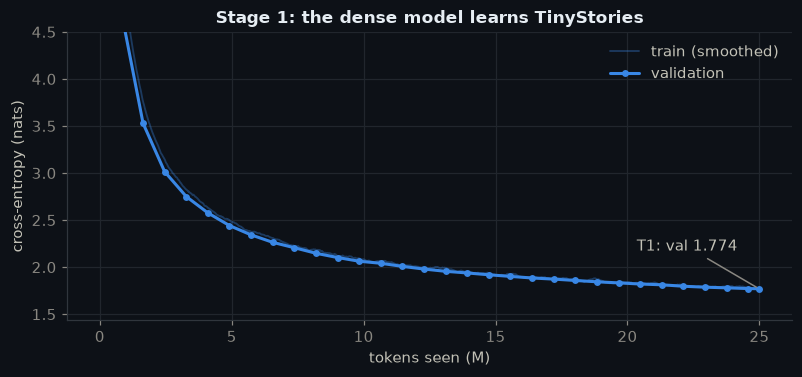

dense: 18.88M parameters, val loss at T1 = 1.7737


In [22]:
def smooth(v, k=25):
    """Trailing mean over k steps; the first k-1 points average whatever is available."""
    v = np.asarray(v, float)
    c = np.cumsum(np.insert(v, 0, 0.0))
    n = np.minimum(np.arange(1, len(v) + 1), k)
    return (c[1:] - c[np.arange(1, len(v) + 1) - n]) / n

def tokens_axis(log, steps):
    return (log["tokens0"] + np.asarray(steps) * log["batch"] * GCFG.ctx) / 1e6

if have("runs", "dense"):
    L = R["runs"]["dense"]
    fig, ax = plt.subplots(figsize=(8.5, 3.4))
    ax.plot(tokens_axis(L, np.arange(1, len(L["loss"]) + 1)), smooth(L["loss"]), color=DENSE_C, alpha=0.35, lw=1.2, label="train (smoothed)")
    ax.plot(tokens_axis(L, L["eval_step"]), L["val"], color=DENSE_C, marker="o", ms=3.5, label="validation")
    ax.set(xlabel="tokens seen (M)", ylabel="cross-entropy (nats)", title="Stage 1: the dense model learns TinyStories")
    ax.set_ylim(top=min(4.5, max(L["val"]) + 0.2))
    ax.legend()
    ax.annotate(f"T1: val {L['val'][-1]:.3f}", (tokens_axis(L, [L['eval_step'][-1]])[0], L["val"][-1]),
                xytext=(-80, 25), textcoords="offset points", color=INK2, arrowprops=dict(arrowstyle="-", color=MUTED))
    savefig(fig, "stage1_dense")
    print(f"dense: {L['params'] / 1e6:.2f}M parameters, val loss at T1 = {R['val_T1']:.4f}")

**Carry this forward:** the dense model is the starting point, not a baseline to beat. It is
converted while its loss is still falling fast, because upcycling pays off only when the dense
model still has a lot left to learn.

---
## F · Conversion surgery: turning the dense block into experts

> Growing an MoE from a dense model, and three ways to seed the shared expert (crop, random, half
> fresh).

A SwiGLU block is a **sum over its neurons**. Neuron *j* computes
`w_down[:, j] · silu(w_gate[j] · x) · (w_up[j] · x)`, and the block's output is the sum of all *F*
of these. Any partition of the neurons into groups gives "experts" whose outputs **add back up to the
dense block exactly**. Everything in this section follows from that one fact.

```
dense SwiGLU, F = 1536 neurons          our Stage 2 (partition)
w_gate [1536, 384] ─┐                    shared expert  : 768 neurons, copied exactly   [768, 384]
w_up   [1536, 384] ─┼─ permute ───────►  2 shuffled copies of the other 768,
w_down [384, 1536] ─┘                     each cut into 4 slices of 192 -> 8 experts  [8, 192, 384]
                                         router (new) [8, 384]  ·  top-4  ·  route_scale = 4
active width = 768 shared + 4 x 192 routed = 1536 = the dense block
```

| method | experts start as | k | route_scale | what is preserved at conversion |
|---|---|---|---|---|
| **copy** (sparse upcycling, 2022) | 8 full copies of the dense block | 2 | 1 (average copies) | **exactly** the dense output, for any router |
| **drop** r=0.5 (drop-upcycling, 2025) | 8 copies, each with half its neurons redrawn | 2 | 1 | about half the signal |
| **partition** (Qwen2 / Lightning LM, our Stage 2) | shared half + slices of 2 shuffled copies of the rest | 4 | 4 (sum pieces) | **the expected value**: each routed neuron is chosen once per token on average |
| **random** | fresh random experts, attention and embeddings kept | 4 | 4 | nothing in the feed-forward block |

**The optimizer state follows the neurons.** Adam keeps two running moments per weight. When a
neuron is copied into an expert, its two moments are copied with it, by the exact same index
operation. Redrawn neurons get zero moments, and the new router starts with no state.
Throwing all of this away and resetting is the common shortcut; carrying it over is part of doing
the conversion properly.

🧠 **Intuition.** A dense feed-forward block is a choir of 1,536 singers, and its output is
everyone singing together.

* **Copy** hires 8 identical choirs and lets the router pick 2. Any pick sounds exactly like the
  original choir, but the choirs start identical and must learn to differ.
* **Partition** splits the singers into small groups and lets each token call a few groups. On
  average every singer is heard once, but for one particular token some singers are heard twice and
  some not at all. That per-token unevenness is the loss jump at conversion.
* **Drop** sends half of each group home and hires random newcomers, so half the song is lost at
  first.

<details><summary>📐 <b>The math:</b> an FFN is a sum over neurons; route scale s = E/c; why copy is exact and partition only on average</summary>

**A feed-forward block is a sum over its neurons.** With $g_j, u_j$ the $j$-th rows of gate and up,
and $W^{\text{down}}_{:,j}$ the $j$-th column of down:

$$\operatorname{FFN}(x) = \sum_{j=1}^{F} \underbrace{W^{\text{down}}_{:,j}\;\operatorname{SiLU}(g_j^\top x)\,(u_j^\top x)}_{\text{neuron } j}.$$

Any grouping of neurons into experts therefore adds back up to the dense block exactly, if every
group is used once.

**Where the route scale comes from.**

* Suppose every dense neuron is placed in $c$ of the $E$ experts, and a token picks $k$ experts.
* Right after conversion the router is near-uniform, so each chosen expert gets weight
  $\approx s/k$, and a given expert is chosen with probability $k/E$.
* Let $M_j$ be the number of chosen experts that contain neuron $j$. Neuron $j$'s coefficient in the
  output is $\tfrac{s}{k} M_j$.
* $\mathbb{E}[M_j] = c\,\tfrac{k}{E}$.

So

$$\mathbb{E}\big[\text{coefficient}_j\big] = \frac{s}{k}\cdot\frac{ck}{E} = \frac{sc}{E} = 1 \quad\Longleftrightarrow\quad s = \frac{E}{c}.$$

One formula covers both methods:

| method | $c$ | $s$ | why |
|---|---|---|---|
| **copy** | $E$ (every expert holds every neuron) | 1 | the outputs are averaged |
| **partition** (ours) | 2 | $8/2 = 4 = k$ | the outputs are summed, so the scale is $k$ |

DeepSeek-V3's "routed scaling factor 2.5" is a constant of this kind.

**Why copy is exact.** Every chosen expert contains neuron $j$, so $M_j = k$ always. The coefficient
is $\sum_{i \in \mathcal{T}} g_i = 1$ exactly, for *any* router.

**Why partition is only right on average.**

* Neuron $j$ sits in $K = 2$ specific experts out of $E = 8$, and $k = 4$ are chosen.
* So $M_j$ is hypergeometric: $M_j \sim \operatorname{Hypergeometric}(E{=}8,\, K{=}2,\, k{=}4)$.

$$P(M_j{=}0) = \frac{\binom{6}{4}}{\binom{8}{4}} = \frac{15}{70}, \qquad P(M_j{=}1) = \frac{\binom21\binom63}{\binom84} = \frac{40}{70}, \qquad P(M_j{=}2) = \frac{\binom62}{\binom84} = \frac{15}{70}$$

$$\mathbb{E}[M_j] = 1, \qquad \operatorname{Var}[M_j] = k\,\frac{K}{E}\Big(1 - \frac{K}{E}\Big)\frac{E - k}{E - 1} = \frac{3}{7} \approx 0.43.$$

Per token, each routed neuron is used 0, 1 or 2 times: right on average, noisy for any one token.
That noise is the partition jump in the table below.

**Drop.** Redrawing a fraction $r$ of each expert's neurons keeps an expected $1 - r$ of the signal
($r = 0.5$ here), and the random neurons add noise. That is why it jumps the most.

**The optimizer state follows the neurons.** Adam's moments update element by element:

$$m \leftarrow \beta_1 m + (1 - \beta_1)\,g, \qquad v \leftarrow \beta_2 v + (1 - \beta_2)\,g^2.$$

Moving neurons is an index map $\pi$, and element-wise updates commute with it. So $(\pi(m), \pi(v))$
are exactly the moments that neuron had: its next update is the one it would have had for the same
gradient.

The bias correction $\hat m = m / (1 - \beta_1^t)$ is about $m$ at $t \approx 1500$. Zeroed moments on
redrawn neurons give them a gentle warm-up: the first steps are scaled down by
$(1-\beta_1)/\sqrt{1-\beta_2} \approx 0.45$.

</details>

**See the math: how often is each dense neuron used, per token?** Simulate uniform routing with
the Stage 2 shape: 8 experts, choose 4, each neuron in 2 experts. For copy, every neuron is used
exactly once (coefficient 1); for partition the coefficient is 0, 1 or 2 with the hypergeometric
probabilities derived above.

partition: P(neuron used 0/1/2 times) sampled [0.212, 0.572, 0.217], hypergeometric [0.214, 0.571, 0.214]; mean 1.005, var 0.428 (3/7 = 0.429)


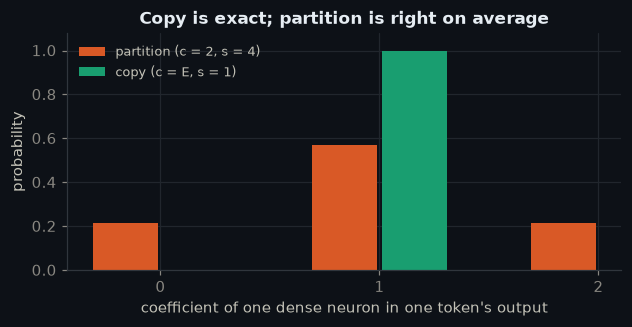

In [23]:
g_demo = torch.Generator().manual_seed(0)
picks = torch.stack([torch.randperm(8, generator=g_demo)[:4] for _ in range(20_000)])   # uniform routing, k=4 of E=8
M = ((picks == 0) | (picks == 4)).sum(1)            # neuron j lives in expert 0 (copy 0) and expert 4 (copy 1)
emp = torch.bincount(M, minlength=3).float() / len(M)
pmf = torch.tensor([15, 40, 15]) / 70
print(f"partition: P(neuron used 0/1/2 times) sampled {[round(v, 3) for v in emp.tolist()]}, "
      f"hypergeometric {[round(v, 3) for v in pmf.tolist()]}; mean {M.float().mean():.3f}, var {M.float().var():.3f} (3/7 = {3 / 7:.3f})")
assert torch.allclose(emp, pmf, atol=0.012)
fig, ax = plt.subplots(figsize=(6.5, 2.8))
ax.bar([-0.16, 0.84, 1.84], pmf, width=0.3, color=MOE_C, label="partition (c = 2, s = 4)")
ax.bar([1.16], [1.0], width=0.3, color=SERIES[2], label="copy (c = E, s = 1)")
ax.set(xticks=[0, 1, 2], xlabel="coefficient of one dense neuron in one token's output",
       ylabel="probability", title="Copy is exact; partition is right on average", ylim=(0, 1.08))
ax.legend(fontsize=8.5)
savefig(fig, "demo_partition_noise")

In [24]:
CARRY_ADAM_STATE = True

class W3:
    """A weight and its two Adam moments. Every surgery op is applied to all three identically."""
    __slots__ = ("w", "m", "v")
    def __init__(self, w, m, v):
        self.w, self.m, self.v = w, m, v
    def map(self, fn):
        return W3(fn(self.w), fn(self.m), fn(self.v))
    @staticmethod
    def stack(xs):
        return W3(torch.stack([x.w for x in xs]), torch.stack([x.m for x in xs]), torch.stack([x.v for x in xs]))


def w3_of(p, opt):
    st = opt.state.get(p, {}) if opt is not None else {}
    if CARRY_ADAM_STATE and "exp_avg" in st:
        return W3(p.detach(), st["exp_avg"], st["exp_avg_sq"])
    return W3(p.detach(), torch.zeros_like(p), torch.zeros_like(p))


class Bundle:
    """A set of feed-forward neurons: rows of gate and up, the matching columns of down."""
    def __init__(self, gate, up, down):
        self.gate, self.up, self.down = gate, up, down

    @property
    def n(self):
        return self.gate.w.shape[0]

    def take(self, idx):
        return Bundle(self.gate.map(lambda t: t[idx]), self.up.map(lambda t: t[idx]), self.down.map(lambda t: t[:, idx]))

    def clone(self):
        return Bundle(self.gate.map(torch.clone), self.up.map(torch.clone), self.down.map(torch.clone))

    def redraw(self, frac, gen, std):
        """Drop-upcycling: re-initialise a random `frac` of the neurons (weights ~ N(0, std), moments 0)."""
        b = self.clone()
        k = int(round(frac * self.n))
        idx = torch.randperm(self.n, generator=gen)[:k].to(b.gate.w.device)
        d = b.gate.w.shape[1]
        for t, s, rows in ((b.gate, std[0], True), (b.up, std[1], True), (b.down, std[2], False)):
            shape = (k, d) if rows else (d, k)
            fresh = (torch.randn(shape, generator=gen, dtype=torch.float64) * s).to(t.w)
            if rows:
                t.w[idx], t.m[idx], t.v[idx] = fresh, 0.0, 0.0
            else:
                t.w[:, idx], t.m[:, idx], t.v[:, idx] = fresh, 0.0, 0.0
        return b


def dense_bundle(block, opt):
    f = block.ffn
    return Bundle(w3_of(f.w_gate.weight, opt), w3_of(f.w_up.weight, opt), w3_of(f.w_down.weight, opt))


def expert_bundles(block, opt):
    f = block.ffn
    G, U, D = w3_of(f.gate, opt), w3_of(f.up, opt), w3_of(f.down, opt)
    return [Bundle(G.map(lambda t: t[e]), U.map(lambda t: t[e]), D.map(lambda t: t[e])) for e in range(f.E)]


def bundle_std(b):
    return (b.gate.w.std().item(), b.up.w.std().item(), b.down.w.std().item())


def adam_step(opt):
    for st in opt.state.values():
        if "step" in st:
            return st["step"]
    return None


def assemble(src, src_opt, moe_cfg, layers):
    """Build an MoE model: copy every non-FFN tensor from src, install the per-layer FFN pieces,
    and hand each new parameter the optimizer state that came with its pieces."""
    dev, dt = src.emb.weight.device, src.emb.weight.dtype
    new = GPT(src.c, moe_cfg).to(dev, dt)
    src_sd = src.state_dict()
    with torch.no_grad():
        for k, v in new.state_dict().items():
            if ".ffn." not in k and k in src_sd:
                v.copy_(src_sd[k])
    opt = make_opt(new) if src_opt is not None else None
    step = adam_step(src_opt) if src_opt is not None else None
    carried = []                                       # (param, W3) pairs that bring state along
    if opt is not None and step is not None:
        src_params = dict(src.named_parameters())
        for n, p in new.named_parameters():
            st = src_opt.state.get(src_params.get(n))
            if ".ffn." not in n and st and CARRY_ADAM_STATE:
                opt.state[p] = {k: (v.clone() if torch.is_tensor(v) else v) for k, v in st.items()}
    with torch.no_grad():
        for blk, L in zip(new.blocks, layers):
            f = blk.ffn
            if L.get("experts"):
                G = W3.stack([b.gate for b in L["experts"]]); U = W3.stack([b.up for b in L["experts"]])
                D = W3.stack([b.down for b in L["experts"]])
                for p, w3 in ((f.gate, G), (f.up, U), (f.down, D)):
                    p.copy_(w3.w); carried.append((p, w3))
            if L.get("shared") is not None:
                s = L["shared"]
                for p, w3 in ((f.shared.w_gate.weight, s.gate), (f.shared.w_up.weight, s.up), (f.shared.w_down.weight, s.down)):
                    p.copy_(w3.w); carried.append((p, w3))
            if L.get("router") is not None:
                f.router.copy_(L["router"].w); carried.append((f.router, L["router"]))
            for buf in ("bias", "offset"):
                if L.get(buf) is not None:
                    getattr(f, buf).copy_(L[buf])
    if opt is not None and step is not None and CARRY_ADAM_STATE:
        for p, w3 in carried:
            if w3.m.abs().sum() > 0 or w3.v.abs().sum() > 0:
                opt.state[p] = {"step": step.clone() if torch.is_tensor(step) else step,
                                "exp_avg": w3.m.clone().contiguous(), "exp_avg_sq": w3.v.clone().contiguous()}
    return new, opt


MAIN_MOE8 = MoEConfig(n_exp=8, width=192, top_k=4, shared=768)

def convert(src, src_opt, method, seed=0, shared_init="random", **overrides):
    """Dense -> MoE. Returns (model, optimizer, info). overrides: MoEConfig fields (score, balance, ...)."""
    gen = torch.Generator().manual_seed(seed)
    F_, layers = src.c.ffn, []
    if method in ("copy", "drop"):
        cfg = MoEConfig(n_exp=8, width=F_, top_k=2, shared=0, route_scale=1.0)
    elif method == "partition_noshared":
        cfg = MoEConfig(n_exp=16, width=F_ // 8, top_k=8, shared=0)
    else:                                              # "partition", "random"
        cfg = copy.deepcopy(MAIN_MOE8)
        cfg.width, cfg.shared = F_ // 8, F_ // 2
    for k, v in overrides.items():
        setattr(cfg, k, v)
    for blk in src.blocks:
        db = dense_bundle(blk, src_opt)
        std = bundle_std(db)
        if method == "copy":
            layers.append({"experts": [db.clone() for _ in range(cfg.n_exp)]})
        elif method == "drop":
            layers.append({"experts": [db.redraw(0.5, gen, std) for _ in range(cfg.n_exp)]})
        elif method == "random":
            layers.append({})
        else:
            perm = torch.randperm(F_, generator=gen).to(db.gate.w.device)
            if method == "partition_noshared":
                S, Rr = perm[:0], perm
            elif shared_init == "crop":
                S, Rr = torch.arange(cfg.shared, device=perm.device), torch.arange(cfg.shared, F_, device=perm.device)
            else:
                S, Rr = perm[:cfg.shared], perm[cfg.shared:]
            shared = db.take(S) if cfg.shared else None
            if shared is not None and shared_init == "half_fresh":
                shared = shared.redraw(0.5, gen, std)
            copies = cfg.n_exp * cfg.width // len(Rr)
            experts = []
            for _ in range(copies):
                Rc = Rr[torch.randperm(len(Rr), generator=gen).to(Rr.device)]
                experts += [db.take(Rc[j * cfg.width:(j + 1) * cfg.width]) for j in range(len(Rr) // cfg.width)]
            layers.append({"experts": experts, "shared": shared})
    model, opt = assemble(src, src_opt, cfg, layers)
    return model, opt, {"method": method, "cfg": asdict(cfg)}


def grow(src, src_opt, mode, m=4, seed=0, noise=0.01):
    """MoE with E experts -> MoE with E*m experts.
    mode: "copy" | "drop" (redraw half of every clone) | "staggered" (exact copies + clone offsets)
          | "split" (cut each expert into m pieces, k*m chosen: exact, but no growth in total size)."""
    gen = torch.Generator().manual_seed(seed)
    old = src.moe_layers()[0].cfg
    cfg = copy.deepcopy(old)
    if mode == "split":
        cfg.n_exp, cfg.width, cfg.top_k = old.n_exp * m, old.width // m, old.top_k * m
        cfg.route_scale = (old.route_scale or old.top_k) * m
    else:
        cfg.n_exp, cfg.family = old.n_exp * m, m
        cfg.route_scale = old.route_scale or old.top_k
    layers, deltas = [], []
    for blk in src.blocks:
        f = blk.ffn
        exps = expert_bundles(blk, src_opt)
        shared = (Bundle(w3_of(f.shared.w_gate.weight, src_opt), w3_of(f.shared.w_up.weight, src_opt),
                         w3_of(f.shared.w_down.weight, src_opt)) if f.shared is not None else None)
        R0 = w3_of(f.router, src_opt)
        tile = torch.arange(f.E, device=f.router.device).repeat_interleave(m)
        router = R0.map(lambda t: t[tile].clone())
        bias = f.bias[tile].clone()
        offset = torch.zeros_like(bias)
        if mode == "split":
            new_exps = [b.take(torch.arange(j * cfg.width, (j + 1) * cfg.width, device=b.gate.w.device))
                        for b in exps for j in range(m)]
        else:
            std = bundle_std(exps[0])
            new_exps = []
            for b in exps:
                for c in range(m):
                    new_exps.append(b.redraw(0.5, gen, std) if mode == "drop" else b.clone())
            if mode in ("copy", "drop") and noise > 0:
                rs = R0.w.std().item()
                router.w += (torch.randn(router.w.shape, generator=gen, dtype=torch.float64) * noise * rs).to(router.w)
            if mode == "staggered":
                # clone c of every family starts c*delta below clone 0: top-k picks exactly what it picked before
                delta = 1.0 + (f.bias.max() - f.bias.min()).item() + 0.01
                offset = -torch.arange(m, device=bias.device).repeat(f.E).to(bias.dtype) * delta
                deltas.append(delta)
        layers.append({"experts": new_exps, "shared": shared, "router": router, "bias": bias, "offset": offset})
    model, opt = assemble(src, src_opt, cfg, layers)
    return model, opt, {"mode": mode, "cfg": asdict(cfg), "deltas": deltas}


def staggered_schedule(model, window):
    """Offsets shrink linearly to 0 over `window` steps; the bias balancer takes over from there."""
    start = [m.offset.clone() for m in model.moe_layers()]
    def fn(s):
        frac = max(0.0, 1.0 - s / max(1, window))
        for m, o in zip(model.moe_layers(), start):
            m.offset.copy_(o * frac)
    return fn

### Gates for the surgery

The same exact-equality discipline, on a tiny fp64 model. Each line is a claim from the table
above, checked to ~1e-12.

In [25]:
torch.manual_seed(0)
_tc = GPTConfig(vocab=64, d=32, n_layer=2, n_head=4, n_kv=2, ctx=16, ffn=64)
_dense = GPT(_tc).double().eval()
_ids = torch.randint(0, 64, (3, 16))
with torch.no_grad():
    _ref = _dense(_ids)

def _logits(m):
    m.eval()
    with torch.no_grad():
        return m(_ids)

_cp, _, _ = convert(_dense, None, "copy")
gate("copy-upcycled MoE gives the dense logits (any router)", torch.allclose(_logits(_cp), _ref, atol=1e-10))

_pt, _, _ = convert(_dense, None, "partition")
with torch.no_grad():
    for _f in _pt.moe_layers():
        _f.router.zero_()                     # equal scores -> every weight = 1/k, x route_scale k = 1
        _f.k = _f.E // 2                      # choose one full copy's worth of slices...
with torch.no_grad():                         # ...and make it exactly one copy: experts 0..3 are copy 0
    for _f in _pt.moe_layers():
        _f.mask[:] = False; _f.mask[: _f.E // 2] = True
        _f.route_scale = float(_f.k)
gate("partition: shared + one full set of slices sums to the dense block", torch.allclose(_logits(_pt), _ref, atol=1e-10))

_m8, _, _ = convert(_dense, None, "partition")
with torch.no_grad():
    for _f in _m8.moe_layers():
        _f.router.normal_(0, 0.5)             # a real, uneven router
        _f.bias.normal_(0, 0.05)
_r8 = _logits(_m8)
_sp, _, _ = grow(_m8, None, "split", m=4)
gate("fine-grained split (E x4, k x4, scale x4) is exact", torch.allclose(_logits(_sp), _r8, atol=1e-10))
_st, _, _info = grow(_m8, None, "staggered", m=4)
gate("staggered-bias clone growth (E x4) is exact at step 0", torch.allclose(_logits(_st), _r8, atol=1e-10),
     f"delta per layer = {[round(x, 3) for x in _info['deltas']]}")
_cg, _, _ = grow(_m8, None, "copy", m=4, noise=0.0)
def _route_ids(m):
    m.eval()
    for f in m.moe_layers():
        f.record = True
    with torch.no_grad():
        m(_ids)
    for f in m.moe_layers():
        f.record = False
    return [f.last["topi"] for f in m.moe_layers()]
_fam = family_share(_route_ids(_cg), 4)
gate("plain clone growth is NOT exact: top-k piles into one clone family",
     not torch.allclose(_logits(_cg), _r8, atol=1e-6), f"tokens whose 4 picks share one family: {_fam:.0%}")

gate("the main recipe uses loss-free balancing and no Switch aux loss",
     MAIN_MOE8.balance == "bias" and MAIN_MOE8.switch_alpha == 0.0 and MAIN_MOE8.seq_alpha <= 1e-4)

[PASS] copy-upcycled MoE gives the dense logits (any router)
[PASS] partition: shared + one full set of slices sums to the dense block
[PASS] fine-grained split (E x4, k x4, scale x4) is exact
[PASS] staggered-bias clone growth (E x4) is exact at step 0  (delta per layer = [1.087, 1.13])
[PASS] plain clone growth is NOT exact: top-k piles into one clone family  (tokens whose 4 picks share one family: 100%)
[PASS] the main recipe uses loss-free balancing and no Switch aux loss


**Optimizer-state gate.** Convert a model that has real Adam state and check that every new
parameter either carries state of exactly its own shape or has none, and that a carried shared-expert
moment is literally the dense moment of those neurons.

In [26]:
_d2 = GPT(_tc)
_o2 = make_opt(_d2)
for _ in range(2):
    _o2.zero_grad(); _d2(_ids, _ids)[1].backward(); _o2.step()
_g = torch.Generator().manual_seed(0)
_m2, _om2, _ = convert(_d2, _o2, "partition", seed=0)
_shapes_ok = all(st["exp_avg"].shape == p.shape for p, st in _om2.state.items())
_perm = torch.randperm(_tc.ffn, generator=_g)[: _tc.ffn // 2]
_src_m = _o2.state[_d2.blocks[0].ffn.w_gate.weight]["exp_avg"][_perm]
_dst_m = _om2.state[_m2.blocks[0].ffn.shared.w_gate.weight]["exp_avg"]
gate("Adam moments travel with their neurons", _shapes_ok and torch.equal(_src_m, _dst_m),
     f"{len(_om2.state)} of {sum(1 for _ in _m2.parameters())} params carry state; the router starts fresh")
del _d2, _o2, _m2, _om2

[PASS] Adam moments travel with their neurons  (26 of 28 params carry state; the router starts fresh)


### Convert the real Stage 1 model, and measure what each method preserves

Validation loss of the T1 dense model, then of each converted model **before any MoE training**.
This is the "function preservation" each method promises, measured.

In [27]:
CONV_METHODS = [("copy", "random"), ("drop", "random"), ("partition", "random"), ("partition", "crop"),
                ("partition", "half_fresh"), ("partition_noshared", "random"), ("random", "random")]
CONV_LABEL = {("copy", "random"): "copy (8 x full, top-2)", ("drop", "random"): "drop r=0.5 (8 x full, top-2)",
              ("partition", "random"): "partition: shared = random half  [main]",
              ("partition", "crop"): "partition: shared = first half (crop)",
              ("partition", "half_fresh"): "partition: shared = half copied, half fresh",
              ("partition_noshared", "random"): "partition, no shared (16 x 192, top-8)",
              ("random", "random"): "random experts (attention kept)"}
if COMPUTE and not have("conversion"):
    rows = []
    for method, si in CONV_METHODS:
        mdl, _, info = convert(dense, None, method, seed=0, shared_init=si)
        rows.append(dict(label=CONV_LABEL[(method, si)], val=evaluate(mdl, BUDGET["val_batches"]),
                         params=n_params(mdl), active=n_active(mdl)))
        del mdl
    R["conversion"] = dict(dense_val=R["val_T1"], dense_params=n_params(dense), rows=rows)
    save_results()

if have("conversion"):
    C = R["conversion"]
    lines = ["| method | val loss right after conversion | jump | total params | active params |", "|---|---|---|---|---|",
             f"| dense model at T1 | {C['dense_val']:.4f} | - | {C['dense_params'] / 1e6:.1f}M | {C['dense_params'] / 1e6:.1f}M |"]
    for r in C["rows"]:
        lines.append(f"| {r['label']} | {r['val']:.4f} | {r['val'] - C['dense_val']:+.4f} | {r['params'] / 1e6:.1f}M | {r['active'] / 1e6:.1f}M |")
    display(Markdown("\n".join(lines)))

| method | val loss right after conversion | jump | total params | active params |
|---|---|---|---|---|
| dense model at T1 | 1.7737 | - | 18.9M | 18.9M |
| copy (8 x full, top-2) | 1.7736 | -0.0000 | 118.0M | 33.1M |
| drop r=0.5 (8 x full, top-2) | 2.2420 | +0.4683 | 118.0M | 33.1M |
| partition: shared = random half  [main] | 1.8201 | +0.0465 | 26.0M | 18.9M |
| partition: shared = first half (crop) | 1.8218 | +0.0481 | 26.0M | 18.9M |
| partition: shared = half copied, half fresh | 2.0337 | +0.2600 | 26.0M | 18.9M |
| partition, no shared (16 x 192, top-8) | 1.8909 | +0.1173 | 33.1M | 18.9M |
| random experts (attention kept) | 9.7246 | +7.9509 | 26.0M | 18.9M |

Read the table this way: *copy* costs nothing at conversion, because every expert is the dense
block and the weights average to one. Crop and random choice of the shared half are the same thing,
since a trained layer's neurons have no meaningful order. Partition keeps the signal *on average*
but not per token, and it pays for that with a jump. The random-expert model has lost its whole
feed-forward block. The labs below test whether a small jump now buys a lower loss later.

**Sample text right before and right after surgery** (same seed, same prompt):

In [28]:
PROMPTS = ["Once upon a time, there was a little", "Tom and Lily went to the park. Tom said,"]
if COMPUTE and not have("samples", "dense_T1"):
    _m8, _, _ = convert(dense, None, "partition", seed=0)
    R.setdefault("samples", {})
    R["samples"]["dense_T1"] = [generate(dense, TOK, p) for p in PROMPTS]
    R["samples"]["moe8_at_conversion"] = [generate(_m8, TOK, p) for p in PROMPTS]
    del _m8
    save_results()
for key, title in (("dense_T1", "dense model at T1"), ("moe8_at_conversion", "MoE-8, zero steps after conversion")):
    if have("samples", key):
        print(f"--- {title}")
        for s in R["samples"][key]:
            print("   ", s.replace("\n", " "))

--- dense model at T1
    Once upon a time, there was a little girl named Amy. Amy had a big, soft blanket. She loved to her blanket every day. It was a warm blanket with a bow on it. Amy would wrap it around her waist when she slept on her blanket. One
    Tom and Lily went to the park. Tom said, "I will bring you some wheat. It is very delicate. But it can make a mess." Tom and Lily ran to the farmer. They picked up the wheat and put it outside. The farmer said, "Don't worry,
--- MoE-8, zero steps after conversion
    Once upon a time, there was a little girl named Mia. Mia had a big, soft blanket that she loved very much. Every day, Mia would wrap her blanket and blanket on her blanket. One day, Mia's brother, Tim, came over to play with her.
    Tom and Lily went to the park. Tom said, "I will bring you some yogurt. It will be spicy. Do you want to play with me?" Lily nodded and said, "Yes, let's play together!" They played and joked the best games to each other. They


**Carry this forward:** a feed-forward block is a sum over neurons, so experts can be cut from it
exactly. *Copy* preserves the function but starts every expert identical. *Partition* starts the
experts different but only preserves the function on average. The optimizer state is part of the
model and is sliced with the same indices.

---
## G · Conversion lab: which starting point learns fastest?

> Sparse upcycling (copy), partition, drop-upcycling, and "is it worth starting from the dense
> model at all?"

Six short runs, all starting from the **same** T1 checkpoint (weights *and* Adam state), all reading
the **same** batches for 1.2M tokens at batch 16, with the same learning rate.

> **A lesson from the first full run.** The labs first ran at the main runs' peak learning rate
> (1.2e-3) with a batch 4× smaller. Every lab's loss *rose*, the dense one included (1.81 → 1.98),
> because gradient noise grows with lr / batch. The labs now use lr × 16/64 = 3e-4, which keeps the
> main runs' noise scale. The main stages were unaffected and were not re-run, and no prediction was
> changed.

| run | experts | active params | note |
|---|---|---|---|
| dense, continued | (none) | 18.9M | the bar every MoE must clear |
| **partition [main]** | shared 768 + 8 × 192, top-4 | 18.9M | our Stage 2 recipe |
| partition, no shared | 16 × 192, top-8 | 18.9M | the open design question "shared or none?" |
| copy | 8 × 1536, top-2 | 33.1M | exact at conversion, but twice the compute per token |
| drop r=0.5 | 8 × 1536 with half redrawn, top-2 | 33.1M | the drop-upcycling paper's best rate |
| random experts | shared 768 + 8 × 192, top-4 | 18.9M | keeps attention and embeddings, throws the FFN away |

Copy and drop do twice the feed-forward work per token, so they are *not* a fair race against the
others. They are here to show what exact preservation buys.

In [29]:
LAB_VAL = max(2, BUDGET["val_batches"] // 2)
LAB_COLORS = {"dense": SERIES[0], "partition": SERIES[1], "partition_noshared": SERIES[4], "copy": SERIES[2],
              "drop": SERIES[3], "random": SERIES[6]}
LAB_NAMES = {"dense": "dense, continued", "partition": "partition [main]", "partition_noshared": "partition, no shared",
             "copy": "copy (2x compute)", "drop": "drop r=0.5 (2x compute)", "random": "random experts"}

def lab_run(name, model, opt, cursor, gumbel_steps=0, offset_fn=None, tokens0=0.0):
    """One short branch at batch 16. val0 = validation loss before its first step."""
    v0 = round(evaluate(model, LAB_VAL), 4)
    train_run(name, model, opt, cursor, SLAB, BUDGET["lab_batch"], lr_lab, eval_every=BUDGET["lab_eval_every"],
              val_batches=LAB_VAL, gumbel_steps=gumbel_steps, offset_fn=offset_fn, tokens0=tokens0)
    R["runs"][name]["val0"] = v0
    save_results()

if COMPUTE:
    for key in ("dense", "partition", "partition_noshared", "copy", "drop", "random"):
        name = f"conv:{key}"
        if have("runs", name):
            continue
        seed_all(10)
        if key == "dense":
            mdl, opt, _ = load_ckpt("dense_T1")
        else:
            mdl, opt, _ = convert(dense, dense_opt, key, seed=0)
        lab_run(name, mdl, opt, CUR_T1)
        del mdl, opt
        torch.cuda.empty_cache()

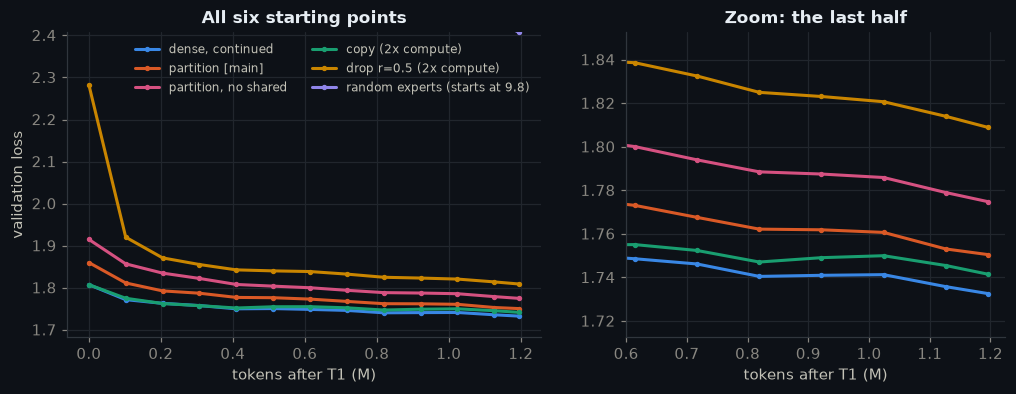

| start | val at conversion | val after lab | vs dense continued | total | active |
|---|---|---|---|---|---|
| dense, continued | 1.8075 | 1.7326 | +0.0000 | 18.9M | 18.9M |
| partition [main] | 1.8600 | 1.7505 | +0.0179 | 26.0M | 18.9M |
| partition, no shared | 1.9150 | 1.7748 | +0.0422 | 33.1M | 18.9M |
| copy (2x compute) | 1.8074 | 1.7415 | +0.0089 | 118.0M | 33.1M |
| drop r=0.5 (2x compute) | 2.2828 | 1.8089 | +0.0763 | 118.0M | 33.1M |
| random experts | 9.7803 | 2.4069 | +0.6743 | 26.0M | 18.9M |

In [30]:
def lab_curve(ax, name, label, color, ls="-"):
    L = R["runs"][name]
    x = np.concatenate([[0], np.asarray(L["eval_step"]) * L["batch"] * GCFG.ctx / 1e6])
    y = np.concatenate([[L["val0"]], L["val"]])
    ax.plot(x, y, color=color, ls=ls, label=label, marker="o", ms=2.5)
    return y

if have("runs", "conv:partition"):
    fig, (a1, a2) = plt.subplots(1, 2, figsize=(11, 3.6), gridspec_kw={"width_ratios": [1.25, 1]})
    finals = {}
    for key in ("dense", "partition", "partition_noshared", "copy", "drop", "random"):
        lab = LAB_NAMES[key] + (f" (starts at {R['runs']['conv:random']['val0']:.1f})" if key == "random" else "")
        y = lab_curve(a1, f"conv:{key}", lab, LAB_COLORS[key])
        finals[key] = y[-1]
        lab_curve(a2, f"conv:{key}", LAB_NAMES[key], LAB_COLORS[key])
    a1.set(xlabel="tokens after T1 (M)", ylabel="validation loss", title="All six starting points")
    a1.set_ylim(min(finals.values()) - 0.05, R["runs"]["conv:dense"]["val0"] + 0.6)
    a2.set(xlabel="tokens after T1 (M)", title="Zoom: the last half")
    lo = min(finals.values())
    a2.set_xlim(BUDGET["lab"] / 2e6, BUDGET["lab"] / 1e6 * 1.02)
    a2.set_ylim(lo - 0.02, lo + 0.12)
    a1.legend(fontsize=8, ncol=2)
    savefig(fig, "lab_conversion")
    rows = ["| start | val at conversion | val after lab | vs dense continued | total | active |", "|---|---|---|---|---|---|"]
    for key in ("dense", "partition", "partition_noshared", "copy", "drop", "random"):
        L = R["runs"][f"conv:{key}"]
        rows.append(f"| {LAB_NAMES[key]} | {L['val0']:.4f} | {L['val'][-1]:.4f} | {L['val'][-1] - finals['dense']:+.4f} "
                    f"| {L['params'] / 1e6:.1f}M | {L['active'] / 1e6:.1f}M |")
    display(Markdown("\n".join(rows)))

**What the submitted run showed.** After 1.2M tokens, nothing beat simply continuing the dense
model:

| run | val loss | note |
|---|---|---|
| dense, continued | 1.733 | |
| copy | 1.742 | at twice the compute |
| partition [main] | 1.751 | |
| partition, no shared | 1.775 | |
| drop | 1.809 | |
| random experts | 2.41 | |

**Carry this forward:** a conversion costs loss up front, and 1.2M tokens is not enough to repay it
(the main run gives the MoE 20M). The shared expert earned its place: 1.751 with it against 1.775
without, at the same active size and with *fewer* total parameters. The random-experts run shows
how much of a model's knowledge lives in its feed-forward blocks.

---
## H · Router lab: balancing, and the score function

> Routing collapse, the auxiliary loss, the loss-free bias, and softmax vs sigmoid: an open
> question that can only be settled by testing it.

All runs start from the same partition conversion of the T1 model (the Stage 2 shape: shared
768 + 8 × 192, top-4) and read the same batches. Only the router's rules change.

| run | score | balancing | what it tests |
|---|---|---|---|
| no balancing | sigmoid | none | does the router collapse by itself? |
| auxiliary loss | sigmoid | Switch loss, α = 0.01 | the 2021 fix: a gradient that fights the language loss |
| **loss-free bias** | sigmoid | bias, γ = 0.001, + seq loss 1e-4 | the main recipe (same run as "partition [main]" in G) |
| softmax | softmax | bias | Qwen3's score function |
| √softplus | √softplus | bias | DeepSeek-V4's score function |

**Definitions.** An expert's *load* is its share of tokens; the fair share is k/E = 4/8 = 50%.
**MaxVio** = (busiest − mean)/mean, per layer. An expert is **nearly dead** if its share over the last
20% of the run is below 10% of the fair share.

🧠 **Intuition: the favourite child.** A parent gives one child slightly
more attention. That child does a little better, so gets more attention, so does better still.
Meanwhile the others are ignored and stop improving. A router does the same: the expert it picks
gets more gradient, becomes better, and is picked more. Nothing in the language loss stops this.
Balancing is the rule that every child gets their turn.

<details><summary>📐 <b>The math:</b> collapse as positive feedback, and the two restoring forces</summary>

**A cartoon of the loop.** Let $p_i$ be expert $i$'s share of tokens, $q_i$ its quality and $r_i$ the
router's logit for it.

* Experts improve in proportion to the tokens they receive: $\dot q_i \propto p_i$.
* The language-loss gradient moves the router toward better experts: $\dot r_i \propto q_i - \bar q$.
* $p = \operatorname{softmax}(r + b)$.

Together these give the rich-get-richer equation

$$\frac{d\,p_i}{dt} \;\propto\; p_i\,\big(q_i - \bar q_p\big), \qquad \bar q_p = \sum_j p_j q_j.$$

An expert that is slightly ahead grows exponentially. The uniform state is an *unstable* fixed
point, so any small initial asymmetry ends in collapse. (This is a cartoon, not the real network.)

**Restoring force 1: the auxiliary loss.** It adds $-\alpha E\, p_i\big(f_i - \textstyle\sum_j f_j p_j\big)$ to
the logit's gradient: busy experts get pushed down. But it acts on the *same* logits that the
language loss is pushing up, so the two objectives fight. A small $\alpha$ under-corrects; a large
$\alpha$ hurts the language model.

**Restoring force 2: the bias.** $b_i \leftarrow b_i + \gamma\,\operatorname{sign}(1/E - p_i)$ acts outside the
gradient, as an integral controller. Its only fixed point is $p_i = 1/E$, and it cannot be
outvoted by the language loss, because it is not part of it.

</details>

**See the math: a 30-line collapse simulator.** Eight experts, the cartoon dynamics above, 400
steps, with no balancing, with an auxiliary loss, and with the bias. Each line is one expert's share
of tokens. This is the loop in isolation. The real lab follows.

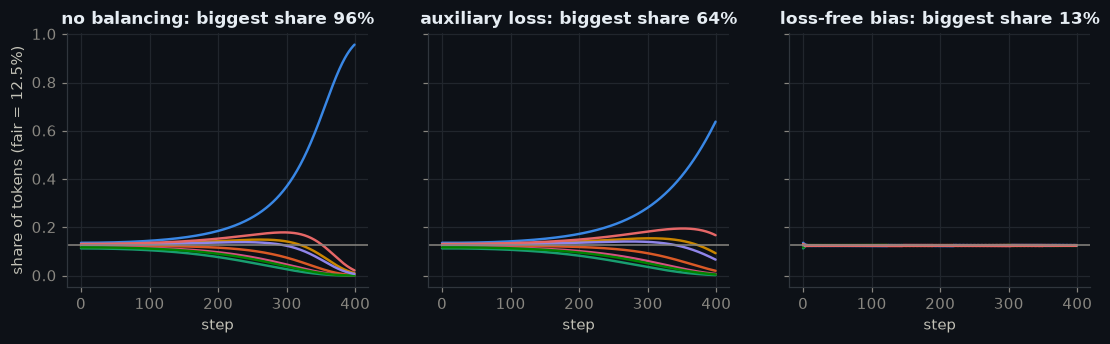

In [31]:
def collapse_sim(mode, E=8, steps=400, seed=0, lr=0.02, learn=0.05, alpha=0.5, gamma=0.02):
    g = torch.Generator().manual_seed(seed)
    r = torch.randn(E, generator=g) * 0.05          # router logits: the learned preference
    q = torch.zeros(E)                              # expert quality
    b = torch.zeros(E)                              # balancing bias (selection only)
    hist = []
    for _ in range(steps):
        p = torch.softmax(r + b, 0)                 # share of tokens each expert receives
        hist.append(p.clone())
        q += learn * p                              # experts improve with the tokens they get
        grad = q - q.mean()                         # language loss: route toward better experts
        if mode == "aux":                           # minus the gradient of alpha*E*sum f_i P_i (f = p, held fixed)
            grad = grad - alpha * E * p * (p - (p * p).sum())
        r += lr * grad
        if mode == "bias":
            b += gamma * torch.sign(1 / E - p)
    return torch.stack(hist)

fig, axes = plt.subplots(1, 3, figsize=(12, 3.0), sharey=True)
for ax, (mode, title) in zip(axes, (("none", "no balancing"), ("aux", "auxiliary loss"), ("bias", "loss-free bias"))):
    h = collapse_sim(mode)
    for i in range(h.shape[1]):
        ax.plot(h[:, i], color=SERIES[i % 8], lw=1.6)
    ax.axhline(1 / 8, color=MUTED, lw=1)
    ax.set(title=f"{title}: biggest share {h[-1].max():.0%}", xlabel="step")
axes[0].set_ylabel("share of tokens (fair = 12.5%)")
savefig(fig, "demo_collapse_sim")
_none, _bias = collapse_sim("none"), collapse_sim("bias")
assert _none[-1].max() > 0.8 and _bias[-1].max() < 0.2          # the loop collapses; the controller holds

In [32]:
def tail_shares(log, frac=0.2):
    loads = np.asarray(log["load"], dtype=float)                 # [evals, layers, E]
    n = max(1, int(round(len(loads) * frac)))
    return loads[-n:].mean(0)                                    # [layers, E], sums to k per layer

def nearly_dead(log, k, frac=0.2):
    sh = tail_shares(log, frac)
    return (sh < 0.1 * k / sh.shape[1]).sum(1)                   # per layer

def tail_maxvio(log, frac=0.2):
    mv = np.asarray(log["maxvio"], dtype=float)
    n = max(1, int(round(len(mv) * frac)))
    return float(mv[-n:].mean())

ROUTER_RUNS = {"none": dict(balance="none", seq_alpha=0.0), "aux": dict(balance="none", seq_alpha=0.0, switch_alpha=0.01),
               "softmax": dict(score="softmax"), "sqrt_softplus": dict(score="sqrt_softplus")}
if COMPUTE:
    for key, ov in ROUTER_RUNS.items():
        name = f"router:{key}"
        if have("runs", name):
            continue
        seed_all(10)
        mdl, opt, _ = convert(dense, dense_opt, "partition", seed=0, **ov)
        lab_run(name, mdl, opt, CUR_T1)
        del mdl, opt
        torch.cuda.empty_cache()

def router_log(key):
    return R["runs"]["conv:partition" if key in ("bias", "sigmoid") else f"router:{key}"]

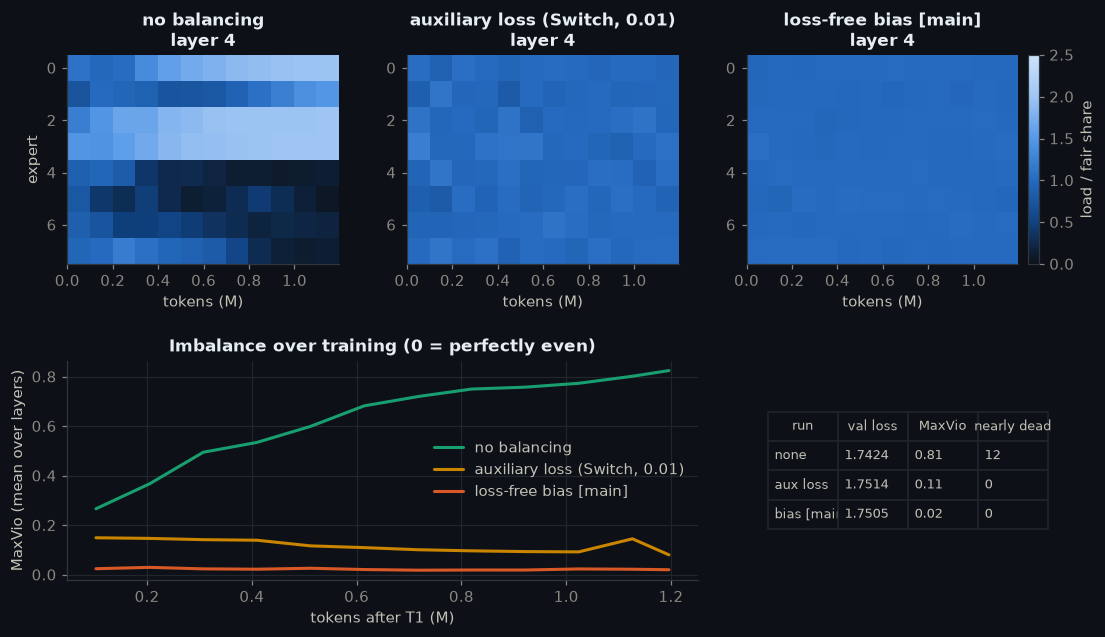

In [33]:
BAL = [("none", "no balancing", SERIES[2]), ("aux", "auxiliary loss (Switch, 0.01)", SERIES[3]), ("bias", "loss-free bias [main]", SERIES[1])]
if have("runs", "router:none") and have("runs", "conv:partition"):
    none_mv = np.asarray(router_log("none")["maxvio"])[-1]
    L_SHOW = int(np.argmax(none_mv))
    fig = plt.figure(figsize=(11.5, 6.2))
    gs = fig.add_gridspec(2, 3, height_ratios=[1, 1.05], hspace=0.45, wspace=0.25)
    for i, (key, label, _) in enumerate(BAL):
        L = router_log(key)
        ld = np.asarray(L["load"])[:, L_SHOW, :]                     # [evals, E]
        ax = fig.add_subplot(gs[0, i])
        k = MAIN_MOE8.top_k
        im = ax.imshow(ld.T / (k / ld.shape[1]), aspect="auto", cmap=SEQ, vmin=0, vmax=2.5, interpolation="nearest",
                       extent=[0, L["eval_step"][-1] * L["batch"] * GCFG.ctx / 1e6, ld.shape[1] - 0.5, -0.5])
        ax.set(title=f"{label}\nlayer {L_SHOW + 1}", xlabel="tokens (M)", ylabel="expert" if i == 0 else None)
        ax.grid(False)
    cb = fig.colorbar(im, ax=fig.axes[:3], fraction=0.02, pad=0.01)
    cb.set_label("load / fair share", color=INK2)
    a = fig.add_subplot(gs[1, :2])
    for key, label, color in BAL:
        L = router_log(key)
        a.plot(np.asarray(L["eval_step"]) * L["batch"] * GCFG.ctx / 1e6, np.asarray(L["maxvio"]).mean(1), color=color, label=label)
    a.set(xlabel="tokens after T1 (M)", ylabel="MaxVio (mean over layers)", title="Imbalance over training (0 = perfectly even)")
    a.legend()
    t = fig.add_subplot(gs[1, 2]); t.axis("off")
    short = {"none": "none", "aux": "aux loss", "bias": "bias [main]"}
    cells = [[short[key], f"{router_log(key)['val'][-1]:.4f}", f"{tail_maxvio(router_log(key)):.2f}",
              str(int(nearly_dead(router_log(key), 4).sum()))] for key, label, _ in BAL]
    tb = t.table(cellText=cells, colLabels=["run", "val loss", "MaxVio", "nearly dead"], loc="center", cellLoc="left")
    tb.auto_set_font_size(False); tb.set_fontsize(8.5); tb.scale(1, 1.6)
    for c in tb.get_celld().values():
        c.set_facecolor(SURFACE); c.set_edgecolor(GRID); c.get_text().set_color(INK2)
    savefig(fig, "lab_balancing")
    R["router_lab"] = {key: dict(val=router_log(key)["val"][-1], maxvio=tail_maxvio(router_log(key)),
                                 dead=nearly_dead(router_log(key), 4).tolist()) for key in ("none", "aux", "bias", "softmax", "sqrt_softplus")}
    save_results()

How to read it: each heatmap row is one expert, and colour is its share of tokens relative to fair
(1.0 = exactly fair, dark = starved, bright = overloaded). Without balancing the router's early
favourites keep winning, because the experts it picks get more gradient and get better, so it picks
them more. The auxiliary loss pushes back, but through the same router gradient the language
loss uses. The bias pushes back without touching the gradient at all.

In the submitted run, **no balancing reached the lowest loss** (1.742 against 1.751 for the bias)
while starving 12 experts. A loss that drops fastest right now is not the goal; the eventual loss is. The starved experts are capacity that was paid for and will never be used, and
the imbalance would turn into stragglers once experts are spread across GPUs (Part M). The auxiliary
loss held MaxVio near 0.1, and the bias held it near 0.02.

### Score function: softmax, sigmoid or √softplus

Same conversion, same loss-free bias, only the function that turns router logits into scores
changes.

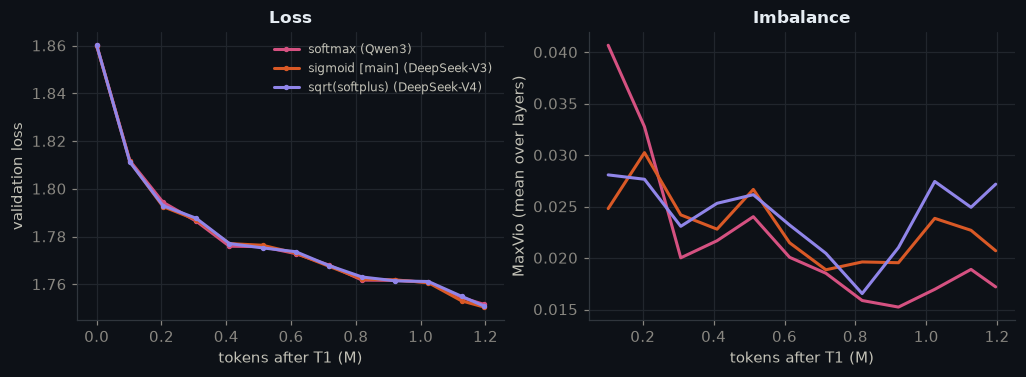

| score | val loss | MaxVio (last 20%) |
|---|---|---|
| softmax (Qwen3) | 1.7516 | 0.018 |
| sigmoid [main] (DeepSeek-V3) | 1.7505 | 0.022 |
| sqrt(softplus) (DeepSeek-V4) | 1.7509 | 0.026 |

In [34]:
SCORES = [("softmax", "softmax (Qwen3)", SERIES[4]), ("sigmoid", "sigmoid [main] (DeepSeek-V3)", SERIES[1]),
          ("sqrt_softplus", "sqrt(softplus) (DeepSeek-V4)", SERIES[6])]
if have("runs", "router:softmax") and have("runs", "router:sqrt_softplus"):
    fig, (a1, a2) = plt.subplots(1, 2, figsize=(11, 3.4))
    for key, label, color in SCORES:
        L = router_log(key)
        x = np.asarray(L["eval_step"]) * L["batch"] * GCFG.ctx / 1e6
        a1.plot(np.concatenate([[0], x]), np.concatenate([[L["val0"]], L["val"]]), color=color, label=label, marker="o", ms=2.5)
        a2.plot(x, np.asarray(L["maxvio"]).mean(1), color=color, label=label)
    a1.set(xlabel="tokens after T1 (M)", ylabel="validation loss", title="Loss")
    a2.set(xlabel="tokens after T1 (M)", ylabel="MaxVio (mean over layers)", title="Imbalance")
    a1.legend(fontsize=8)
    savefig(fig, "lab_score_function")
    display(Markdown("| score | val loss | MaxVio (last 20%) |\n|---|---|---|\n" + "\n".join(
        f"| {label} | {router_log(key)['val'][-1]:.4f} | {tail_maxvio(router_log(key)):.3f} |" for key, label, _ in SCORES)))

**Carry this forward:** a router left alone feeds its favourites. The bias fixes the load without
adding a second objective to the gradient, which is why it replaced the auxiliary loss. The score
function changes how strongly the router's preference reaches the weights. At this scale it made
no measurable difference: all three land within 0.001 nats, and softmax balanced slightly *better*
than sigmoid (P8 missed).

---
## I · Stage 2: the main run (dense → MoE-8) and the dense control

From the T1 checkpoint, two branches run on **identical batches** with an **identical learning-rate
curve**:

* **MoE path.** Partition-convert (shared 768 + 8 × 192, top-4, sigmoid, loss-free bias), carry the
  Adam state, and train 8M tokens to T2. Stage 3 then continues it to T3.
* **Dense control.** The same dense model and optimizer state, trained on the same 20M tokens to T3.

The routing of a fixed probe batch is snapshotted at 0, 1, 2, 5, 10, 25, 50 and 100% of each MoE
stage, so Part L can measure how quickly routing settles.

In [35]:
def snap_steps(n):
    return sorted({int(round(f * n)) for f in (0, 0.01, 0.02, 0.05, 0.1, 0.25, 0.5, 1.0)})

T1_TOK, T2_TOK = S1 * TOK_STEP, (S1 + S2) * TOK_STEP
moe8 = moe8_opt = None
CUR_T2 = CUR_T1 + S2 * BUDGET["batch"]
if COMPUTE:
    R.setdefault("points", {})
    R["points"]["dense_T1"] = R["val_T1"]
    if has_ckpt("moe8_T2") and have("runs", "moe8"):
        moe8, moe8_opt, CUR_T2 = load_ckpt("moe8_T2")
        print("loaded Stage 2 checkpoint")
    else:
        seed_all(2)
        moe8, moe8_opt, _ = convert(dense, dense_opt, "partition", seed=0)
        R["points"]["moe8_T1"] = evaluate(moe8, BUDGET["val_batches"])
        print(f"MoE-8: {n_params(moe8) / 1e6:.2f}M total, {n_active(moe8) / 1e6:.2f}M active; "
              f"val right after conversion {R['points']['moe8_T1']:.4f} (dense {R['val_T1']:.4f})")
        CUR_T2, _ = train_run("moe8", moe8, moe8_opt, CUR_T1, S2, BUDGET["batch"], lr_post, s0=0, gamma_fn=gamma_post,
                              eval_every=BUDGET["eval_every"], val_batches=BUDGET["val_batches"],
                              snap_at=snap_steps(S2), tokens0=T1_TOK)
        save_ckpt("moe8_T2", moe8, moe8_opt, CUR_T2)
    R["points"]["moe8_T2"] = evaluate(moe8, BUDGET["val_batches"])
    R.setdefault("samples", {})["moe8_T2"] = [generate(moe8, TOK, p) for p in PROMPTS]
    save_results()

loaded Stage 2 checkpoint


In [36]:
control = control_opt = None
if COMPUTE:
    if has_ckpt("control_T3") and have("runs", "control_b"):
        control, control_opt, _ = load_ckpt("control_T3")
        print("loaded dense-control checkpoint")
    else:
        control, control_opt, cur = load_ckpt("dense_T1")          # a fresh copy of the T1 model + Adam state
        assert cur == CUR_T1
        cur, _ = train_run("control_a", control, control_opt, cur, S2, BUDGET["batch"], lr_post, s0=0,
                           eval_every=BUDGET["eval_every"], val_batches=BUDGET["val_batches"], tokens0=T1_TOK)
        R["points"]["control_T2"] = evaluate(control, BUDGET["val_batches"])
        cur, _ = train_run("control_b", control, control_opt, cur, S3, BUDGET["batch"], lr_post, s0=S2,
                           eval_every=BUDGET["eval_every"], val_batches=BUDGET["val_batches"], tokens0=T2_TOK)
        save_ckpt("control_T3", control, control_opt, cur)
    R["points"]["control_T3"] = evaluate(control, BUDGET["val_batches"])
    R["samples"]["control_T3"] = [generate(control, TOK, p) for p in PROMPTS]
    save_results()

loaded dense-control checkpoint


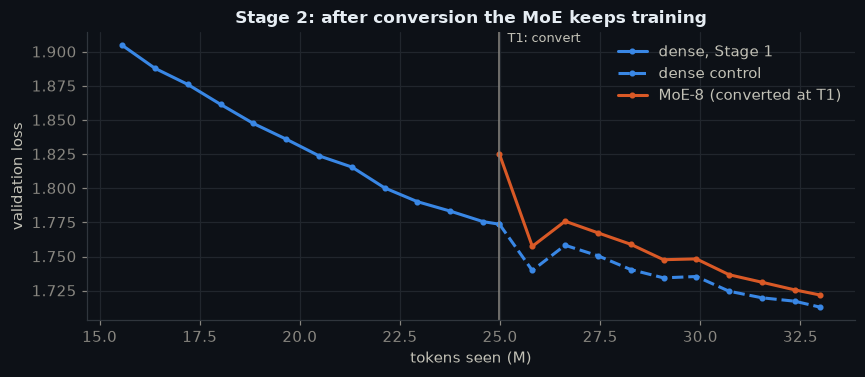

dense at T1 1.7737 -> MoE-8 right after conversion 1.8250 -> MoE-8 at T2 1.7219   |   dense control at T2 1.7130


In [37]:
if have("runs", "moe8") and have("runs", "control_a"):
    M, Cn, D = R["runs"]["moe8"], R["runs"]["control_a"], R["runs"]["dense"]
    fig, ax = plt.subplots(figsize=(9, 3.4))
    xd = tokens_axis(D, D["eval_step"])
    keep = xd > T1_TOK / 1e6 * 0.6
    ax.plot(xd[keep], np.asarray(D["val"])[keep], color=DENSE_C, marker="o", ms=3, label="dense, Stage 1")
    ax.plot(np.concatenate([[T1_TOK / 1e6], tokens_axis(Cn, Cn["eval_step"])]), np.concatenate([[R["points"]["dense_T1"]], Cn["val"]]),
            color=DENSE_C, ls="--", marker="o", ms=3, label="dense control")
    ax.plot(np.concatenate([[T1_TOK / 1e6], tokens_axis(M, M["eval_step"])]), np.concatenate([[R["points"]["moe8_T1"]], M["val"]]),
            color=MOE_C, marker="o", ms=3, label="MoE-8 (converted at T1)")
    ax.axvline(T1_TOK / 1e6, color=MUTED, lw=1)
    ax.text(T1_TOK / 1e6, ax.get_ylim()[1], "  T1: convert", color=INK2, va="top", fontsize=8.5)
    ax.set(xlabel="tokens seen (M)", ylabel="validation loss", title="Stage 2: after conversion the MoE keeps training")
    ax.legend()
    savefig(fig, "stage2")
    p = R["points"]
    print(f"dense at T1 {p['dense_T1']:.4f} -> MoE-8 right after conversion {p['moe8_T1']:.4f} -> MoE-8 at T2 {p['moe8_T2']:.4f}"
          f"   |   dense control at T2 {p.get('control_T2', float('nan')):.4f}")

**Carry this forward:** conversion is a step inside one training run, not a restart. The batches,
the learning-rate curve and the optimizer state all continue across it.

---
## J · Growing 8 → 32 experts, and the clone-family trap

> Lightning LM grew 20 → 460 experts by cloning, and its first attempt collapsed
> "along clone families". This part reproduces that failure on purpose and then avoids it.

Growing means every expert becomes a **family** of 4 clones and the router rows are tiled, so
the 4 clones of a family get (almost) the same score. With hard top-4, a token's four highest scores
are then usually **all four clones of its single best family**. Before growth the token used four
*different* experts; after growth it uses one expert four times. The output changes, and the router
has no way to tell the clones apart.

| variant | clones start as | selection right after growth |
|---|---|---|
| copy + hard top-k | exact copies, router noise 1% | piles into one family |
| drop + hard top-k | half of each clone's neurons redrawn | piles into one family |
| **drop + Gumbel top-k [main]** | half redrawn; sampled selection for the first 15% of the window | spread by sampling |
| staggered-bias copy *(an untested idea of ours)* | exact copies, clone *c* starts with selection offset −c·Δ | **exactly as before growth** (gated in F) |

The staggered variant uses the balancing machinery itself. At step 0 only clone 0 of each family
can win, so routing is unchanged. The offset then shrinks linearly to zero over the window, and the
loss-free bias balancer hands tokens over to the idle clones gradually.

🧠 **Intuition.** Clone a teacher into four identical twins and seat them side by side. Every
student who wanted that teacher now sees four equally good options, and with "take the top four"
picks all four twins instead of four different teachers. The fixes:

* **Gumbel:** draw lots among near-equals, so the twins *and* the other teachers get some
  students.
* **Staggering:** introduce the twins one at a time.

<details><summary>📐 <b>The math:</b> why clones tie, the Gumbel-max trick, and the staggered-offset guarantee</summary>

**Tied clones.** Tiling the router gives clone $c$ of family $f$ the logit $z_{f,c} = z_f + \varepsilon_{f,c}$,
with tiny noise $\varepsilon$.

Let $f^\star$ be the token's best family and $f'$ the runner-up. If $z_{f^\star} - z_{f'} > 2\max\lvert\varepsilon\rvert$,
then all $m$ clones of $f^\star$ outrank every clone of every other family. With $m = k = 4$ the
chosen set is exactly family $f^\star$: one expert, used four times.

That holds for almost every token, because $\varepsilon$ is tiny. Measured: 97.8% of tokens at the
start of Stage 3 (P5).

**The Gumbel-max trick.** With $G_i$ i.i.d. standard Gumbel noise, $G_i = -\log(-\log U_i)$ and
$U_i \sim \mathrm{Uniform}(0,1)$:

$$P\Big(\arg\max_i\,(z_i + G_i) = j\Big) = \frac{e^{z_j}}{\sum_i e^{z_i}},$$

and the top-$k$ of $z + G$ is a sample of $k$ experts without replacement in proportion to $e^{z}$
(the Plackett–Luce model).

* Tied clones get *equal* chances.
* Other families get their softmax share.
* So during the window every clone receives some gradient and the twins can start to differ.

We apply it to per-token standardised scores, $(\sigma + b - \text{mean})/\text{std}$, so it is
scale-free.

**The staggered guarantee.** Clone $c$ starts with selection offset $-c\Delta$. With scores in
$(0,1)$, the selection value of clone $c$ of family $f$ is $v_{f,c} = \sigma_f + b_f - c\Delta$.

For any $c \ge 1$ and any families $f, f'$:

$$v_{f,c} \;\le\; \sigma_f + b_f - \Delta \;<\; 1 + b_{\max} - \Delta \;\le\; b_{\min} \;<\; \sigma_{f'} + b_{f'} = v_{f',0}, \qquad \text{whenever } \Delta \ge 1 + (b_{\max} - b_{\min}).$$

Every clone 0 outranks every other clone, so the top-$k$ is exactly the clone-0s of the old top-$k$
families. With identical weights, that is an identical output. The gate in Part F checks it.

The catch, measured below: clones 1–3 receive no tokens until the offset is gone. When it
vanishes they are still identical to clone 0, and the tie returns.

</details>

**See the math: four tied clones.** Two families of four identical clones each. Family A's logit
is 1.0 and family B's is 0.8, plus noise of 0.001, with k = 4. Hard top-k always takes all of family
A. Gumbel top-k spreads picks over every clone, in proportion to $e^{z}$.

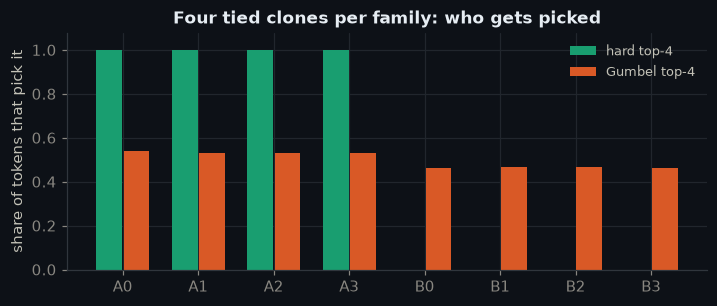

hard top-4 picks family A only: [1.0, 1.0, 1.0, 1.0, 0.0, 0.0, 0.0, 0.0] | Gumbel: [0.54, 0.53, 0.53, 0.53, 0.46, 0.47, 0.47, 0.46]


In [38]:
g_demo = torch.Generator().manual_seed(1)
zc = torch.tensor([1.0] * 4 + [0.8] * 4) + 0.001 * torch.randn(8, generator=g_demo)
hard = torch.zeros(8)
hard[zc.topk(4).indices] = 1.0
U = torch.rand(20_000, 8, generator=g_demo).clamp(1e-9, 1 - 1e-9)
noisy = zc - torch.log(-torch.log(U))
gum = torch.zeros(8).index_add_(0, noisy.topk(4, dim=1).indices.flatten(), torch.ones(80_000)) / 20_000
first = torch.bincount(noisy.argmax(1), minlength=8) / 20_000
assert torch.allclose(first, torch.softmax(zc, 0), atol=0.01)        # Gumbel-max: argmax ~ softmax
fig, ax = plt.subplots(figsize=(7.5, 2.8))
x = np.arange(8)
ax.bar(x - 0.18, hard, width=0.34, color=SERIES[2], label="hard top-4")
ax.bar(x + 0.18, gum, width=0.34, color=MOE_C, label="Gumbel top-4")
ax.set(xticks=x, xticklabels=[f"A{c}" for c in range(4)] + [f"B{c}" for c in range(4)], ylim=(0, 1.08),
       ylabel="share of tokens that pick it", title="Four tied clones per family: who gets picked")
ax.legend(fontsize=8.5)
savefig(fig, "demo_gumbel_ties")
print("hard top-4 picks family A only:", hard.tolist(), "| Gumbel:", [round(v, 2) for v in gum.tolist()])

In [39]:
GROW_RUNS = [("copy", "copy + hard top-k", SERIES[2]), ("drop", "drop + hard top-k", SERIES[3]),
             ("gumbel", "drop + Gumbel top-k [main]", SERIES[1]), ("staggered", "staggered-bias copy", SERIES[6])]
GWIN = max(1, int(0.15 * SLAB))
if COMPUTE:
    R.setdefault("growth", {})
    for key, _, _ in GROW_RUNS:
        name = f"grow:{key}"
        if have("runs", name):
            continue
        seed_all(20)
        mdl, opt, info = grow(moe8, moe8_opt, "drop" if key == "gumbel" else key, m=4, seed=0)
        R["growth"][key] = dict(family_at_0=family_share(route_probe(mdl), 4))
        lab_run(name, mdl, opt, CUR_T2, gumbel_steps=GWIN if key == "gumbel" else 0,
                offset_fn=staggered_schedule(mdl, GWIN) if key == "staggered" else None)
        del mdl, opt
        torch.cuda.empty_cache()
    save_results()

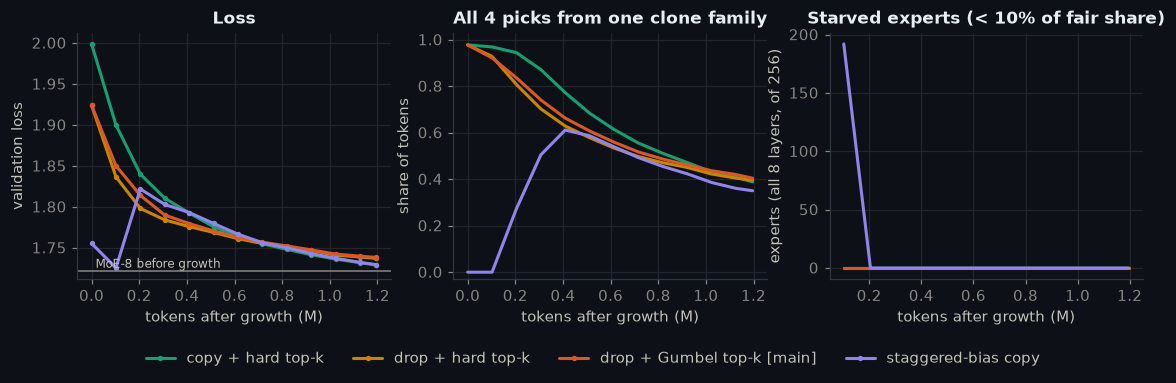

| variant | val before growth | val at step 0 | val after window | one-family share at step 0 | nearly dead at end |
|---|---|---|---|---|---|
| copy + hard top-k | 1.7219 | 1.9989 | 1.7288 | 98% | 0 |
| drop + hard top-k | 1.7219 | 1.9240 | 1.7370 | 98% | 0 |
| drop + Gumbel top-k [main] | 1.7219 | 1.9240 | 1.7382 | 98% | 0 |
| staggered-bias copy | 1.7219 | 1.7554 | 1.7294 | 0% | 0 |

In [40]:
if have("runs", "grow:staggered"):
    fig, (a1, a2, a3) = plt.subplots(1, 3, figsize=(12.5, 3.5))
    for key, label, color in GROW_RUNS:
        L = R["runs"][f"grow:{key}"]
        x = np.asarray(L["eval_step"]) * L["batch"] * GCFG.ctx / 1e6
        a1.plot(np.concatenate([[0], x]), np.concatenate([[L["val0"]], L["val"]]), color=color, marker="o", ms=2.5, label=label)
        a2.plot(np.concatenate([[0], x]), np.concatenate([[R["growth"][key]["family_at_0"]], L["family"]]), color=color, label=label)
        dead = [int((np.asarray(l) < 0.1 * 4 / 32).sum()) for l in L["load"]]
        a3.plot(x, dead, color=color, label=label)
    a1.axhline(R["points"]["moe8_T2"], color=MUTED, lw=1)
    a1.text(0, R["points"]["moe8_T2"], " MoE-8 before growth", color=INK2, va="bottom", fontsize=8)
    a1.set(xlabel="tokens after growth (M)", ylabel="validation loss", title="Loss")
    a2.set(xlabel="tokens after growth (M)", ylabel="share of tokens", title="All 4 picks from one clone family", ylim=(-0.03, 1.03))
    a3.set(xlabel="tokens after growth (M)", ylabel="experts (all 8 layers, of 256)", title="Starved experts (< 10% of fair share)")
    fig.subplots_adjust(bottom=0.24)
    fig.legend(*a1.get_legend_handles_labels(), loc="lower center", ncol=4, bbox_to_anchor=(0.5, -0.02))
    savefig(fig, "lab_growth")
    rows = ["| variant | val before growth | val at step 0 | val after window | one-family share at step 0 | nearly dead at end |", "|---|---|---|---|---|---|"]
    for key, label, _ in GROW_RUNS:
        L = R["runs"][f"grow:{key}"]
        rows.append(f"| {label} | {R['points']['moe8_T2']:.4f} | {L['val0']:.4f} | {L['val'][-1]:.4f} | "
                    f"{R['growth'][key]['family_at_0']:.0%} | {int(nearly_dead(L, 4).sum())} |")
    display(Markdown("\n".join(rows)))

**What the submitted run showed.** All four variants ended within 0.01 nats of each other:

| variant | val loss | note |
|---|---|---|
| copy + hard | 1.729 | |
| staggered | 1.729 | |
| drop + hard | 1.737 | |
| drop + Gumbel | 1.738 | the registered main recipe, last |

* **The pile-up is real.** At step 0, 98% of tokens put all four picks inside one family under every
  hard-routed variant (P5). The bias balancer then spread it, to about 40% by the end of the window.
* **Redrawing half the neurons did not pay at this size.** Plain copies jumped *more* at step 0
  (4 identical clones of one piece add up to 4× that piece), but recovered best. This matches
  Amazon's Expert Upcycling result for 32 → 64 experts, where plain copying beat drop-upcycling.
  Lightning LM's drop + sampling recipe was built for a 23× clone-out (20 → 460); here the growth is
  4×.
* **Staggering removed the step-0 jump but only postponed the pile-up.** While the offsets were
  shrinking, only clone 0 of each family got tokens. Clones 1–3 were therefore still identical when
  the offsets reached zero, the families tied, and the bump arrived about 0.2M tokens later.
  Letting the balancer remove each offset only once the clones have diverged is the obvious next
  version.

### Stage 3: the main path grows to 32 experts and trains to T3

The main path uses the recipe registered before the run: **drop + Gumbel top-k**, which is
Lightning LM's fix. Total parameters go from 26M to 68.5M; active parameters stay at about 19M
(the router grows from 8 to 32 rows).

In [41]:
moe32 = moe32_opt = None
if COMPUTE:
    if has_ckpt("moe32_T3") and have("runs", "moe32"):
        moe32, moe32_opt, _ = load_ckpt("moe32_T3")
        print("loaded Stage 3 checkpoint")
    else:
        seed_all(3)
        moe32, moe32_opt, _ = grow(moe8, moe8_opt, "drop", m=4, seed=0)
        R["points"]["moe32_T2"] = evaluate(moe32, BUDGET["val_batches"])
        R["growth"]["main_family_at_0"] = family_share(route_probe(moe32), 4)
        R["samples"]["moe32_at_growth"] = [generate(moe32, TOK, p) for p in PROMPTS]
        print(f"MoE-32: {n_params(moe32) / 1e6:.2f}M total, {n_active(moe32) / 1e6:.2f}M active; val right after growth "
              f"{R['points']['moe32_T2']:.4f}; tokens with all 4 picks in one family: {R['growth']['main_family_at_0']:.0%}")
        _, _ = train_run("moe32", moe32, moe32_opt, CUR_T2, S3, BUDGET["batch"], lr_post, s0=S2, gamma_fn=gamma_post,
                         eval_every=BUDGET["eval_every"], val_batches=BUDGET["val_batches"],
                         gumbel_steps=int(0.15 * S3), snap_at=snap_steps(S3), tokens0=T2_TOK)
        save_ckpt("moe32_T3", moe32, moe32_opt, CUR_T2 + S3 * BUDGET["batch"])
    R["points"]["moe32_T3"] = evaluate(moe32, BUDGET["val_batches"])
    R["samples"]["moe32_T3"] = [generate(moe32, TOK, p) for p in PROMPTS]
    R["params"] = {"dense": n_params(dense), "moe8": n_params(moe8), "moe32": n_params(moe32),
                   "dense_active": n_active(dense), "moe8_active": n_active(moe8), "moe32_active": n_active(moe32)}
    save_results()

loaded Stage 3 checkpoint


**Carry this forward:** when you grow by cloning, the router cannot tell the clones apart, so
selection collapses onto one family per token. Either break the tie on purpose (sample the top-k
for a while) or remove it on purpose (stagger the clones and let the balancer hand tokens over).

---
## K · The result

> The goal: after converting, the model must **keep training**, and its **loss must keep falling**.

One timeline from the first token to T3: the dense model, the two conversions, and the dense
control that never converted. The zoom panels show the training loss step by step through each
conversion.

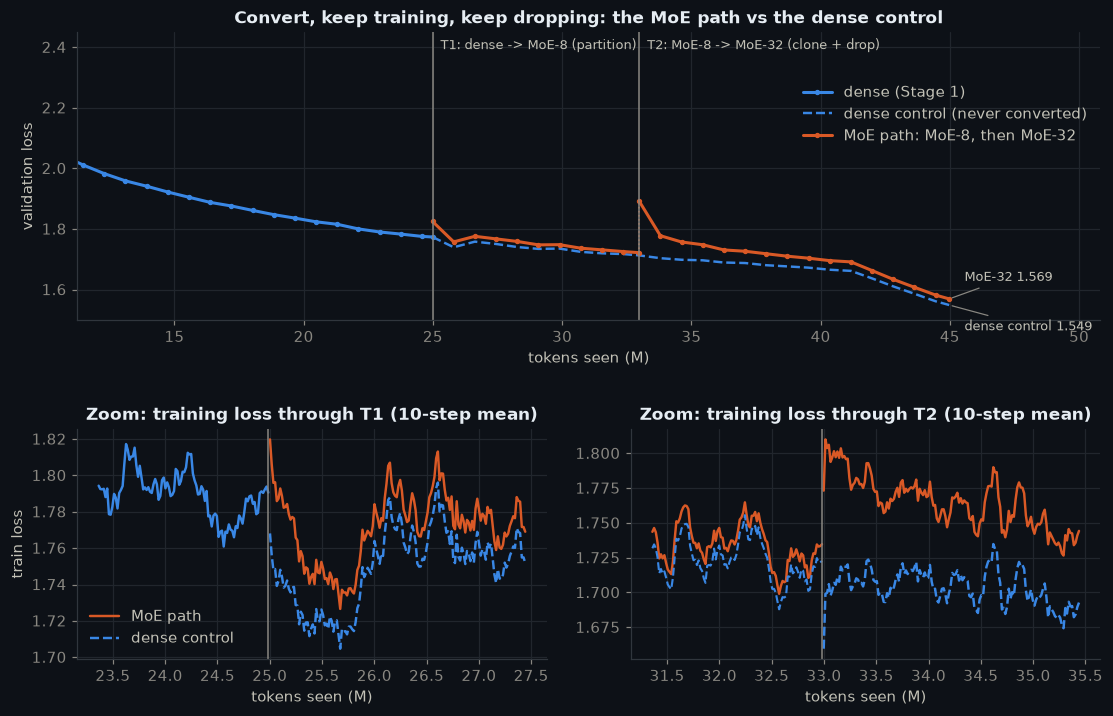

In [42]:
def cat_runs(*names):
    xs, ys = [], []
    for n in names:
        L = R["runs"][n]
        xs.append(tokens_axis(L, np.arange(1, len(L["loss"]) + 1)))
        ys.append(np.asarray(L["loss"]))
    return np.concatenate(xs), np.concatenate(ys)

def val_series(names, start=None):
    xs, ys = ([start[0]], [start[1]]) if start else ([], [])
    for n in names:
        L = R["runs"][n]
        xs += list(tokens_axis(L, L["eval_step"])); ys += list(L["val"])
    return np.asarray(xs), np.asarray(ys)

if have("runs", "moe32") and have("runs", "control_b"):
    P = R["points"]
    t1, t2 = T1_TOK / 1e6, T2_TOK / 1e6
    fig = plt.figure(figsize=(12, 7.4))
    gs = fig.add_gridspec(2, 2, height_ratios=[1.25, 1], hspace=0.42, wspace=0.18)
    ax = fig.add_subplot(gs[0, :])
    xd, yd = val_series(["dense"])
    xc, yc = val_series(["control_a", "control_b"], (t1, P["dense_T1"]))
    xm8, ym8 = val_series(["moe8"], (t1, P["moe8_T1"]))
    xm32, ym32 = val_series(["moe32"], (t2, P["moe32_T2"]))
    ax.plot(xd, yd, color=DENSE_C, marker="o", ms=2.5, label="dense (Stage 1)")
    ax.plot(xc, yc, color=DENSE_C, ls="--", lw=1.6, label="dense control (never converted)")
    ax.plot(xm8, ym8, color=MOE_C, marker="o", ms=2.5, label="MoE path: MoE-8, then MoE-32")
    ax.plot(xm32, ym32, color=MOE_C, marker="o", ms=2.5)
    ax.plot([t2, t2], [ym8[-1], ym32[0]], color=MOE_C, lw=1, ls=":")
    for t, lab in ((t1, "T1: dense -> MoE-8 (partition)"), (t2, "T2: MoE-8 -> MoE-32 (clone + drop)")):
        ax.axvline(t, color=MUTED, lw=1)
        ax.text(t, 0.98, "  " + lab, transform=ax.get_xaxis_transform(), color=INK2, va="top", fontsize=8.5)
    lo = min(yc.min(), ym32.min())
    ax.set_ylim(lo - 0.05, lo + 0.9)
    ax.set_xlim(t1 * 0.45, xm32[-1] * 1.13)
    ax.set(xlabel="tokens seen (M)", ylabel="validation loss",
           title="Convert, keep training, keep dropping: the MoE path vs the dense control")
    up, dn = (("MoE-32", xm32[-1], ym32[-1]), ("dense control", xc[-1], yc[-1]))[:: 1 if ym32[-1] >= yc[-1] else -1]
    for (lab, x_, y_), dy in ((up, 14), (dn, -14)):
        ax.annotate(f"{lab} {y_:.3f}", (x_, y_), xytext=(10, dy), textcoords="offset points", color=INK2, va="center",
                    fontsize=8.5, arrowprops=dict(arrowstyle="-", color=MUTED, lw=0.8))
    ax.legend(loc="upper right", bbox_to_anchor=(1, 0.86))
    W, B = 150, 100
    for j, (pre, post_m, post_c, t, lab) in enumerate((("dense", "moe8", "control_a", t1, "T1"), ("moe8", "moe32", "control_b", t2, "T2"))):
        a = fig.add_subplot(gs[1, j])
        Lp = R["runs"][pre]
        xp = tokens_axis(Lp, np.arange(1, len(Lp["loss"]) + 1))[-B:]
        a.plot(xp, smooth(Lp["loss"], 10)[-B:], color=MOE_C if pre == "moe8" else DENSE_C, lw=1.6)
        if pre == "moe8":
            Lc = R["runs"]["control_a"]
            a.plot(tokens_axis(Lc, np.arange(1, len(Lc["loss"]) + 1))[-B:], smooth(Lc["loss"], 10)[-B:], color=DENSE_C, ls="--", lw=1.4)
        for n, c, ls in ((post_m, MOE_C, "-"), (post_c, DENSE_C, "--")):
            L = R["runs"][n]
            w_ = min(W, len(L["loss"]))
            a.plot(tokens_axis(L, np.arange(1, w_ + 1)), smooth(L["loss"][:w_], 10), color=c, ls=ls, lw=1.6,
                   label=("MoE path" if c == MOE_C else "dense control") if j == 0 else None)
        a.axvline(t, color=MUTED, lw=1)
        a.set(title=f"Zoom: training loss through {lab} (10-step mean)", xlabel="tokens seen (M)", ylabel="train loss" if j == 0 else None)
        if j == 0:
            a.legend()
    savefig(fig, "result_timeline")

### Validation loss at every checkpoint

"Right after" means zero training steps after the surgery: it is the price paid at the moment of
conversion.

In [43]:
if have("points", "moe32_T3") and have("params"):
    P, Pa = R["points"], R["params"]
    rows = [
        ("dense, end of Stage 1", "T1", P["dense_T1"], Pa["dense"], Pa["dense_active"]),
        ("MoE-8, right after conversion", "T1", P["moe8_T1"], Pa["moe8"], Pa["moe8_active"]),
        ("MoE-8, end of Stage 2", "T2", P["moe8_T2"], Pa["moe8"], Pa["moe8_active"]),
        ("dense control", "T2", P["control_T2"], Pa["dense"], Pa["dense_active"]),
        ("MoE-32, right after growth", "T2", P["moe32_T2"], Pa["moe32"], Pa["moe32_active"]),
        ("MoE-32, end of Stage 3", "T3", P["moe32_T3"], Pa["moe32"], Pa["moe32_active"]),
        ("dense control", "T3", P["control_T3"], Pa["dense"], Pa["dense_active"]),
    ]
    tok = {"T1": T1_TOK, "T2": T2_TOK, "T3": T2_TOK + S3 * TOK_STEP}
    lines = ["| model | at | tokens | val loss | total params | active params | training FLOPs/token (6 x active) |", "|---|---|---|---|---|---|---|"]
    for name, at, v, tot, act in rows:
        lines.append(f"| {name} | {at} | {tok[at] / 1e6:.0f}M | {v:.4f} | {tot / 1e6:.1f}M | {act / 1e6:.1f}M | {6 * act / 1e6:.0f}M |")
    display(Markdown("\n".join(lines)))

| model | at | tokens | val loss | total params | active params | training FLOPs/token (6 x active) |
|---|---|---|---|---|---|---|
| dense, end of Stage 1 | T1 | 25M | 1.7737 | 18.9M | 18.9M | 113M |
| MoE-8, right after conversion | T1 | 25M | 1.8250 | 26.0M | 18.9M | 113M |
| MoE-8, end of Stage 2 | T2 | 33M | 1.7219 | 26.0M | 18.9M | 113M |
| dense control | T2 | 33M | 1.7130 | 18.9M | 18.9M | 113M |
| MoE-32, right after growth | T2 | 33M | 1.8919 | 68.5M | 19.0M | 114M |
| MoE-32, end of Stage 3 | T3 | 45M | 1.5693 | 68.5M | 19.0M | 114M |
| dense control | T3 | 45M | 1.5491 | 18.9M | 18.9M | 113M |

### Is the MoE actually better than the dense control? A paired test

Both final models are scored on the same 64 validation batches (2,048 sequences, 524K tokens). The
per-batch differences are paired, so batch difficulty cancels. A bootstrap over batches gives a 95%
interval for the mean difference. **This is one seed per model.** The interval covers validation
noise, not seed-to-seed variation.

🧠 **Intuition.**

* **Same exam.** To compare two students, give them the *same* exam and compare them question by
  question. Some questions are hard for everyone; comparing per question cancels that difficulty
  out, and what remains is the real difference between the students. Here a "question" is a
  validation batch.
* **What a nat is.** Loss in nats is $-\log$ of the probability the model gave the right next
  token. $e^{\text{loss}}$ is the **perplexity**: how many equally likely tokens the model is, in
  effect, choosing between. A gap of 0.02 nats means one model is about 2% more "perplexed" than
  the other.

<details><summary>📐 <b>The math:</b> perplexity, and the paired bootstrap</summary>

**Nats and perplexity.** The model's loss and perplexity are

$$\ell = -\frac{1}{N}\sum_{t=1}^{N} \log p_\theta(x_t \mid x_{<t}), \qquad \mathrm{PPL} = e^{\ell}, \qquad \frac{\mathrm{PPL}_A}{\mathrm{PPL}_B} = e^{\ell_A - \ell_B}.$$

At T3, $e^{1.569} = 4.80$ and $e^{1.549} = 4.71$. Their ratio is $e^{0.020} = 1.020$: the MoE is 2%
more perplexed.

**Paired differences.** For validation batch $b = 1, \dots, n$ (here $n = 64$), let
$d_b = \ell_b^{\text{MoE}} - \ell_b^{\text{dense}}$. Then

$$\bar d = \frac{1}{n}\sum_{b=1}^n d_b, \qquad \operatorname{Var}(\bar d) = \frac{\operatorname{Var}\ell^{\text{MoE}} + \operatorname{Var}\ell^{\text{dense}} - 2\operatorname{Cov}(\ell^{\text{MoE}}, \ell^{\text{dense}})}{n}.$$

Both models find the same batches hard, so the covariance is large and cancels most of the
variance. That is why a 0.02 difference can be measured precisely here.

**Bootstrap.**

1. Draw $n$ batch indices with replacement and recompute $\bar d^{\,*}$.
2. Repeat 10,000 times.
3. The 2.5th and 97.5th percentiles of $\bar d^{\,*}$ form the 95% interval.

If the interval excludes 0, the difference is larger than validation noise. It still says nothing
about seed-to-seed variation, which a second training seed would measure.

</details>

MoE-32 1.5633 vs dense control 1.5432: difference +0.0201 nats, 95% CI [+0.0191, +0.0212], MoE better on 0/64 batches


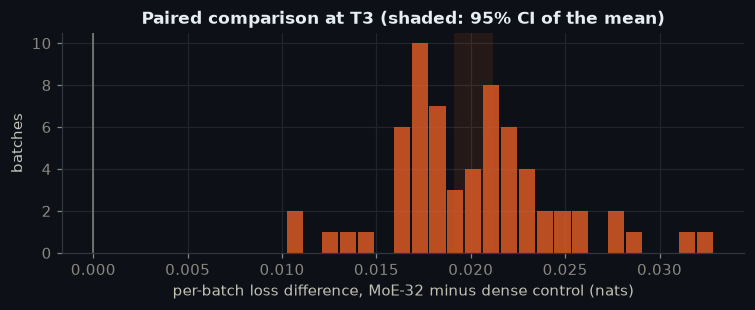

In [44]:
def paired_stats(a, b, seed=0):
    """Mean of per-batch differences a - b with a 95% bootstrap interval over batches."""
    a, b = np.asarray(a), np.asarray(b)
    d = a - b
    boots = d[np.random.default_rng(seed).integers(0, len(d), (10_000, len(d)))].mean(1)
    lo, hi = np.percentile(boots, [2.5, 97.5])
    return dict(mean=float(d.mean()), lo=float(lo), hi=float(hi), wins=int((d < 0).sum()), n=len(d),
                a=float(a.mean()), b=float(b.mean()))

if COMPUTE and moe32 is not None and not have("final_pair"):
    a = evaluate(moe32, BUDGET["final_val_batches"], per_batch=True)
    b = evaluate(control, BUDGET["final_val_batches"], per_batch=True)
    R["final_pair"] = dict(moe32=a, control=b)
    save_results()
if have("final_pair"):
    a, b = np.asarray(R["final_pair"]["moe32"]), np.asarray(R["final_pair"]["control"])
    d = a - b
    st = paired_stats(a, b)
    lo, hi = st["lo"], st["hi"]
    R["paired"] = dict(mean=st["mean"], lo=lo, hi=hi, wins=st["wins"], n=st["n"],
                       moe32=float(a.mean()), control=float(b.mean()))
    print(f"MoE-32 {a.mean():.4f} vs dense control {b.mean():.4f}: difference {d.mean():+.4f} nats, "
          f"95% CI [{lo:+.4f}, {hi:+.4f}], MoE better on {(d < 0).sum()}/{len(d)} batches")
    fig, ax = plt.subplots(figsize=(8, 2.6))
    ax.hist(d, bins=24, color=MOE_C, alpha=0.85, rwidth=0.9)
    ax.axvline(0, color=MUTED, lw=1)
    ax.axvspan(lo, hi, color=MOE_C, alpha=0.12, lw=0)
    ax.set(xlabel="per-batch loss difference, MoE-32 minus dense control (nats)", ylabel="batches",
           title="Paired comparison at T3 (shaded: 95% CI of the mean)")
    savefig(fig, "paired_T3")

### Why the MoE did not beat the dense control here

The core requirement held: after each conversion the model kept training, and its loss
fell well below where the dense model was at T1. The extra prediction, that MoE-32 would *beat* a
dense model given the same tokens and the same compute per token, **missed** in the submitted run.
MoE-32 finished about 0.02 nats behind, with a confidence interval that excludes zero. Reading the
timeline above, the gap comes from the two conversions, not from the experts learning slowly:

* **T1 cost about 0.05 nats** (partition keeps the dense output only on average). MoE-8 spent its
  8M tokens recovering, and ended Stage 2 about 0.01 behind the control.
* **T2 cost about 0.17 nats.** About 98% of tokens put all four picks inside one clone family (P5),
  and half of every clone's neurons were redrawn. Stage 3 had 12M tokens to recover and narrowed
  the gap to 0.02, but did not close it.
* Nothing here says MoE loses to dense in general. The published wins come with budgets of many
  times the dense model's tokens, and with experts much wider than 192. What this run does show is
  that **each conversion has a price in tokens**. The growth lab (Part J) points at cheaper ways to
  grow at this size: plain copies and staggered copies both ended below the drop + Gumbel recipe the
  main path used, which was registered before the run and is reported as run. **Part K.2** then
  runs both follow-ups to T3: copy growth recovers part of the gap, and not growing at all recovers
  most of it.

### What the models write

Same prompts, same sampling seed (temperature 0.8, top-40). The text is a qualitative check that
surgery did not break the model, not a measurement.

In [45]:
SAMPLE_ORDER = [("dense_T1", "dense at T1"), ("moe8_at_conversion", "MoE-8, 0 steps after conversion"), ("moe8_T2", "MoE-8 at T2"),
                ("moe32_at_growth", "MoE-32, 0 steps after growth"), ("moe32_T3", "MoE-32 at T3"), ("control_T3", "dense control at T3")]
for key, title in SAMPLE_ORDER:
    if have("samples", key):
        print(f"--- {title}")
        for s_ in R["samples"][key]:
            print("    " + s_.replace("\n", " "))

--- dense at T1
    Once upon a time, there was a little girl named Amy. Amy had a big, soft blanket. She loved to her blanket every day. It was a warm blanket with a bow on it. Amy would wrap it around her waist when she slept on her blanket. One
    Tom and Lily went to the park. Tom said, "I will bring you some wheat. It is very delicate. But it can make a mess." Tom and Lily ran to the farmer. They picked up the wheat and put it outside. The farmer said, "Don't worry,
--- MoE-8, 0 steps after conversion
    Once upon a time, there was a little girl named Mia. Mia had a big, soft blanket that she loved very much. Every day, Mia would wrap her blanket and blanket on her blanket. One day, Mia's brother, Tim, came over to play with her.
    Tom and Lily went to the park. Tom said, "I will bring you some yogurt. It will be spicy. Do you want to play with me?" Lily nodded and said, "Yes, let's play together!" They played and joked the best games to each other. They
--- MoE-8 at T2
    On

### Checklist

In [46]:
if have("points", "moe32_T3") and have("params"):
    P, Pa, D = R["points"], R["params"], R["runs"]["dense"]
    peak = max((R["runs"][n].get("peak_gib") or 0) for n in ("dense", "moe8", "moe32", "control_a", "control_b"))
    checks = [
        ("Trained a dense ('linear') model", D["val"][-1] < D["val"][0], f"val {D['val'][0]:.2f} -> {D['val'][-1]:.3f} over {S1 * TOK_STEP / 1e6:.0f}M tokens"),
        ("Converted it into an MoE (and grew that MoE)", Pa["moe32"] > Pa["dense"], f"{Pa['dense'] / 1e6:.1f}M -> {Pa['moe8'] / 1e6:.1f}M -> {Pa['moe32'] / 1e6:.1f}M total"),
        ("It continued to train after conversion", P["moe8_T2"] < P["moe8_T1"] and P["moe32_T3"] < P["moe32_T2"],
         f"MoE-8 {P['moe8_T1']:.3f} -> {P['moe8_T2']:.3f}; MoE-32 {P['moe32_T2']:.3f} -> {P['moe32_T3']:.3f}"),
        ("The loss dropped below where the dense model was", P["moe32_T3"] < P["dense_T1"], f"{P['dense_T1']:.3f} at T1 -> {P['moe32_T3']:.3f} at T3"),
        ("Bigger model at the same compute per token", Pa["moe32"] > 3 * Pa["dense"] and abs(Pa["moe32_active"] / Pa["dense_active"] - 1) < 0.01,
         f"{Pa['moe32'] / Pa['dense']:.1f}x the parameters, {Pa['moe32_active'] / Pa['dense_active']:.3f}x the active parameters"),
        ("Fits a laptop / Colab GPU", peak < 7.5, f"peak {peak:.2f} GiB allocated on {R['meta'].get('gpu', '?')}"),
    ]
    R["checklist"] = [dict(item=a, ok=bool(b), detail=c) for a, b, c in checks]
    save_results()
    display(Markdown("\n".join(f"- {'✅' if c['ok'] else '❌'} **{c['item']}**: {c['detail']}" for c in R["checklist"])))

- ✅ **Trained a dense ('linear') model**: val 4.71 -> 1.774 over 25M tokens
- ✅ **Converted it into an MoE (and grew that MoE)**: 18.9M -> 26.0M -> 68.5M total
- ✅ **It continued to train after conversion**: MoE-8 1.825 -> 1.722; MoE-32 1.892 -> 1.569
- ✅ **The loss dropped below where the dense model was**: 1.774 at T1 -> 1.569 at T3
- ✅ **Bigger model at the same compute per token**: 3.6x the parameters, 1.005x the active parameters
- ✅ **Fits a laptop / Colab GPU**: peak 5.14 GiB allocated on NVIDIA GeForce RTX 3070 Laptop GPU

---
## K.2 · Post-hoc: was it the growth recipe, or growing at all?

> **Added after the first full run, and labelled as such.** Everything above was fixed before that
> run. Prediction P3 (MoE-32 beats the dense control) missed, and most of the gap traced back to
> the growth step at T2. That growth used the recipe registered in advance (drop + Gumbel), which
> came *last* in the growth lab. This section asks two follow-up questions. Their predictions,
> P13–P15, were written down before these runs. P1–P12 were not touched.

Two more branches start from the same T2 checkpoint, on the same batches with the same
learning-rate curve as the registered Stage 3:

| branch | from T2 | question it answers |
|---|---|---|
| **MoE-32, plain-copy growth** | 8 → 32 by exact copies of each expert (router tiled + 1% noise), hard top-4 | was the *recipe* the problem? |
| **MoE-8, no growth** | keep training the 8-expert model | was *growing at all* worth it in 12M tokens? |

In [47]:
POSTHOC_RUNS = [("moe32", "MoE-32, drop + Gumbel growth (registered)", MOE_C, "-"),
                ("moe32_copy", "MoE-32, plain-copy growth (post-hoc)", SERIES[2], "-"),
                ("moe8_cont", "MoE-8, no growth (post-hoc)", SERIES[3], "-"),
                ("control_b", "dense control", DENSE_C, "--")]
moe32c = moe8c = None
if COMPUTE:
    for v in ("dense_opt", "control_opt", "moe32_opt"):        # free optimizer state no longer needed
        globals()[v] = None
    torch.cuda.empty_cache()
    if has_ckpt("moe32copy_T3") and have("runs", "moe32_copy"):
        moe32c, _, _ = load_ckpt("moe32copy_T3")
    else:
        if moe8_opt is None:
            moe8, moe8_opt, _ = load_ckpt("moe8_T2")
        seed_all(4)
        moe32c, opt_c, _ = grow(moe8, moe8_opt, "copy", m=4, seed=0)
        R["points"]["moe32copy_T2"] = evaluate(moe32c, BUDGET["val_batches"])
        R["growth"]["copy_main_family_at_0"] = family_share(route_probe(moe32c), 4)
        train_run("moe32_copy", moe32c, opt_c, CUR_T2, S3, BUDGET["batch"], lr_post, s0=S2, gamma_fn=gamma_post,
                  eval_every=BUDGET["eval_every"], val_batches=BUDGET["val_batches"], tokens0=T2_TOK)
        save_ckpt("moe32copy_T3", moe32c, opt_c, CUR_T2 + S3 * BUDGET["batch"])
        del opt_c
    if has_ckpt("moe8_T3") and have("runs", "moe8_cont"):
        moe8c, _, _ = load_ckpt("moe8_T3")
    else:
        moe8c, opt8c, cur = load_ckpt("moe8_T2")              # a fresh copy of the T2 model + Adam state
        assert cur == CUR_T2
        train_run("moe8_cont", moe8c, opt8c, cur, S3, BUDGET["batch"], lr_post, s0=S2, gamma_fn=gamma_post,
                  eval_every=BUDGET["eval_every"], val_batches=BUDGET["val_batches"], tokens0=T2_TOK)
        save_ckpt("moe8_T3", moe8c, opt8c, cur + S3 * BUDGET["batch"])
        del opt8c
    torch.cuda.empty_cache()
    R["points"]["moe32copy_T3"] = evaluate(moe32c, BUDGET["val_batches"])
    R["points"]["moe8cont_T3"] = evaluate(moe8c, BUDGET["val_batches"])
    if not have("final_pair", "moe32_copy"):
        R["final_pair"]["moe32_copy"] = evaluate(moe32c, BUDGET["final_val_batches"], per_batch=True)
        R["final_pair"]["moe8_cont"] = evaluate(moe8c, BUDGET["final_val_batches"], per_batch=True)
    R["samples"]["moe32copy_T3"] = [generate(moe32c, TOK, p) for p in PROMPTS]
    fp = R["final_pair"]
    R["posthoc"] = {name: dict(val_T3=float(np.mean(fp[name])),
                               vs_control=paired_stats(fp[name], fp["control"]),
                               vs_moe32=paired_stats(fp[name], fp["moe32"]),
                               params=n_params(mdl), active=n_active(mdl))
                    for name, mdl in (("moe32_copy", moe32c), ("moe8_cont", moe8c))}
    save_results()

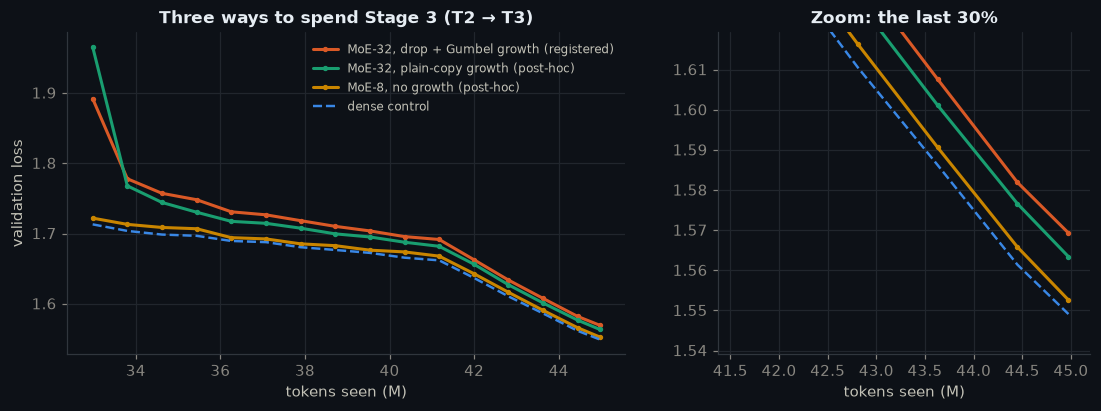

| T3 model | total / active | val loss (64 batches) | minus dense control | minus registered MoE-32 |
|---|---|---|---|---|
| dense control | 18.9M / 18.9M | 1.5432 | - | - |
| MoE-32, drop + Gumbel (registered) | 68.5M / 19.0M | 1.5633 | +0.0201 [+0.0191, +0.0212] | - |
| MoE-32, plain-copy growth (post-hoc) | 68.5M / 19.0M | 1.5579 | +0.0148 [+0.0135, +0.0160] | -0.0053 [-0.0065, -0.0042] |
| MoE-8, no growth (post-hoc) | 26.0M / 18.9M | 1.5463 | +0.0031 [+0.0020, +0.0042] | -0.0170 [-0.0182, -0.0158] |

Negative = the row's model is better. Brackets: 95% bootstrap interval over batches.

In [48]:
if have("posthoc") and have("runs", "moe32_copy"):
    P = R["points"]
    starts = {"moe32": P["moe32_T2"], "moe32_copy": P["moe32copy_T2"], "moe8_cont": P["moe8_T2"], "control_b": P["control_T2"]}
    fig, (a1, a2) = plt.subplots(1, 2, figsize=(12, 3.8), gridspec_kw={"width_ratios": [1.5, 1]})
    for name, label, color, ls in POSTHOC_RUNS:
        L = R["runs"][name]
        x = np.concatenate([[T2_TOK / 1e6], tokens_axis(L, L["eval_step"])])
        y = np.concatenate([[starts[name]], L["val"]])
        for ax in (a1, a2):
            ax.plot(x, y, color=color, ls=ls, marker="o" if ls == "-" else None, ms=2.5, lw=2 if ls == "-" else 1.6, label=label)
    a1.set(xlabel="tokens seen (M)", ylabel="validation loss", title="Three ways to spend Stage 3 (T2 → T3)")
    a1.legend(fontsize=8)
    ends = [R["runs"][n]["val"][-1] for n, *_ in POSTHOC_RUNS]
    a2.set_xlim(T2_TOK / 1e6 + 0.7 * S3 * TOK_STEP / 1e6, (T2_TOK + S3 * TOK_STEP) / 1e6 * 1.005)
    a2.set_ylim(min(ends) - 0.01, max(ends) + 0.05)
    a2.set(xlabel="tokens seen (M)", title="Zoom: the last 30%")
    savefig(fig, "posthoc_stage3")
    ph = R["posthoc"]
    rows = ["| T3 model | total / active | val loss (64 batches) | minus dense control | minus registered MoE-32 |", "|---|---|---|---|---|"]
    rows.append(f"| dense control | {R['params']['dense'] / 1e6:.1f}M / {R['params']['dense_active'] / 1e6:.1f}M "
                f"| {np.mean(R['final_pair']['control']):.4f} | - | - |")
    rows.append(f"| MoE-32, drop + Gumbel (registered) | {R['params']['moe32'] / 1e6:.1f}M / {R['params']['moe32_active'] / 1e6:.1f}M "
                f"| {np.mean(R['final_pair']['moe32']):.4f} | {R['paired']['mean']:+.4f} [{R['paired']['lo']:+.4f}, {R['paired']['hi']:+.4f}] | - |")
    for name, label in (("moe32_copy", "MoE-32, plain-copy growth"), ("moe8_cont", "MoE-8, no growth")):
        r, c, m = ph[name], ph[name]["vs_control"], ph[name]["vs_moe32"]
        rows.append(f"| {label} (post-hoc) | {r['params'] / 1e6:.1f}M / {r['active'] / 1e6:.1f}M | {r['val_T3']:.4f} "
                    f"| {c['mean']:+.4f} [{c['lo']:+.4f}, {c['hi']:+.4f}] | {m['mean']:+.4f} [{m['lo']:+.4f}, {m['hi']:+.4f}] |")
    display(Markdown("\n".join(rows) + "\n\nNegative = the row's model is better. Brackets: 95% bootstrap interval over batches."))

**What the post-hoc runs showed** (all three post-hoc predictions held).

1. **The recipe mattered, a little.** Plain-copy growth finished 0.005 nats below the registered
   drop + Gumbel recipe (P13), even though it *jumped more* at T2: 1.966 against 1.892. Four
   identical copies of one partition piece add up to four times that piece. Jump size alone did not
   predict the outcome. Copied clones keep their full function and only need to diverge; redrawn
   clones must relearn half their neurons.
2. **Growing at all mattered more.** Not growing beat both growth recipes. MoE-8 simply continued
   to T3 finished 0.017 below the registered MoE-32 (P14), with 26M parameters against 68.5M. A
   growth step costs 0.17–0.24 nats on the spot, and 12M tokens at this scale did not pay that back.
   Four times the experts at the same active compute needs far more tokens to earn its keep.
3. **No MoE beat the dense control (P15), but the gap was closing.** MoE-8 trailed the dense model
   by 0.009 at T2 and by 0.003 at T3 (CI 0.002 to 0.004). That is consistent with the T1 conversion
   cost being repaid slowly. Whether it overtakes with more tokens is the next experiment; it was not
   run here.

**For a growth plan at larger scale:** treat every growth step as a loss you must buy back. Grow only when
the next stage has many times the tokens that the jump takes to recover. Prefer growth that keeps
each expert's function (copies, or staggered copies), because redrawing neurons slows the recovery.
And grow early, while the learning rate is high, not in the last stretch before decay.

---
## L · What did the experts learn?

> Experts do not become subject specialists the way the name suggests; they mostly sort **kinds of tokens** (punctuation, names, function
> words), not subjects. TinyStories has only one subject, so token kind is the only thing left to
> sort by, which makes it a clean place to look.

Every measurement below runs the final MoE-32 over 131K held-out tokens and records each token's
top-4 experts in every layer. Nothing is trained.

In [49]:
FUNC_WORDS = set("the a an and to of was he she it they his her in on with for but so said is that you i we at as be had were there "
                 "one day him them their this not are can do what up then very".split())
CATS = ["end of text", "punctuation", "number", "capitalised word", "function word", "content word", "word piece"]

def token_category(tid, piece):
    if tid == 0:
        return "end of text"
    core = piece.strip()
    if not core or all(not c.isalnum() for c in core):
        return "punctuation"
    if any(c.isdigit() for c in core):
        return "number"
    if piece.startswith(" ") or piece[:1].isupper():
        if core[0].isupper():
            return "capitalised word"
        return "function word" if core.lower() in FUNC_WORDS else "content word"
    return "word piece"

@torch.no_grad()
def collect_routing(model, n_batches, B=32):
    moes = model.moe_layers()
    model.eval()
    for m in moes:
        m.record = True
    ids, tops = [], [[] for _ in moes]
    for i in range(n_batches):
        x, _ = VAL.batch(i * B, B)
        with amp():
            model(x)
        ids.append(x.reshape(-1).cpu())
        for j, m in enumerate(moes):
            tops[j].append(m.last["topi"].cpu())
    for m in moes:
        m.record = False
    return torch.cat(ids), [torch.cat(t) for t in tops]

def set_overlap(a, b):
    return float((a[:, :, None] == b[:, None, :]).any(-1).float().mean())

if COMPUTE and moe32 is not None and not have("experts"):
    ids, tops = collect_routing(moe32, BUDGET["val_batches"])
    E, k = moe32.moe_layers()[0].E, moe32.moe_layers()[0].k
    vocab_cat = [CATS.index(token_category(i, TOK.decode([i]))) for i in range(GCFG.vocab)]
    cat = torch.tensor(vocab_cat)[ids]
    ex = {"n_tokens": int(len(ids)), "cat_share": torch.bincount(cat, minlength=len(CATS)).div(len(ids)).tolist()}
    # first-choice counts per (token category, expert); lift is computed when plotting
    ex["counts"] = {}
    for layer in (0, 3, 7):
        first = tops[layer][:, 0]
        ex["counts"][str(layer)] = torch.bincount(cat * E + first, minlength=len(CATS) * E).view(len(CATS), E).tolist()
    # top tokens per expert (layer 4): highest lift among tokens seen >= 30 times
    first = tops[3][:, 0]
    cnt_tok = torch.bincount(ids, minlength=GCFG.vocab).float()
    pe = torch.bincount(first, minlength=E).float() / len(first)
    tt = []
    for e in range(E):
        c_e = torch.bincount(ids[first == e], minlength=GCFG.vocab).float()
        lift = c_e / cnt_tok.clamp_min(1) / pe[e].clamp_min(1e-9)
        lift[cnt_tok < 30] = 0
        best = lift.topk(6).indices.tolist()
        tt.append(dict(share=float(pe[e]), tokens=[TOK.decode([i]) for i in best], lift=[round(float(lift[i]), 1) for i in best]))
    ex["top_tokens_layer4"] = tt
    # consecutive tokens sharing their first-choice expert, vs chance
    cons = []
    for layer, t in enumerate(tops):
        f = t[:, 0].view(-1, GCFG.ctx)
        agree = float((f[:, 1:] == f[:, :-1]).float().mean())
        p = torch.bincount(t[:, 0], minlength=E).float() / t.shape[0]
        cons.append(dict(layer=layer + 1, agree=agree, chance=float((p ** 2).sum())))
    ex["consecutive"] = cons
    # load per expert over all k picks (for pruning)
    usage = [torch.bincount(t.reshape(-1), minlength=E).float() for t in tops]
    base = evaluate(moe32, BUDGET["val_batches"])
    def masked_val(drop):                       # drop: {layer: [experts]}
        for li, m in enumerate(moe32.moe_layers()):
            m.mask[:] = True
            m.mask[drop.get(li, [])] = False
        v = evaluate(moe32, BUDGET["val_batches"])
        for m in moe32.moe_layers():
            m.mask[:] = True
        return v
    half = {li: u.argsort()[: E // 2].tolist() for li, u in enumerate(usage)}
    flat = torch.stack(usage).flatten()
    top3 = flat.topk(3).indices.tolist()
    super3 = {}
    for g in top3:
        super3.setdefault(g // E, []).append(g % E)
    rng = np.random.default_rng(0)
    rand = []
    for _ in range(5):
        pick = rng.choice(len(flat), 3, replace=False)
        dct = {}
        for g in pick:
            dct.setdefault(int(g) // E, []).append(int(g) % E)
        rand.append(masked_val(dct))
    ex["prune"] = dict(base=base, half=masked_val(half), top3=masked_val(super3), top3_ids=[(g // E + 1, g % E) for g in top3],
                       top3_share=[float(flat[g] / usage[0].sum()) for g in top3], random3=rand)
    # how fast routing settles: overlap of each snapshot's top-4 with the end-of-stage top-4
    settle = {}
    for run in ("moe8", "moe32"):
        snaps = SNAP.get(run, {})
        if len(snaps) >= 2:
            last = snaps[max(snaps)]
            n = R["runs"][run]["steps"]
            settle[run] = dict(frac=[s / n for s in sorted(snaps)],
                               overlap=[[set_overlap(a, b) for a, b in zip(snaps[s], last)] for s in sorted(snaps)])
    if settle:
        ex["settling"] = settle
    R["experts"] = ex
    save_results()

### Which kinds of tokens go where

Colour is **lift**: how much more (warm) or less (cool) often an expert is a category's first
choice than it is overall. 1× is grey; a row of grey means that category is spread evenly. Blank
cells had fewer than 5 expected tokens, too few to say.

🧠 **Intuition.** Lift asks: "if I know this token is punctuation, how much more likely is expert
7 to be its first choice than for an average token?" A lift of 4× means expert 7 is a punctuation
specialist; 1× means it does not care.

<details><summary>📐 <b>The math:</b> lift, chance agreement, and routing overlap</summary>

**Lift.** Let $n_{c,e}$ count tokens of category $c$ whose first choice is expert $e$, with $n_c$, $n_e$
the row and column totals and $N$ the total:

$$\operatorname{lift}(c, e) = \frac{P(e \mid c)}{P(e)} = \frac{n_{c,e}/n_c}{n_e/N} = \frac{n_{c,e}}{\mathbb{E}[n_{c,e}]}, \qquad \mathbb{E}[n_{c,e}] = \frac{n_c\,n_e}{N} \text{ under independence.}$$

We blank cells with $\mathbb{E}[n_{c,e}] < 5$.

**Chance agreement.** Draw two tokens independently. Their first choices agree with probability

$$\sum_{i=1}^{E} p_i^2, \qquad p_i = \text{expert } i\text{'s share of first choices}.$$

That equals $1/E$ for uniform routing (1/32 ≈ 3.1%) and is larger when routing is uneven.
Consecutive tokens agreeing far more often than $\sum p_i^2$ means routing follows local
structure: words, phrases, syntax.

**Routing overlap**, comparing the chosen set at step $s$ with the end of the stage, on a fixed
probe batch:

$$\operatorname{overlap}(s) = \frac{1}{N}\sum_{t=1}^{N} \frac{\lvert \mathcal{T}_t^{(s)} \cap \mathcal{T}_t^{(\text{end})} \rvert}{k}.$$

For random routing this is about $k/E$ (0.125 in Stage 3).

</details>

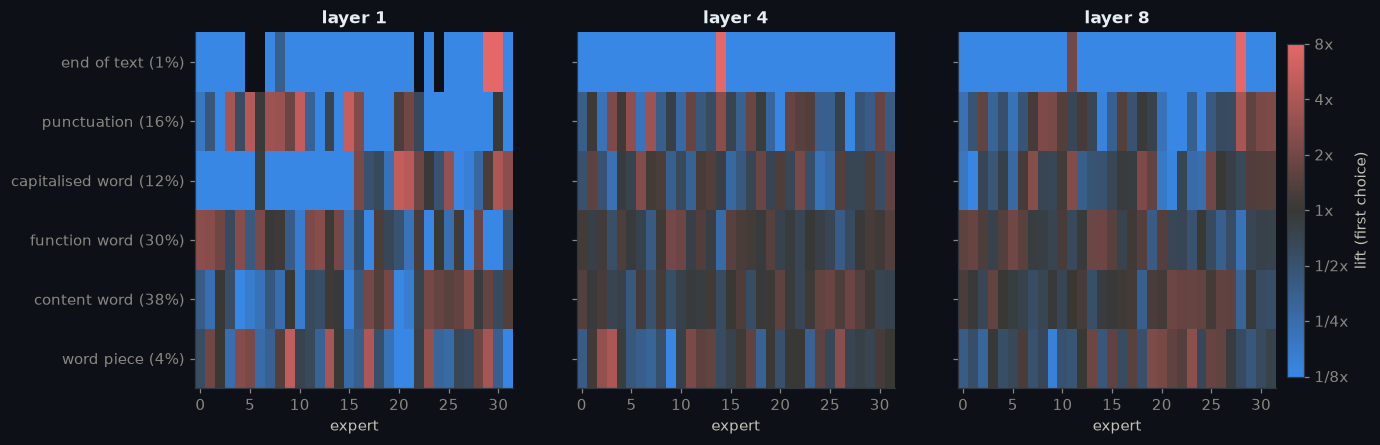

In [50]:
if have("experts"):
    ex = R["experts"]
    rows = [i for i, s in enumerate(ex["cat_share"]) if s >= 0.005]          # skip categories that barely occur
    fig, axes = plt.subplots(1, 3, figsize=(13, 0.5 * len(rows) + 1.2), sharey=True)
    for ax, layer in zip(axes, ("0", "3", "7")):
        Cn = np.asarray(ex["counts"][layer], float)[rows]
        expected = Cn.sum(1, keepdims=True) * Cn.sum(0, keepdims=True) / Cn.sum()
        lift = np.where(expected >= 5, Cn / np.maximum(expected, 1e-9), np.nan)       # too few tokens to say: blank
        M = np.log2(np.clip(lift, 1 / 8, 8))
        im = ax.imshow(M, aspect="auto", cmap=DIV, vmin=-3, vmax=3, interpolation="nearest")
        ax.set(title=f"layer {int(layer) + 1}", xlabel="expert")
        ax.set_yticks(range(len(rows)), [f"{CATS[i]} ({ex['cat_share'][i]:.0%})" for i in rows])
        ax.grid(False)
    cb = fig.colorbar(im, ax=axes, fraction=0.015, pad=0.01, ticks=[-3, -2, -1, 0, 1, 2, 3])
    cb.ax.set_yticklabels(["1/8x", "1/4x", "1/2x", "1x", "2x", "4x", "8x"])
    cb.set_label("lift (first choice)", color=INK2)
    savefig(fig, "experts_by_token_kind")

**The most characteristic tokens of each expert** (layer 4, first choice). For each expert, these are
the tokens with the highest lift among tokens seen at least 30 times.

In [51]:
if have("experts"):
    tt = R["experts"]["top_tokens_layer4"]
    order = sorted(range(len(tt)), key=lambda e: -max(tt[e]["lift"] or [0]))
    lines = ["| expert | share of first choices | most characteristic tokens (lift) |", "|---|---|---|"]
    for e in order:
        toks = ", ".join(f"`{t.replace('|', '¦').replace(chr(10), '⏎')!r}` {l}x" for t, l in zip(tt[e]["tokens"], tt[e]["lift"]))
        lines.append(f"| {e} | {tt[e]['share']:.1%} | {toks} |")
    display(Markdown("\n".join(lines)))

| expert | share of first choices | most characteristic tokens (lift) |
|---|---|---|
| 0 | 0.8% | `' asked'` 91.2x, `' time'` 56.4x, `' called'` 45.5x, `' said'` 28.5x, `' nodded'` 27.0x, `' says'` 16.1x |
| 6 | 1.1% | `'One'` 68.8x, `' because'` 60.6x, `' until'` 43.5x, `' window'` 40.4x, `' sky'` 37.2x, `' top'` 35.2x |
| 3 | 1.4% | `'c'` 57.9x, `'le'` 21.6x, `' after'` 20.0x, `' down'` 17.5x, `'l'` 16.4x, `' near'` 15.0x |
| 25 | 1.6% | `' others'` 54.3x, `' us'` 32.0x, `' book'` 25.9x, `' thing'` 22.0x, `' ball'` 21.0x, `' toy'` 19.1x |
| 2 | 1.6% | `' or'` 52.0x, `'Can'` 36.9x, `' not'` 31.6x, `' wanted'` 31.2x, `"'t"` 30.8x, `' if'` 24.2x |
| 15 | 1.6% | `' happened'` 47.9x, `' unexpected'` 46.4x, `' saw'` 19.4x, `' kitchen'` 19.1x, `' there'` 18.6x, `' again'` 15.6x |
| 30 | 1.0% | `' couldn'` 47.3x, `' paper'` 33.9x, `' Now'` 29.0x, `' but'` 22.3x, `' hugged'` 22.2x, `' can'` 17.8x |
| 12 | 1.7% | `' its'` 45.1x, `' ground'` 43.1x, `' park'` 29.0x, `' It'` 28.5x, `' does'` 26.3x, `' it'` 24.5x |
| 11 | 1.9% | `'f'` 38.6x, `' am'` 31.6x, `"'m"` 22.8x, `' don'` 16.7x, `' every'` 15.9x, `' through'` 13.5x |
| 21 | 1.7% | `' reach'` 36.2x, `' find'` 21.0x, `' catch'` 19.1x, `' And'` 18.5x, `' S'` 15.6x, `'Hi'` 13.9x |
| 18 | 2.6% | `' Then'` 32.7x, `' share'` 20.8x, `'Then'` 18.1x, `' soon'` 13.6x, `' then'` 12.3x, `'Oh'` 12.1x |
| 14 | 3.3% | `''` 30.3x, `'Once'` 12.8x, `' let'` 9.2x, `'?'` 9.0x, `'Let'` 9.0x, `' Let'` 8.7x |
| 19 | 1.7% | `' shared'` 29.3x, `' had'` 21.6x, `' goodbye'` 18.9x, `' boat'` 15.7x, `' fish'` 15.0x, `' both'` 14.1x |
| 31 | 3.4% | `'Hello'` 25.8x, `' thanked'` 23.0x, `' there'` 14.9x, `'Hi'` 14.4x, `' nodded'` 12.6x, `'It'` 12.4x |
| 17 | 1.9% | `'As'` 25.0x, `' "'` 22.2x, `' good'` 20.4x, `' as'` 19.3x, `'"'` 18.6x, `' best'` 17.6x |
| 23 | 3.9% | `' happily'` 25.0x, `' high'` 21.3x, `' ran'` 18.5x, `' run'` 18.5x, `' When'` 17.3x, `' ever'` 14.7x |
| 8 | 2.2% | `' walk'` 24.9x, `' way'` 21.1x, `' story'` 21.1x, `' playing'` 17.9x, `' met'` 17.2x, `' One'` 16.2x |
| 24 | 2.3% | `' proud'` 24.2x, `' should'` 18.6x, `"'m"` 18.5x, `' found'` 18.0x, `' bright'` 17.7x, `' knew'` 16.9x |
| 4 | 3.7% | `'You'` 23.4x, `' You'` 20.3x, `'No'` 18.7x, `' decided'` 17.4x, `' also'` 14.6x, `' then'` 12.9x |
| 7 | 1.8% | `' excited'` 22.7x, `' surprised'` 16.6x, `' Let'` 16.0x, `'He'` 14.5x, `' bright'` 9.3x, `' pink'` 9.1x |
| 26 | 3.2% | `' funny'` 22.7x, `' light'` 21.5x, `' magic'` 19.4x, `' important'` 18.7x, `' new'` 17.0x, `' l'` 13.9x |
| 20 | 2.9% | `' Can'` 22.1x, `' me'` 20.0x, `' angry'` 15.1x, `' here'` 13.8x, `' watched'` 13.0x, `' jump'` 12.6x |
| 29 | 3.5% | `' move'` 20.8x, `' anymore'` 20.0x, `' rabbit'` 15.9x, `' Jack'` 15.8x, `' away'` 14.9x, `' so'` 12.0x |
| 16 | 4.4% | `' off'` 18.7x, `' being'` 18.3x, `' over'` 15.6x, `' open'` 15.3x, `' keep'` 14.9x, `' stop'` 14.9x |
| 27 | 5.0% | `' fix'` 17.7x, `' tired'` 17.2x, `' flew'` 17.1x, `' learned'` 16.3x, `' broken'` 15.3x, `' animals'` 14.5x |
| 13 | 5.3% | `' careful'` 15.7x, `' opened'` 12.2x, `'Look'` 10.8x, `' long'` 10.6x, `' used'` 10.5x, `' our'` 10.1x |
| 28 | 4.9% | `' eyes'` 13.7x, `' grass'` 13.7x, `' lots'` 13.4x, `' store'` 13.2x, `' lot'` 11.8x, `' garden'` 11.8x |
| 22 | 6.7% | `'Yes'` 13.1x, `' smile'` 11.8x, `' Mom'` 9.8x, `' Sara'` 8.2x, `'Ben'` 8.1x, `'ie'` 7.7x |
| 1 | 7.6% | `' hide'` 12.3x, `' sunny'` 10.3x, `' picked'` 8.2x, `' upon'` 7.5x, `' very'` 7.1x, `'Wow'` 6.6x |
| 5 | 6.4% | `' All'` 11.7x, `' c'` 10.0x, `'That'` 9.5x, `' room'` 7.8x, `' Every'` 5.7x, `' great'` 5.3x |
| 10 | 4.3% | `' boy'` 11.5x, `' the'` 9.4x, `' named'` 9.3x, `' my'` 7.3x, `' heard'` 7.0x, `' small'` 6.8x |
| 9 | 4.6% | `' many'` 10.2x, `' through'` 9.8x, `' in'` 9.2x, `' a'` 8.9x, `' '` 8.4x, `' upon'` 7.5x |

### Neighbouring tokens share experts; and how fast routing settles

The left panel shows how often two consecutive tokens get the same first-choice expert, compared
with chance (Σpᵢ², the agreement two random tokens would have). Mixtral measured 24–28% against
12.5%. The right panel shows how much of the end-of-stage routing is already in place at each point
of the stage (OLMoE: *"60% settled after 1% of training"*).

Our routing settles **late**, and that is expected here. OLMoE's figure is for a model trained from
scratch with a fixed router. Our Stage 3 sampled its routing (Gumbel) for the first 15%, and its
bias balancer kept moving loads until the final decay. Every stage also starts from a freshly
converted router, so the end-of-stage routing is still being formed.

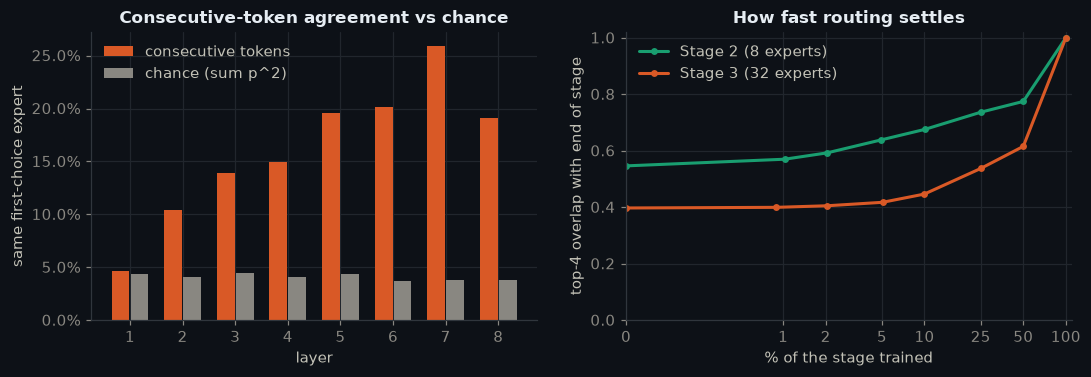

In [52]:
if have("experts"):
    ex = R["experts"]
    fig, (a1, a2) = plt.subplots(1, 2, figsize=(11.5, 3.4))
    cons = ex["consecutive"]
    x = np.arange(1, len(cons) + 1)
    a1.bar(x - 0.18, [c["agree"] for c in cons], width=0.34, color=MOE_C, label="consecutive tokens")
    a1.bar(x + 0.18, [c["chance"] for c in cons], width=0.34, color=MUTED, label="chance (sum p^2)")
    a1.set(xlabel="layer", ylabel="same first-choice expert", title="Consecutive-token agreement vs chance", xticks=x)
    a1.yaxis.set_major_formatter(matplotlib.ticker.PercentFormatter(1.0))
    a1.legend()
    if "settling" in ex:
        for run, color, lab in (("moe8", SERIES[2], "Stage 2 (8 experts)"), ("moe32", MOE_C, "Stage 3 (32 experts)")):
            if run in ex["settling"]:
                s = ex["settling"][run]
                ov = np.asarray(s["overlap"])
                a2.plot(np.asarray(s["frac"]) * 100, ov.mean(1), color=color, marker="o", ms=3.5, label=lab)
        a2.set(xlabel="% of the stage trained", ylabel="top-4 overlap with end of stage", title="How fast routing settles", ylim=(0, 1.02))
        a2.set_xscale("symlog", linthresh=1)
        a2.set_xticks([0, 1, 2, 5, 10, 25, 50, 100], ["0", "1", "2", "5", "10", "25", "50", "100"])
        a2.set_xlim(0, 110)
        a2.legend()
    else:
        a2.axis("off")
    savefig(fig, "experts_consecutive_settling")

### Remove experts and see what breaks

*REAP (2025):* half the experts can be removed with under 2% loss. *Super Experts (2025):* three
experts out of 6,144 hold the model up. Masked experts can no longer be chosen; each token picks
its 4 from the rest.

In [53]:
if have("experts"):
    p = R["experts"]["prune"]
    rel = lambda v: (v - p["base"]) / p["base"]
    rows = ["| experts removed | val loss | change |", "|---|---|---|",
            f"| none | {p['base']:.4f} | - |",
            f"| least-used half in every layer (128 of 256) | {p['half']:.4f} | {rel(p['half']):+.2%} |",
            f"| the 3 most-used experts (layer, id) = {p['top3_ids']} | {p['top3']:.4f} | {rel(p['top3']):+.2%} |",
            f"| 3 random experts, mean of 5 draws | {np.mean(p['random3']):.4f} | {rel(np.mean(p['random3'])):+.2%} |"]
    display(Markdown("\n".join(rows)))

| experts removed | val loss | change |
|---|---|---|
| none | 1.5693 | - |
| least-used half in every layer (128 of 256) | 1.5831 | +0.88% |
| the 3 most-used experts (layer, id) = [[3, 23], [2, 25], [3, 31]] | 1.5693 | -0.00% |
| 3 random experts, mean of 5 draws | 1.5697 | +0.02% |

**Carry this forward:** specialization comes out of training, and in a one-domain corpus it can only
be about the kind of token: end-of-text, punctuation and capitalised words each have experts that
prefer them, and neighbouring tokens share experts far more often than chance. Half of the routed
experts could be removed for under 1% loss here. That is the redundancy REAP measured, and the same
redundancy a careful growth strategy tries not to build in. The "super expert" effect did not
appear at this scale: removing the three busiest experts cost no more than removing three at random
(P11 missed).

---
## M · Systems view: capacity, placement, memory and time

> Capacity and token dropping, expert parallelism, choosing a layout, and the rule that compute
> follows the active parameters while memory follows the total.

### M.1 What token dropping would have cost

Old-style MoEs gave every expert a fixed number of slots,
`capacity = tokens × k / E × capacity factor`. Tokens beyond that were **dropped**: they skipped the
expert and went on through the residual. Our model is dropless. Here its real routing is replayed
with capacity limits, using 8,192-token groups as in the reference example, to see how much would
have been dropped and what that would have cost.

In [54]:
@torch.no_grad()
def capacity_eval(model, cf, n_batches, B=32):
    moes = model.moe_layers()
    for m in moes:
        m.capacity_factor = cf
    model.eval()
    losses, dropped, total = [], 0, 0
    for i in range(n_batches):
        x, y = VAL.batch(i * B, B)
        with amp():
            _, l = model(x, y)
        losses.append(l.item())
        if cf is not None:
            dropped += sum(m.last["dropped"] for m in moes)
        total += x.numel() * moes[0].k * len(moes)
    for m in moes:
        m.capacity_factor = None
    return float(np.mean(losses)), dropped / total

if COMPUTE and moe32 is not None and not have("capacity"):
    R["capacity"] = [dict(cf=cf, val=v, dropped=d) for cf in (None, 2.0, 1.5, 1.25, 1.0)
                     for v, d in [capacity_eval(moe32, cf, BUDGET["val_batches"])]]
    save_results()
if have("capacity"):
    base = R["capacity"][0]["val"]
    display(Markdown("| capacity factor | tokens x experts dropped | val loss | vs dropless |\n|---|---|---|---|\n" + "\n".join(
        f"| {'dropless' if r['cf'] is None else r['cf']} | {r['dropped']:.2%} | {r['val']:.4f} | {r['val'] - base:+.4f} |" for r in R["capacity"])))

| capacity factor | tokens x experts dropped | val loss | vs dropless |
|---|---|---|---|
| dropless | 0.00% | 1.5693 | +0.0000 |
| 2.0 | 0.07% | 1.5693 | +0.0000 |
| 1.5 | 0.86% | 1.5693 | -0.0000 |
| 1.25 | 3.45% | 1.5700 | +0.0007 |
| 1.0 | 11.84% | 1.5739 | +0.0046 |

### M.2 If the 32 experts lived on 8 GPUs (EP = 8)

A thought experiment on real routing. Experts 0–3 sit on GPU 0, experts 4–7 on GPU 1, and so on. A
batch of 32 sequences is split 4 per GPU, which is each token's *home*. Every chosen expert that
lives elsewhere means a copy of the token vector goes out (dispatch) and comes back (combine). The
slowest GPU sets the pace, so what matters is the **busiest GPU's load relative to the average**.

🧠 **Intuition.** A relay team runs at the speed of its slowest runner. If one GPU holds the
popular experts, the other seven finish their work and then wait. Imbalance that cost nothing on
one GPU becomes idle hardware on eight.

<details><summary>📐 <b>The math:</b> straggler time and traffic per token</summary>

**Straggler time.** With experts placed on $G$ GPUs and $n_g$ token copies arriving at GPU $g$, the
expert compute of a step takes time proportional to the busiest GPU:

$$t_{\text{step}} \;\propto\; \max_g n_g \;=\; \underbrace{\frac{\max_g n_g}{\bar n}}_{\text{straggler factor}} \cdot \bar n.$$

A straggler factor of 1.3 wastes $1 - 1/1.3 \approx 23\%$ of the expert compute across the cluster.

**Traffic.** A token whose $k$ copies each stay on its home GPU with probability $p_{\text{home}}$
sends, per layer and per direction,

$$k \cdot d \cdot 2\ \text{bytes} \cdot (1 - p_{\text{home}}).$$

Ours: $4 \cdot 384 \cdot 2 \cdot \tfrac78 \approx 2.6$ KiB out, and the same back, which is the 5.25 KiB in the
table. With random placement, $p_{\text{home}} = 1/G = 12.5\%$.

</details>

In [55]:
if COMPUTE and moe32 is not None and not have("ep"):
    ids, tops = collect_routing(moe32, 4)
    G, per = 8, moe32.moe_layers()[0].E // 8
    rows = []
    for li, t in enumerate(tops):
        home = (torch.arange(t.shape[0]) // GCFG.ctx // 4) % G          # 4 sequences per GPU per batch of 32
        dest = t // per                                                 # [N, k] GPU holding each chosen expert
        recv = torch.bincount(dest.reshape(-1), minlength=G).float()
        stay = float((dest == home[:, None]).float().mean())
        rows.append(dict(layer=li + 1, max_over_mean=float(recv.max() / recv.mean()), stay_home=stay,
                         kib_per_token=moe32.moe_layers()[0].k * GCFG.d * 2 * (1 - stay) * 2 / 1024))
    R["ep"] = rows
    save_results()
if have("ep"):
    display(Markdown("| layer | busiest GPU / average | token copies that stay home | dispatch + combine per token (bf16) |\n|---|---|---|---|\n" + "\n".join(
        f"| {r['layer']} | {r['max_over_mean']:.2f}x | {r['stay_home']:.0%} (1/8 = 12.5% if random) | {r['kib_per_token']:.2f} KiB |" for r in R["ep"])))

| layer | busiest GPU / average | token copies that stay home | dispatch + combine per token (bf16) |
|---|---|---|---|
| 1 | 1.16x | 12% (1/8 = 12.5% if random) | 5.26 KiB |
| 2 | 1.18x | 13% (1/8 = 12.5% if random) | 5.25 KiB |
| 3 | 1.16x | 13% (1/8 = 12.5% if random) | 5.21 KiB |
| 4 | 1.14x | 12% (1/8 = 12.5% if random) | 5.25 KiB |
| 5 | 1.11x | 12% (1/8 = 12.5% if random) | 5.27 KiB |
| 6 | 1.17x | 12% (1/8 = 12.5% if random) | 5.26 KiB |
| 7 | 1.11x | 13% (1/8 = 12.5% if random) | 5.24 KiB |
| 8 | 1.11x | 13% (1/8 = 12.5% if random) | 5.22 KiB |

### M.3 Memory follows the total, time follows... it depends

Three models, each trained from fresh weights for a few steps on one micro-batch (32 × 256). Timing
uses **ABBA order** (D, M8, M32, M32, M8, D) after a warm-up. A laptop GPU slows down as it heats,
so whichever model ran first would otherwise look fastest. The mirrored order cancels a linear drift.

The training state is analytic (16 bytes per parameter: fp32 weight, fp32 gradient, two fp32 Adam
moments). The activation peak is measured.

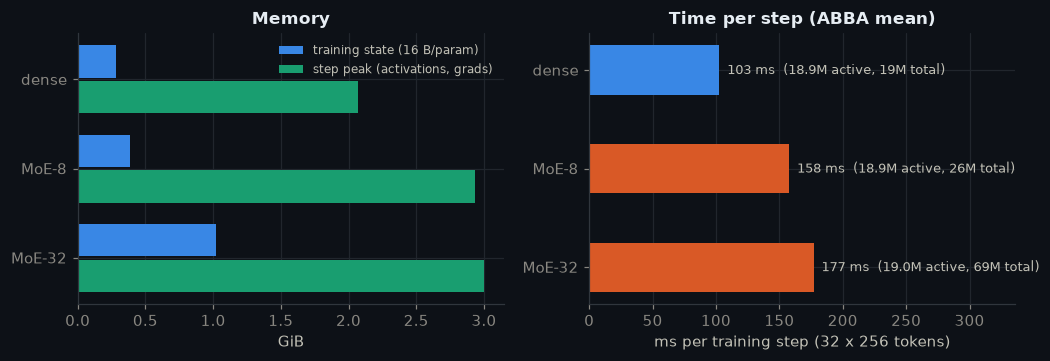

In [56]:
def bench_models():
    cfg8, cfg32 = copy.deepcopy(MAIN_MOE8), copy.deepcopy(MAIN_MOE8)
    cfg32.n_exp, cfg32.family = 32, 4
    return {"dense": GPT(GCFG), "MoE-8": GPT(GCFG, cfg8), "MoE-32": GPT(GCFG, cfg32)}

if COMPUTE and not have("bench"):
    for v in ("dense_opt", "moe8_opt", "control_opt", "moe32_opt"):
        globals()[v] = None
    torch.cuda.empty_cache()
    models = {k: m.to(DEVICE) for k, m in bench_models().items()}
    opts = {k: make_opt(m) for k, m in models.items()}
    x, y = TRAIN.batch(0, BUDGET["micro_batch"])
    def step(k):
        with amp():
            _, l = models[k](x, y)
        l.backward()
        opts[k].step()
        opts[k].zero_grad(set_to_none=True)
    for k in models:                                   # warm-up and memory
        for _ in range(3):
            step(k)
    mem = {}
    for k in models:
        torch.cuda.synchronize(); torch.cuda.reset_peak_memory_stats()
        before = torch.cuda.memory_allocated()
        step(k); torch.cuda.synchronize()
        mem[k] = (torch.cuda.max_memory_allocated() - before) / 2**30
    order = ["dense", "MoE-8", "MoE-32", "MoE-32", "MoE-8", "dense"]
    n = 4 if MODE == "quick" else 15
    times = {k: [] for k in models}
    for k in order:
        torch.cuda.synchronize(); t0 = time.time()
        for _ in range(n):
            step(k)
        torch.cuda.synchronize(); times[k].append((time.time() - t0) / n)
    R["bench"] = {k: dict(ms=1000 * float(np.mean(times[k])), passes=[round(1000 * t, 1) for t in times[k]],
                          act_gib=mem[k], state_gib=n_params(models[k]) * 16 / 2**30,
                          params=n_params(models[k]), active=n_active(models[k])) for k in models}
    del models, opts
    torch.cuda.empty_cache()
    save_results()
if have("bench"):
    b = R["bench"]
    fig, (a1, a2) = plt.subplots(1, 2, figsize=(11, 3.2))
    names = list(b)
    yy = np.arange(len(names))
    a1.barh(yy - 0.2, [b[k]["state_gib"] for k in names], height=0.36, color=SERIES[0], label="training state (16 B/param)")
    a1.barh(yy + 0.2, [b[k]["act_gib"] for k in names], height=0.36, color=SERIES[2], label="step peak (activations, grads)")
    a1.set_yticks(yy, names); a1.invert_yaxis()
    a1.set(xlabel="GiB", title="Memory")
    a1.legend(fontsize=8)
    a2.barh(yy, [b[k]["ms"] for k in names], height=0.5, color=[DENSE_C, MOE_C, MOE_C])
    for i, k in enumerate(names):
        a2.text(b[k]["ms"], i, f"  {b[k]['ms']:.0f} ms  ({b[k]['active'] / 1e6:.1f}M active, {b[k]['params'] / 1e6:.0f}M total)",
                va="center", color=INK2, fontsize=8.5)
    a2.set_yticks(yy, names); a2.invert_yaxis()
    a2.set(xlabel="ms per training step (32 x 256 tokens)", title="Time per step (ABBA mean)")
    a2.set_xlim(0, max(b[k]["ms"] for k in names) * 1.9)
    savefig(fig, "bench_memory_time")

Same active parameters, so the same FLOPs per token, yet the MoE steps are slower on one GPU. The
FLOPs are the same, but they arrive as batched matmuls over padded expert groups plus a sort, a
gather and a scatter. This is the single-GPU face of the general rule that MoE trades compute
for memory *and* data movement. At scale it is the all-to-all; here it is kernel launches and
memory traffic.

### M.4 The calculator, checked against our models, and a layout recipe

In [57]:
def our_count(E=None, k=None, w=None, shared=0):
    if E is None:
        return count_moe(L=GCFG.n_layer, d=GCFG.d, vocab=GCFG.vocab, n_q=GCFG.n_head, n_kv=GCFG.n_kv, hd=GCFG.d // GCFG.n_head,
                         E=0, k=0, w=0, tied=True, dense_ffn=GCFG.ffn)
    return count_moe(L=GCFG.n_layer, d=GCFG.d, vocab=GCFG.vocab, n_q=GCFG.n_head, n_kv=GCFG.n_kv, hd=GCFG.d // GCFG.n_head,
                     E=E, k=k, w=w, shared=shared, tied=True)

norms = (2 * GCFG.n_layer + 1) * GCFG.d
cfg32 = copy.deepcopy(MAIN_MOE8); cfg32.n_exp = 32
for label, (tot, act), cfg in (("dense", our_count(), None), ("MoE-8", our_count(8, 4, 192, 768), MAIN_MOE8),
                               ("MoE-32", our_count(32, 4, 192, 768), cfg32)):
    m = GPT(GCFG, cfg)
    print(f"{label:<7} calculator {tot + norms:>11,} total, {act + norms:>11,} active | model {n_params(m):>11,} total, {n_active(m):>11,} active")
    assert tot + norms == n_params(m) and act + norms == n_active(m)
    del m
gate("parameter calculator == the models' numel (dense, MoE-8, MoE-32)", True)

# Qwen3-30B-A3B shape on one node with EP = 8
exp_gib = 28.99e9 / 8 * 16 / GiB
dense_gib = 1.54e9 * (4 + 12 / 8) / GiB
act_gib = 8192 * 2048 * 34 * 48 / GiB
print(f"reference model, EP=8: experts {exp_gib:.1f} GiB + dense parts (ZeRO-1 over 8) {dense_gib:.1f} GiB = state "
      f"{exp_gib + dense_gib:.1f} GiB; + activations {act_gib:.1f} GiB = {exp_gib + dense_gib + act_gib:.1f} GiB "
      f"-> fits B200 (167.6), not H100 (74.5)")
dense16 = 1.54e9 * (4 + 12 / 16) / GiB                       # two nodes: ZeRO-1 over 16 copies
print(f"two H100 nodes, EP=16: experts {exp_gib / 2:.1f} + dense {dense16:.1f} = state {exp_gib / 2 + dense16:.1f} GiB; "
      f"with activations {exp_gib / 2 + dense16 + act_gib:.1f} GiB -> fits")
assert round(exp_gib, 1) == 54.0 and round(dense_gib, 1) == 7.9 and round(act_gib, 1) == 25.5
assert round(exp_gib + dense_gib + act_gib, 1) == 87.4
assert round(exp_gib / 2 + dense16, 1) == 33.8 and round(exp_gib / 2 + dense16 + act_gib, 1) == 59.3

dense   calculator  18,880,896 total,  18,880,896 active | model  18,880,896 total,  18,880,896 active


MoE-8   calculator  25,983,360 total,  18,905,472 active | model  25,983,360 total,  18,905,472 active


MoE-32  calculator  68,524,416 total,  18,979,200 active | model  68,524,416 total,  18,979,200 active
[PASS] parameter calculator == the models' numel (dense, MoE-8, MoE-32)
reference model, EP=8: experts 54.0 GiB + dense parts (ZeRO-1 over 8) 7.9 GiB = state 61.9 GiB; + activations 25.5 GiB = 87.4 GiB -> fits B200 (167.6), not H100 (74.5)
two H100 nodes, EP=16: experts 27.0 + dense 6.8 = state 33.8 GiB; with activations 59.3 GiB -> fits


| step | reference model on 8 × B200 | our MoE-32 on one laptop GPU |
|---|---|---|
| 1. count total and active | 30.53B / 3.35B | 68M / 18.9M |
| 2. expert parallelism = GPUs in a node | EP = 8, 16 experts per GPU | EP = 1, all 32 experts local |
| 3. ZeRO-1 for the dense parts | 7.9 GiB per GPU | not needed |
| 4. training state per GPU | 61.9 GiB | ~1.0 GiB (16 B × 68.5M) |
| 5. add activations | +25.5 GiB per 8K-token sequence | see M.3 |
| 6. tokens per expert per step | 4,096 (≥ ~280 to keep matrix units busy) | 8,192 × 4 / 32 = 1,024 per micro-batch |
| 7. all-to-all vs compute | 0.050 s vs 0.073 s per sequence | none (one GPU) |
| 8. cross nodes only if it does not fit | not needed on B200; EP = 16 on H100 | not needed |
| 9. measure the step time | Megatron: EP 8, no TP/PP | M.3 |

**Carry this forward:** dropping tokens is a quality cost you no longer need to pay. Placement turns
routing imbalance into GPU stragglers. On one GPU an MoE has the FLOPs of its active size but runs
slower than a dense model of that size.

---
## N · Predictions, open design questions, and a cheat sheet

### N.1 The predictions, scored

P1–P12 were written down (and committed in `predictions.json`) **before** the full run. P13–P15
(marked †) were added **after** the first full run and before the post-hoc runs of Part K.2. Each
one is scored mechanically from `R` below. A MISS is reported as a MISS, and no prediction was
edited after the fact.

In [58]:
PREDICTIONS = [{'id': 'P1', 'claim': "MoE-8 is back below the dense model's T1 val loss within the first 25% of Stage 2.", 'why': 'Partition preserves the dense output on average; the jump should be small and the extra capacity should recover it fast.'}, {'id': 'P2', 'claim': 'CORE CRITERION: every MoE stage ends below its own conversion-point val loss, and MoE-32 at T3 is below dense at T1.', 'why': 'This is the core requirement: after each conversion the model keeps training and the loss keeps falling.'}, {'id': 'P3', 'claim': 'At T3 MoE-32 beats the dense control: paired per-batch mean difference < 0 and its 95% bootstrap CI excludes 0.', 'why': 'Same active compute per token, 3.6x the parameters, and the dense model is far from saturated on TinyStories.'}, {'id': 'P4', 'claim': 'Balancing lab: with no balancing some layer ends with >= 1 nearly-dead expert; with the bias method no layer does, and its mean MaxVio is the lowest of the three.', 'why': 'Routing collapse (section 10) needs no special trigger, and the bias method is the standard fix.'}, {'id': 'P5', 'claim': 'At the start of Stage 3 (hard top-k, router tiled with small noise) more than 50% of tokens put all 4 picks inside one clone family.', 'why': 'Tied router scores within a family make top-k take the whole best family: the Lightning LM failure.'}, {'id': 'P6', 'claim': 'Growth lab: copy + hard top-k ends with more nearly-dead experts (summed over layers) than drop + Gumbel top-k.', 'why': 'Identical clones under hard routing cannot be told apart; redrawn halves plus sampling give every clone gradient.'}, {'id': 'P7', 'claim': 'Growth lab: staggered-bias copy ends the lab window at a val loss at or below drop + Gumbel.', 'why': 'It starts with zero loss jump and hands tokens to clones gradually. Untested idea; may fail.'}, {'id': 'P8', 'claim': 'Router lab: sigmoid ends with a lower mean MaxVio than softmax under the same bias balancing.', 'why': 'A study of balancing methods found sigmoid less sensitive to uneven load.'}, {'id': 'P9', 'claim': 'Consecutive tokens share their first-choice expert more often than chance in every middle layer.', 'why': 'Mixtral: 24-28% vs 12.5% chance; routing follows local syntax.'}, {'id': 'P10', 'claim': 'Masking the least-used half of the routed experts in every layer raises MoE-32 val loss by less than 5% (relative).', 'why': 'REAP: half the experts can be removed with < 2% loss of accuracy; the shared expert carries the common load.'}, {'id': 'P11', 'claim': 'Removing the 3 most-used routed experts raises val loss more than the mean of 5 random triples.', 'why': 'Super Experts: a few experts matter far more than the rest.'}, {'id': 'P12', 'claim': 'Capacity factor 1.0 (tokens dropped) gives a higher val loss than dropless routing.', 'why': 'MegaBlocks: dropping costs quality; current models are dropless.'}, {'id': 'P13', 'posthoc': True, 'registered': '2026-10-05, after the first full run, before the post-hoc runs', 'claim': 'Post-hoc: growing 8 -> 32 by plain copies (hard top-k) beats the registered MoE-32 (drop + Gumbel) at T3: paired mean difference < 0 and its 95% CI excludes 0.', 'why': "Plain copies came first in the growth lab and drop + Gumbel last; copies keep each expert's full function."}, {'id': 'P14', 'posthoc': True, 'registered': '2026-10-05, after the first full run, before the post-hoc runs', 'claim': 'Post-hoc: MoE-8 simply continued to T3 (no growth) beats the registered MoE-32 at T3.', 'why': 'The registered growth cost 0.17 nats at T2 and 12M tokens did not repay it; 4x the experts may not be worth that.'}, {'id': 'P15', 'posthoc': True, 'registered': '2026-10-05, after the first full run, before the post-hoc runs', 'claim': 'Post-hoc: neither post-hoc MoE beats the dense control at T3 (paired mean difference >= 0 for both).', 'why': 'Even MoE-8 trailed the dense control at T2, before any growth; the conversion cost itself is not repaid at this budget.'}]

def _score():
    P = R.get("points", {})
    out = {}
    def put(pid, ok, measured):
        out[pid] = ("HELD" if ok else "MISSED", measured)
    try:
        L = R["runs"]["moe8"]
        early = [v for s, v in zip(L["eval_step"], L["val"]) if s <= 0.25 * L["steps"]]
        put("P1", min(early) < R["val_T1"], f"best val in first 25% {min(early):.4f} vs dense T1 {R['val_T1']:.4f}")
    except (KeyError, ValueError):
        pass
    if "moe32_T3" in P:
        ok = P["moe8_T2"] < P["moe8_T1"] and P["moe32_T3"] < P["moe32_T2"] and P["moe32_T3"] < P["dense_T1"]
        put("P2", ok, f"MoE-8 {P['moe8_T1']:.4f}->{P['moe8_T2']:.4f}; MoE-32 {P['moe32_T2']:.4f}->{P['moe32_T3']:.4f}; dense T1 {P['dense_T1']:.4f}")
    if "paired" in R:
        p = R["paired"]
        put("P3", p["mean"] < 0 and p["hi"] < 0, f"MoE-32 - control = {p['mean']:+.4f} [{p['lo']:+.4f}, {p['hi']:+.4f}]")
    if "router_lab" in R:
        rl = R["router_lab"]
        ok = max(rl["none"]["dead"]) >= 1 and max(rl["bias"]["dead"]) == 0 and rl["bias"]["maxvio"] < min(rl["none"]["maxvio"], rl["aux"]["maxvio"])
        put("P4", ok, f"nearly dead none/aux/bias = {sum(rl['none']['dead'])}/{sum(rl['aux']['dead'])}/{sum(rl['bias']['dead'])}; "
                      f"MaxVio {rl['none']['maxvio']:.2f}/{rl['aux']['maxvio']:.2f}/{rl['bias']['maxvio']:.2f}")
        put("P8", rl["sigmoid" if "sigmoid" in rl else "bias"]["maxvio"] < rl["softmax"]["maxvio"],
            f"MaxVio sigmoid {rl['bias']['maxvio']:.3f} vs softmax {rl['softmax']['maxvio']:.3f}")
    g = R.get("growth", {})
    if "main_family_at_0" in g:
        put("P5", g["main_family_at_0"] > 0.5, f"{g['main_family_at_0']:.1%} of tokens")
    if all(f"grow:{k}" in R["runs"] for k in ("copy", "gumbel", "staggered")):
        dc, dg = int(nearly_dead(R["runs"]["grow:copy"], 4).sum()), int(nearly_dead(R["runs"]["grow:gumbel"], 4).sum())
        put("P6", dc > dg, f"nearly dead: copy+hard {dc}, drop+Gumbel {dg}")
        vs, vg = R["runs"]["grow:staggered"]["val"][-1], R["runs"]["grow:gumbel"]["val"][-1]
        put("P7", vs <= vg, f"staggered {vs:.4f} vs drop+Gumbel {vg:.4f}")
    ex = R.get("experts", {})
    if "consecutive" in ex:
        mid = ex["consecutive"][2:6]
        put("P9", all(c["agree"] > c["chance"] for c in mid),
            "; ".join(f"L{c['layer']} {c['agree']:.0%} vs {c['chance']:.0%}" for c in mid))
    if "prune" in ex:
        pr = ex["prune"]
        put("P10", (pr["half"] - pr["base"]) / pr["base"] < 0.05, f"{(pr['half'] - pr['base']) / pr['base']:+.2%}")
        put("P11", pr["top3"] > np.mean(pr["random3"]), f"top-3 {pr['top3']:.4f} vs random {np.mean(pr['random3']):.4f}")
    ph = R.get("posthoc", {})
    if "moe32_copy" in ph and "moe8_cont" in ph:
        c, m = ph["moe32_copy"]["vs_moe32"], ph["moe8_cont"]["vs_moe32"]
        put("P13", c["mean"] < 0 and c["hi"] < 0, f"copy-grown - registered = {c['mean']:+.4f} [{c['lo']:+.4f}, {c['hi']:+.4f}]")
        put("P14", m["mean"] < 0 and m["hi"] < 0, f"MoE-8 continued - registered = {m['mean']:+.4f} [{m['lo']:+.4f}, {m['hi']:+.4f}]")
        cc, mc = ph["moe32_copy"]["vs_control"], ph["moe8_cont"]["vs_control"]
        put("P15", cc["mean"] >= 0 and mc["mean"] >= 0, f"vs dense control: copy-grown {cc['mean']:+.4f}, MoE-8 continued {mc['mean']:+.4f}")
    if "capacity" in R:
        cap = {str(r["cf"]): r for r in R["capacity"]}
        put("P12", cap["1.0"]["val"] > cap["None"]["val"], f"CF 1.0 {cap['1.0']['val']:.4f} vs dropless {cap['None']['val']:.4f} "
                                                           f"({cap['1.0']['dropped']:.1%} dropped)")
    return out

scored = _score()
R["predictions"] = {p["id"]: dict(claim=p["claim"], verdict=scored.get(p["id"], ("NOT RUN", ""))[0],
                                  measured=scored.get(p["id"], ("", "-"))[1]) for p in PREDICTIONS}
for p in PREDICTIONS:
    R["predictions"][p["id"]]["posthoc"] = bool(p.get("posthoc"))
lines = ["| | prediction | verdict | measured |", "|---|---|---|---|"]
for p in PREDICTIONS:
    r = R["predictions"][p["id"]]
    lines.append(f"| {p['id']}{' †' if r['posthoc'] else ''} | {p['claim']} | **{r['verdict']}** | {r['measured']} |")
reg = [r for r in R["predictions"].values() if not r["posthoc"]]
post = [r for r in R["predictions"].values() if r["posthoc"]]
display(Markdown("\n".join(lines) + f"\n\n**Registered before the run: {sum(r['verdict'] == 'HELD' for r in reg)} of {len(reg)} held.** "
                 f"Post-hoc (†): {sum(r['verdict'] == 'HELD' for r in post)} of {len(post)} held."))

| | prediction | verdict | measured |
|---|---|---|---|
| P1 | MoE-8 is back below the dense model's T1 val loss within the first 25% of Stage 2. | **HELD** | best val in first 25% 1.7575 vs dense T1 1.7737 |
| P2 | CORE CRITERION: every MoE stage ends below its own conversion-point val loss, and MoE-32 at T3 is below dense at T1. | **HELD** | MoE-8 1.8250->1.7219; MoE-32 1.8919->1.5693; dense T1 1.7737 |
| P3 | At T3 MoE-32 beats the dense control: paired per-batch mean difference < 0 and its 95% bootstrap CI excludes 0. | **MISSED** | MoE-32 - control = +0.0201 [+0.0191, +0.0212] |
| P4 | Balancing lab: with no balancing some layer ends with >= 1 nearly-dead expert; with the bias method no layer does, and its mean MaxVio is the lowest of the three. | **HELD** | nearly dead none/aux/bias = 12/0/0; MaxVio 0.81/0.11/0.02 |
| P5 | At the start of Stage 3 (hard top-k, router tiled with small noise) more than 50% of tokens put all 4 picks inside one clone family. | **HELD** | 97.8% of tokens |
| P6 | Growth lab: copy + hard top-k ends with more nearly-dead experts (summed over layers) than drop + Gumbel top-k. | **MISSED** | nearly dead: copy+hard 0, drop+Gumbel 0 |
| P7 | Growth lab: staggered-bias copy ends the lab window at a val loss at or below drop + Gumbel. | **HELD** | staggered 1.7294 vs drop+Gumbel 1.7382 |
| P8 | Router lab: sigmoid ends with a lower mean MaxVio than softmax under the same bias balancing. | **MISSED** | MaxVio sigmoid 0.022 vs softmax 0.018 |
| P9 | Consecutive tokens share their first-choice expert more often than chance in every middle layer. | **HELD** | L3 14% vs 4%; L4 15% vs 4%; L5 20% vs 4%; L6 20% vs 4% |
| P10 | Masking the least-used half of the routed experts in every layer raises MoE-32 val loss by less than 5% (relative). | **HELD** | +0.88% |
| P11 | Removing the 3 most-used routed experts raises val loss more than the mean of 5 random triples. | **MISSED** | top-3 1.5693 vs random 1.5697 |
| P12 | Capacity factor 1.0 (tokens dropped) gives a higher val loss than dropless routing. | **HELD** | CF 1.0 1.5739 vs dropless 1.5693 (11.8% dropped) |
| P13 † | Post-hoc: growing 8 -> 32 by plain copies (hard top-k) beats the registered MoE-32 (drop + Gumbel) at T3: paired mean difference < 0 and its 95% CI excludes 0. | **HELD** | copy-grown - registered = -0.0053 [-0.0065, -0.0042] |
| P14 † | Post-hoc: MoE-8 simply continued to T3 (no growth) beats the registered MoE-32 at T3. | **HELD** | MoE-8 continued - registered = -0.0170 [-0.0182, -0.0158] |
| P15 † | Post-hoc: neither post-hoc MoE beats the dense control at T3 (paired mean difference >= 0 for both). | **HELD** | vs dense control: copy-grown +0.0148, MoE-8 continued +0.0031 |

**Registered before the run: 8 of 12 held.** Post-hoc (†): 3 of 3 held.

### N.2 Open design questions: what this small run says

Any larger MoE design has to answer these. A 20M-parameter run on one corpus cannot settle any of them
for a production model. What it can do is show which way the evidence points at small scale, and
which experiment to scale up.

In [59]:
def _v(name):
    return R["runs"][name]["val"][-1] if have("runs", name) else float("nan")

if have("runs", "grow:staggered") and have("paired"):
    rl, p = R["router_lab"], R["paired"]
    qa = [
        ("Dense or MoE?", f"At equal active compute, MoE-32 finished {p['mean']:+.4f} nats vs the dense control "
                          f"(95% CI [{p['lo']:+.4f}, {p['hi']:+.4f}]), with {R['params']['moe32'] / R['params']['dense']:.1f}x the parameters "
                          f"and {R['bench']['MoE-32']['ms'] / R['bench']['dense']['ms']:.1f}x the step time on one GPU."
                          if have("bench") else f"MoE-32 vs dense control: {p['mean']:+.4f} nats."),
        ("From scratch or grown?", f"In the conversion lab, random experts (attention kept) ended at {_v('conv:random'):.4f} "
                                    f"vs {_v('conv:partition'):.4f} for partition-upcycled after the same 1.2M tokens."),
        ("Shared expert or none?", f"Partition with a shared expert {_v('conv:partition'):.4f} vs without {_v('conv:partition_noshared'):.4f} "
                                    f"(same active size; 26M vs 33M total)."),
        ("Softmax or sigmoid?", f"softmax {rl['softmax']['val']:.4f} (MaxVio {rl['softmax']['maxvio']:.2f}), sigmoid {rl['bias']['val']:.4f} "
                                 f"({rl['bias']['maxvio']:.2f}), sqrt-softplus {rl['sqrt_softplus']['val']:.4f} ({rl['sqrt_softplus']['maxvio']:.2f})."),
        ("How to grow the expert count?", f"After the growth window: copy+hard {_v('grow:copy'):.4f}, drop+hard {_v('grow:drop'):.4f}, "
                                           f"drop+Gumbel {_v('grow:gumbel'):.4f}, staggered-bias copy {_v('grow:staggered'):.4f}."
                                           + (f" Full Stage 3 (post-hoc, 64-batch val at T3): copy growth {R['posthoc']['moe32_copy']['val_T3']:.4f}, "
                                              f"drop+Gumbel {np.mean(R['final_pair']['moe32']):.4f}, no growth (MoE-8) "
                                              f"{R['posthoc']['moe8_cont']['val_T3']:.4f}, dense {np.mean(R['final_pair']['control']):.4f}."
                                              if have("posthoc") else "")),
        ("Balancing?", f"Nearly-dead experts after the lab: none {sum(rl['none']['dead'])}, aux loss {sum(rl['aux']['dead'])}, "
                        f"bias {sum(rl['bias']['dead'])}; MaxVio {rl['none']['maxvio']:.2f} / {rl['aux']['maxvio']:.2f} / {rl['bias']['maxvio']:.2f}."),
    ]
    display(Markdown("| question | what this run measured |\n|---|---|\n" + "\n".join(f"| {q} | {a} |" for q, a in qa)))

| question | what this run measured |
|---|---|
| Dense or MoE? | At equal active compute, MoE-32 finished +0.0201 nats vs the dense control (95% CI [+0.0191, +0.0212]), with 3.6x the parameters and 1.7x the step time on one GPU. |
| From scratch or grown? | In the conversion lab, random experts (attention kept) ended at 2.4069 vs 1.7505 for partition-upcycled after the same 1.2M tokens. |
| Shared expert or none? | Partition with a shared expert 1.7505 vs without 1.7748 (same active size; 26M vs 33M total). |
| Softmax or sigmoid? | softmax 1.7516 (MaxVio 0.02), sigmoid 1.7505 (0.02), sqrt-softplus 1.7509 (0.03). |
| How to grow the expert count? | After the growth window: copy+hard 1.7288, drop+hard 1.7370, drop+Gumbel 1.7382, staggered-bias copy 1.7294. Full Stage 3 (post-hoc, 64-batch val at T3): copy growth 1.5579, drop+Gumbel 1.5633, no growth (MoE-8) 1.5463, dense 1.5432. |
| Balancing? | Nearly-dead experts after the lab: none 12, aux loss 0, bias 0; MaxVio 0.81 / 0.11 / 0.02. |

### N.3 Cheat sheet

| idea | one line | where |
|---|---|---|
| MoE layer | `y = Σ_{i∈topk} gᵢ·Eᵢ(x) + Shared(x)`; attention untouched | C |
| total vs active | memory follows total (16 B/param to train), compute follows active (6 FLOP/param/token) | A.3 |
| router | `logits = x·Wᵣᵀ` in **fp32**; score = sigmoid / softmax / √softplus; choose on `score + bias`, weight on `score` | C |
| weights | renormalise top-k to 1, × route scale $s = E/c$: **k for pieces** (partition), **1 for copies** | F |
| why copy is exact | every chosen copy holds every neuron, so the weights sum to 1; partition uses each neuron 0/1/2 times (mean 1, var 3/7) | F |
| batch vs learning rate | keep $\eta/B$ fixed when you shrink the batch (the v1 lab bug) | E |
| perplexity | $e^{\ell}$; a gap of Δℓ nats is a factor $e^{\Delta\ell}$ in perplexity (0.02 → 2%) | K |
| fine-grained experts | many small experts give vastly more combinations at the same compute | A.5 |
| what experts learn | kinds of tokens (punctuation, names, function words), not subjects | L |
| collapse | chosen → more gradient → better → chosen more | H |
| capacity / dropping | old: fixed slots, overflow dropped; now: dropless | M.1 |
| aux loss | `α·E·Σ fᵢPᵢ`; its gradient fights the language loss | H |
| loss-free bias | `bᵢ += γ·sign(mean load − loadᵢ)` after every step; γ ≈ 1e-3, 0 at the end | C |
| balancing scope | count the load over the whole batch, not per micro-batch | E |
| upcycling | a FFN is a sum over neurons: copy (exact, identical experts), partition (exact in expectation), drop (redraw half) | F |
| growing | clones tie in the router → top-k piles into one family; sample (Gumbel) or stagger | J |
| expert parallelism | experts spread over GPUs; tokens all-to-all there and back; keep EP inside a node | M.2 |
| Adam state | slice the moments with the same indices as the weights | F |

### N.4 Pitfalls this notebook hit or guards against

1. **`nn.Linear` is `[out, in]`.** Neurons are rows of gate/up and columns of down.
2. **The router in 16-bit diverges** (Switch). Compute it in fp32 with autocast off.
3. **Copies need `route_scale = 1`, pieces need `route_scale = k`.** The wrong one scales the
   output by k or 1/k at conversion.
4. **Top-k has no gradient.** The router learns only through the weights that multiply the chosen
   outputs, so with top-1 and renormalisation (weight always 1) it never learns.
5. **The bias must never enter the weights.** It steers the choice only (gate in C).
6. **The aux loss sneaking back in.** Copied code can quietly re-add it and waste days of compute;
   here a gate checks the main config.
7. **Cloned experts tie in the router.** Hard top-k picks the whole family.
8. **Dropless needs care with memory.** Activations grow with *k*; micro-batch if needed.
9. **Do not trust laptop step times taken at different moments.** The GPU slows as it heats; use
   ABBA ordering.
10. **Never let a quick run overwrite real results.** Quick mode writes to `assets-quick/`.
11. **A smaller batch needs a smaller learning rate.** This notebook's first full run used batch 16
    at the batch-64 learning rate for the labs, and every lab's loss *rose*. Keep lr / batch fixed
    when you shrink a batch.
12. **Each conversion costs tokens.** Budget the recovery: in this run the T2 growth cost 0.17
    nats, 12M tokens did not repay it, and not growing at all ended better (Part K.2).

### N.5 Check yourself

<details><summary>1. A layer has 64 experts of width 512, top-6, plus one shared expert of width 1,024, with d = 2,048. How many FFN parameters are active per token, per layer?</summary>

Each expert is 3 × 2048 × 512 = 3.15M. Active: 6 × 3.15M + 3 × 2048 × 1024 (6.29M) = 25.2M, plus the
router 2048 × 64 = 0.13M. The 58 idle experts (182M) cost memory but no compute.

</details>

<details><summary>2. Why does copy upcycling preserve the function exactly, but partition only in expectation?</summary>

Copies are all equal to the dense block, and the renormalised top-k weights sum to 1, so any
mixture of them is the dense block. Partition experts are *pieces*: the dense output is the sum of
*all* pieces, but a token only gets k of them. Their selection covers each neuron once on average
(scale k), not exactly once.

</details>

<details><summary>3. With bias balancing, an expert has load 0 for 300 steps. What is its bias relative to the busiest expert, at γ = 0.001?</summary>

It rises by about 0.001 per step and the busiest falls by 0.001 per step, so the gap opens by up to
0.6. With sigmoid scores in (0, 1), that is enough to put it into many tokens' top-k. The bias is a
slow, bounded nudge, not a switch.

</details>

<details><summary>4. You grow 16 → 64 experts by cloning, keep top-8, and the loss jumps. What happened, and two fixes?</summary>

The 4 clones of each family get the same router score, so a token's top-8 becomes the clones of its
best two families instead of eight different experts. Fixes: sample the top-k for an early window
(Gumbel), or start clones with staggered selection offsets so the old routing is reproduced
exactly and handed over gradually. A third is to double top-k with the clone count (Microsoft's
orthogonal growth), at extra compute.

</details>

<details><summary>5. Why balance over the whole batch rather than each micro-batch?</summary>

A micro-batch may be all code. Forcing even load inside it makes every expert handle code, which
blocks specialization. Over the whole batch, experts can split the work by kind (Qwen 2025: lower
perplexity and better benchmarks).

</details>

### N.6 References

Shazeer et al. 2017 (sparsely-gated MoE) · Lepikhin et al. 2020 (GShard) · Fedus et al. 2021 (Switch
Transformer) · Zoph et al. 2022 (ST-MoE, router z-loss) · Gale et al. 2022 (MegaBlocks, dropless) ·
Komatsuzaki et al. 2022 (sparse upcycling) · Chen et al. 2022 (towards understanding MoE) ·
Dai et al. 2024 (DeepSeekMoE: fine-grained and shared experts) · Wang et al. 2024 (auxiliary-loss-free
balancing) · DeepSeek-AI 2024 (DeepSeek-V3) · Jiang et al. 2024 (Mixtral) · Muennighoff et al. 2024
(OLMoE) · Krajewski et al. 2024 (scaling laws for fine-grained MoE) · Nakamura et al. 2025
(Drop-Upcycling) · Qwen team 2025 (global-batch load balancing; Qwen3) · Sukhbaatar et al. 2024
(Branch-Train-MiX) · Ainslie et al. 2023 (GQA) · Lightning LM growth notes.

In [60]:
if COMPUTE:
    needed = ("val_T1", "conversion", "router_lab", "growth", "points", "paired", "posthoc", "experts", "capacity", "ep", "bench", "checklist")
    R["meta"]["complete"] = all(have(k) for k in needed)
    R["meta"]["gates"] = GATES
    R["meta"]["finished"] = time.strftime("%Y-%m-%d %H:%M")
    save_results()
print(f"{sum(GATES.values())}/{len(GATES)} gates passed in this run"
      + (f"; results {'complete' if R['meta'].get('complete') else 'INCOMPLETE'} ({R['meta'].get('mode')})" if R.get("meta") else ""))

16/16 gates passed in this run; results complete (full)
